In [1]:
from networkx.convert import to_networkx_graph
from torch_geometric.utils import to_networkx

import AttackerGNN.MainAttack
import config
import os

import numpy as np

from matplotlib import pyplot as plt

from experiments import (
    experiment_train,
    experiment_local_attack_direct,
    experiment_global_attack_direct
)
import helpers.selector_pipeline_helpers

from sparse_smoothing.utils import load_and_standardize
from sparse_smoothing.models import GCN

%cd {config.PROJECT_DIR}

%load_ext autoreload
%autoreload 2

files = ["cache/demo.json", "cache/demo/demo_1.pt", "cache/evasion_global_adj.json", "cache/evasion_global_attr.json", "cache/evasion_global_adj/evasion_global_adj_1.pt", "cache/evasion_global_attr/evasion_global_attr_1.pt"]

for file_path in files:
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"{file_path} has been deleted.")
    else:
        print(f"{file_path} does not exist.")

%matplotlib inline


Use from seml.experiment import setup_logger instead.
Note that seml.experiment.Experiment already includes the logger setup.
See https://github.com/TUM-DAML/seml/blob/master/examples/example_experiment.py


[07/05/26 10:00:17] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=241892;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=710264;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

[07/05/26 10:00:17] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=144296;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=876857;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

E:\Anaconda\envs\Masterarbeit\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


E:\Masterarbeit\AttackerGNN
cache/demo.json does not exist.
cache/demo/demo_1.pt does not exist.
cache/evasion_global_adj.json does not exist.
cache/evasion_global_attr.json does not exist.
cache/evasion_global_adj/evasion_global_adj_1.pt does not exist.
cache/evasion_global_attr/evasion_global_attr_1.pt does not exist.


In [2]:
# ── Dataset / split ─────────────────────────────────────────────────────────
DATASET = 'cora_ml'
SAMPLING = 'stratified'
SPLIT = 'ratio'
SEED = 0
TRAIN_RATIO = 0.15
VAL_RATIO = 0.10
TEST_RATIO = 0.30

# ── Victim model ─────────────────────────────────────────────────────────────
MODEL_NAME = 'GCN'
MODEL_LABEL = 'GCN'
TRAIN_EPOCHS = 200
HIDDEN = 64
INDUCTIVE = True
DROPOUT_VICTIM = 0.5
LR_VICTIM = 1e-2
WEIGHT_DECAY_VICTIM = 1e-3
PATIENCE_VICTIM = 300
MAX_EPOCHS_VICTIM = 3000

# ── V4 mining params ─────────────────────────────────────────────────────────
USE_PRBCD_CANDIDATES = True
N_PRBCD_RUNS = 6
MINER = 'prbcd'  # 'lrbcd' or 'prbcd'
MINER_LOCAL_FACTOR = 0.5
DEGREE_CAP_PCT = None  # e.g. 0.9 to cap top-10% hubs
# Legacy fallback only: used when CANDIDATE_SET_SIZES is None.
# The actual per-run PRBCD budget is now derived from the fixed candidate-set size.
PRBCD_BUDGET_FRACTION = 0.5

# Fixed candidate-pool sizes to evaluate. Each value is the final candidate-set size N.
# Example: [2_500, 5_000, 10_000]
CANDIDATE_SET_SIZES = [5_000]

# Fraction of each fixed candidate pool that should come from PRBCD-mined candidates.
# The remaining candidates are sampled uniformly at random.
PRBCD_CANDIDATE_FRACTIONS = [0.5]

# Mining modes to evaluate for every candidate-size × PRBCD-fraction configuration.
MINING_MODES = ["endpoint", "subset_accuracy_drop"]

PRBCD_EPOCHS = 5
PRBCD_SEARCH_SPACE = 200_000
PRBCD_N_EPOCHS_RESAMPLING = 1

# ── V4 subset-scoring params ─────────────────────────────────────────────────
N_SUBSETS = 1000
SUBSET_FRACTION = 0.05  # each subset = round(fraction × n_candidates)

# ── Scorer training params ───────────────────────────────────────────────────
SCORER_HIDDEN = 64
SCORER_EPOCHS = 200
SCORER_LR = 0.01
VAL_FRACTION = 0.2
PATIENCE = 20
BALANCE_RATIO = 1.0  # neg:pos ratio for zero-label undersampling


[07/05/26 10:01:00] INFO     {'dataset': 'cora_ml', 'model_params': {'label': 'GCN',        ]8;id=302905;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=505056;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#180\180]8;;\
                             'model': 'GCN', 'do_cache_adj_prep': True, 'n_filters': 64,                           
                             'dropout': 0.5, 'svd_params': None, 'jaccard_params': None,                           
                             'gdc_params': {'alpha': 0.15, 'k': 64}}, 'train_params':                              
                             {'lr': 0.01, 'weight_decay': 0.001, 'patience': 300,                                  
                             'max_epochs': 3000}, 'binary_attr': False, 'make_undirected':                         
                             True, 'seed': 0, 'artifact_dir': 'cache',                                             
                             'model_storage_type': 'demo_custom_split', 'ppr_cache_params':                        
                             {}, 'device': 'cpu', 'display_steps': 100, 'data_device':                             
                             'cpu'}                                                                                

                    INFO     Training set size: 140                                         ]8;id=378675;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=575404;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#216\216]8;;\

                    INFO     Validation set size: 140                                       ]8;id=779006;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=507437;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#217\217]8;;\

                    INFO     Test set size: 2530                                            ]8;id=411264;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=195661;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#218\218]8;;\

                    INFO     Memory Usage after loading the dataset:                        ]8;id=670950;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=269283;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#238\238]8;;\

...

[07/05/26 10:01:19] INFO                                                                                ]8;id=926274;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=771033;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  500: loss_train: 0.06982, loss_val: 0.36410, acc_train: 1.00000,               
                             acc_val: 0.88571                                                                      

[07/05/26 10:01:23] INFO                                                                                ]8;id=787572;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=623738;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  600: loss_train: 0.06437, loss_val: 0.40359, acc_train: 1.00000,               
                             acc_val: 0.87857                                                                      

[07/05/26 10:01:25] INFO     Test accuracy is 0.8351778388023376 with seed 0                ]8;id=979962;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=790185;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#271\271]8;;\

                    INFO     Lock 1673719337744 acquired on cache\demo_custom_split.json.lock       ]8;id=844612;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=63743;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 1673719337744 released on cache\demo_custom_split.json.lock       ]8;id=128131;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=303161;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

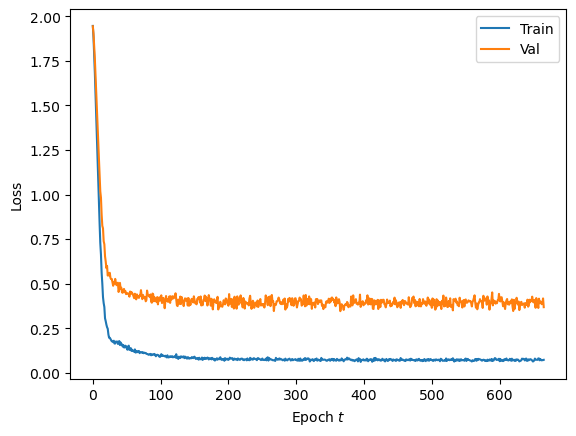

Accuracy of the model: 83.52%


GCN(
  (activation): ReLU()
  (layers): ModuleList(
    (0): Sequential(
      (gcn_0): ChainableGCNConv(2879, 64)
      (activation_0): ReLU()
      (dropout_0): Dropout(p=0.5, inplace=False)
    )
    (1): Sequential(
      (gcn_1): ChainableGCNConv(64, 7)
    )
  )
)

In [3]:
import torch

train_statistics = experiment_train.run(
    data_dir='./data',
    dataset=DATASET,
    model_params=dict(
        label=MODEL_LABEL,
        model=MODEL_NAME,
        do_cache_adj_prep=True,
        n_filters=64,
        dropout=DROPOUT_VICTIM,
        svd_params=None,
        jaccard_params=None,
        gdc_params={"alpha": 0.15, "k": 64},
    ),
    train_params=dict(
        lr=LR_VICTIM,
        weight_decay=WEIGHT_DECAY_VICTIM,
        patience=PATIENCE_VICTIM,
        max_epochs=MAX_EPOCHS_VICTIM,
    ),
    binary_attr=False,
    make_undirected=True,
    seed=SEED,
    artifact_dir='cache',
    model_storage_type='demo_custom_split',
    ppr_cache_params=dict(),
    device="cpu",
    data_device="cpu",
    display_steps=100,
    debug_level="info",
    custom_split_ratios=None #(TRAIN_RATIO, VAL_RATIO, TEST_RATIO),
)

# plot train and val loss curves
fig, ax = plt.subplots()

color = plt.rcParams['axes.prop_cycle'].by_key()['color'][0]
ax.set_xlabel('Epoch $t$')
ax.set_ylabel("Loss")
ax.plot(train_statistics['trace_train'], color=color, label='Train')

color = plt.rcParams['axes.prop_cycle'].by_key()['color'][1]
ax.plot(train_statistics['trace_val'], color=color, label='Val')
ax.legend()
plt.show()

clean_acc = train_statistics["accuracy"]
print(f'Accuracy of the model: {100*clean_acc:.2f}%')

model = train_statistics["model"]
graph = train_statistics["graph"]
idx_train = train_statistics["idx_train"]
idx_val = train_statistics["idx_val"]
idx_test = train_statistics["idx_test"]
model.eval()

In [4]:
import torch

attr_matrix, adj_matrix, labels_raw = graph[:3]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Display ────────────────────────────────────────────────────────────────
n_nodes = adj_matrix.sizes()[0]
n_edges_directed = adj_matrix.nnz()
n_undirected = n_edges_directed // 2

print(f"nodes={n_nodes}")
print(f"Directed edges: {n_edges_directed}")
print(f"Undirected edges: {n_undirected}")
print(f"features={attr_matrix.shape}")
print(f"classes={len(torch.unique(labels_raw))}")

# ── Convert adjacency SparseTensor -> edge_index / edge_weight ─────────────
row, col, value = adj_matrix.coo()

edge_index = torch.stack([row, col], dim=0).long().to(device)

if value is None:
    edge_weight = torch.ones(edge_index.size(1), dtype=torch.float32, device=device)
else:
    edge_weight = value.float().to(device)

# ── Convert features / labels ──────────────────────────────────────────────
attr = attr_matrix.float().to(device)
labels = labels_raw.long().to(device)

# ── Safety checks ──────────────────────────────────────────────────────────
print("edge_index shape:", edge_index.shape)
print("edge_weight shape:", edge_weight.shape)
print("max node id in edge_index:", int(edge_index.max()))
print("n_nodes:", n_nodes)

assert int(edge_index.max()) < n_nodes
assert attr.shape[0] == n_nodes
assert labels.shape[0] == n_nodes
'''
train_idx_np, val_idx_np, test_idx_np = train_val_test_split(
    graph.labels,
    train_size=0.05,
    val_size=0.05,
    test_size=0.9,
    mode="stratified",
    seed=SEED,
)

train_idx = torch.as_tensor(train_idx_np, dtype=torch.long, device=device)
val_idx = torch.as_tensor(val_idx_np, dtype=torch.long, device=device)
test_idx = torch.as_tensor(test_idx_np, dtype=torch.long, device=device)'''

nodes=2810
Directed edges: 15962
Undirected edges: 7981
features=torch.Size([2810, 2879])
classes=7
edge_index shape: torch.Size([2, 15962])
edge_weight shape: torch.Size([15962])
max node id in edge_index: 2809
n_nodes: 2810


'\ntrain_idx_np, val_idx_np, test_idx_np = train_val_test_split(\n    graph.labels,\n    train_size=0.05,\n    val_size=0.05,\n    test_size=0.9,\n    mode="stratified",\n    seed=SEED,\n)\n\ntrain_idx = torch.as_tensor(train_idx_np, dtype=torch.long, device=device)\nval_idx = torch.as_tensor(val_idx_np, dtype=torch.long, device=device)\ntest_idx = torch.as_tensor(test_idx_np, dtype=torch.long, device=device)'

In [5]:
from helpers.selector_pipeline_helpers import EndpointPRBCDV4Scorer, _edge_set
from IPython.display import display
import math
import random
import pandas as pd


def _safe_config_value(value):
    text = f"{value:.12g}" if isinstance(value, float) else str(value)
    return (
        text.strip()
        .replace(" ", "")
        .replace("/", "-")
        .replace("\\", "-")
        .replace(".", "p")
        .replace("+", "")
        .replace("-", "m")
    )


def _resolve_candidate_set_sizes():
    """
    Resolve fixed candidate-set sizes.

    If CANDIDATE_SET_SIZES is None, the old size formula is used as a
    backward-compatible fallback. Otherwise every value in CANDIDATE_SET_SIZES
    is treated as a fixed final pool size N.
    """
    configured = globals().get("CANDIDATE_SET_SIZES", None)

    if configured is None:
        fallback_size = max(
            1,
            round(n_undirected * PRBCD_BUDGET_FRACTION * N_PRBCD_RUNS),
        )
        return [fallback_size]

    if isinstance(configured, int):
        configured = [configured]

    sizes = [int(value) for value in configured]

    if not sizes:
        raise ValueError("CANDIDATE_SET_SIZES must contain at least one size.")

    if any(size <= 0 for size in sizes):
        raise ValueError("All CANDIDATE_SET_SIZES values must be positive.")

    return sizes


def _resolve_prbcd_candidate_fractions():
    configured = globals().get(
        "PRBCD_CANDIDATE_FRACTIONS",
        [globals().get("PRBCD_CANDIDATE_FRACTION", 0.5)],
    )

    if isinstance(configured, (int, float)):
        configured = [configured]

    fractions = [float(value) for value in configured]

    if not fractions:
        raise ValueError("PRBCD_CANDIDATE_FRACTIONS must contain at least one value.")

    for fraction in fractions:
        if not 0.0 <= fraction <= 1.0:
            raise ValueError(
                "Every PRBCD_CANDIDATE_FRACTIONS value must be in [0, 1]."
            )

    return fractions


def _candidate_config_id(candidate_set_size: int, prbcd_candidate_fraction: float) -> str:
    return (
        f"candN-{_safe_config_value(candidate_set_size)}"
        f"__prbcdFrac-{_safe_config_value(prbcd_candidate_fraction)}"
    )


def sample_random_candidates(
    count: int,
    *,
    forbidden=None,
    seed: int,
) -> set[tuple[int, int]]:
    """
    Sample unique unordered node pairs, excluding pairs in `forbidden`.
    Existing graph edges are allowed, so the result can contain both additions
    and removals.
    """
    forbidden = set() if forbidden is None else set(forbidden)

    n_possible = n_nodes * (n_nodes - 1) // 2
    n_available = n_possible - len(forbidden)

    if count > n_available:
        raise ValueError(
            f"Cannot sample {count} random candidates: only "
            f"{n_available} unordered pairs are available after exclusions."
        )

    rng = random.Random(int(seed))
    sampled: set[tuple[int, int]] = set()

    while len(sampled) < count:
        u = rng.randrange(n_nodes)
        v = rng.randrange(n_nodes)

        if u == v:
            continue

        edge = (min(u, v), max(u, v))

        if edge in forbidden:
            continue

        sampled.add(edge)

    return sampled


candidate_set_sizes = _resolve_candidate_set_sizes()
prbcd_candidate_fractions = _resolve_prbcd_candidate_fractions()

n_possible_candidates = n_nodes * (n_nodes - 1) // 2

for candidate_set_size in candidate_set_sizes:
    if candidate_set_size > n_possible_candidates:
        raise ValueError(
            f"candidate_set_size={candidate_set_size} exceeds the number of "
            f"possible undirected pairs ({n_possible_candidates})."
        )

orig_edges = _edge_set(edge_index)

candidate_runs = []
_candidate_mining_cache_by_size = {}

for size_index, candidate_set_size in enumerate(candidate_set_sizes):
    # The PRBCD attack budget is now derived from the requested final pool size N.
    # With N_PRBCD_RUNS runs, this mines about N candidates before duplicate removal.
    budget = max(
        1,
        math.ceil(candidate_set_size / max(1, int(N_PRBCD_RUNS))),
    )

    prbcd_budget_fraction = budget / max(1, int(n_undirected))

    for fraction_index, prbcd_candidate_fraction in enumerate(prbcd_candidate_fractions):
        config_id = _candidate_config_id(candidate_set_size, prbcd_candidate_fraction)
        target_prbcd_count = round(candidate_set_size * prbcd_candidate_fraction)

        prbcd_candidates: set[tuple[int, int]] = set()

        if USE_PRBCD_CANDIDATES and target_prbcd_count > 0:
            if candidate_set_size not in _candidate_mining_cache_by_size:
                scorer = EndpointPRBCDV4Scorer(
                    n=n_nodes,
                    edge_index=edge_index,
                    edge_weight=edge_weight,
                    attr=attr,
                    labels=labels,
                    attacked_model=model,
                    idx_attack=idx_test,
                    test_idx=idx_val,
                    device=device,
                    block_size=PRBCD_SEARCH_SPACE,
                    n_epochs_resampling=PRBCD_N_EPOCHS_RESAMPLING,
                    n_subsets=N_SUBSETS,
                    subset_fraction=SUBSET_FRACTION,
                    balance_ratio=BALANCE_RATIO,
                    store_candidates=True,
                )

                mined_candidates = scorer.mine_prbcd_endpoint_candidates(
                    n_perturbations=budget,
                    tag=f"endpointPRBCD__{config_id}",
                    rng_seed=SEED,
                    n_candidates=PRBCD_SEARCH_SPACE,
                    prbcd_epochs=PRBCD_EPOCHS,
                    n_prbcd_runs=N_PRBCD_RUNS,
                    n_epochs_resampling=PRBCD_N_EPOCHS_RESAMPLING,
                )

                _candidate_mining_cache_by_size[candidate_set_size] = {
                    (min(int(u), int(v)), max(int(u), int(v)))
                    for u, v in mined_candidates
                    if int(u) != int(v)
                }

            prbcd_candidates = set(_candidate_mining_cache_by_size[candidate_set_size])

        # Select only the requested PRBCD share. If duplicate removal leaves too
        # few PRBCD candidates, we keep all unique PRBCD candidates and fill the
        # remaining pool with random candidates below.
        selection_rng = random.Random(SEED + 10_000 * size_index + 101 * fraction_index)

        if len(prbcd_candidates) > target_prbcd_count:
            selected_prbcd = set(
                selection_rng.sample(
                    sorted(prbcd_candidates),
                    target_prbcd_count,
                )
            )
        else:
            selected_prbcd = set(prbcd_candidates)

        n_random_needed = candidate_set_size - len(selected_prbcd)

        random_candidates = sample_random_candidates(
            n_random_needed,
            forbidden=selected_prbcd,
            seed=SEED + 20_000 * size_index + 211 * fraction_index + 17,
        )

        candidate_set = selected_prbcd | random_candidates
        candidates_for_config = list(candidate_set)

        # Deterministic shuffle so PRBCD and random candidates are mixed.
        selection_rng.shuffle(candidates_for_config)

        if len(candidates_for_config) != candidate_set_size:
            raise RuntimeError(
                f"Expected {candidate_set_size} candidates for {config_id}, "
                f"got {len(candidates_for_config)}."
            )

        n_removals = sum(edge in orig_edges for edge in candidates_for_config)
        n_adds = len(candidates_for_config) - n_removals
        actual_prbcd_fraction = len(selected_prbcd) / len(candidates_for_config)

        candidate_runs.append({
            "candidate_config_id": config_id,
            "candidate_set_size": int(candidate_set_size),
            "prbcd_candidate_fraction": float(prbcd_candidate_fraction),
            "budget": int(budget),
            "prbcd_budget_fraction": float(prbcd_budget_fraction),
            "n_prbcd_requested": int(target_prbcd_count),
            "n_prbcd_mined_unique": int(len(prbcd_candidates)),
            "n_prbcd_selected": int(len(selected_prbcd)),
            "n_random_candidates": int(len(random_candidates)),
            "actual_prbcd_fraction": float(actual_prbcd_fraction),
            "n_add_candidates": int(n_adds),
            "n_delete_candidates": int(n_removals),
            "candidates": candidates_for_config,
            "selected_prbcd": selected_prbcd,
            "random_candidates": random_candidates,
        })


if not candidate_runs:
    raise RuntimeError("No candidate configurations were created.")

candidate_config_df = pd.DataFrame([
    {
        key: value
        for key, value in run.items()
        if key not in {"candidates", "selected_prbcd", "random_candidates"}
    }
    for run in candidate_runs
])

display(candidate_config_df)

# Backward-compatible active configuration for older one-off cells.
active_candidate_run = candidate_runs[0]
candidates = active_candidate_run["candidates"]
PRBCD_CANDIDATE_FRACTION = active_candidate_run["prbcd_candidate_fraction"]
PRBCD_BUDGET_FRACTION = active_candidate_run["prbcd_budget_fraction"]
budget = active_candidate_run["budget"]
n_total_candidates = active_candidate_run["candidate_set_size"]

print(
    "Active candidate configuration:",
    active_candidate_run["candidate_config_id"],
)
print(
    f"Candidates: {len(candidates)} | "
    f"{active_candidate_run['n_prbcd_selected']} PRBCD, "
    f"{active_candidate_run['n_random_candidates']} random "
    f"(actual PRBCD fraction={active_candidate_run['actual_prbcd_fraction']:.3f})"
)


[endpointPRBCD] Mining actual endpointPRBCD flips: budget=3990, block=200000, epochs=5, runs=6
[endpointPRBCD] PRBCD run 1/6 (seed=0)
[endpointPRBCD] epochs=5, epochs_resampling=2, fine_tuning_epochs=3
run sampling with no certificate
GCN(
  (activation): ReLU()
  (layers): ModuleList(
    (0): Sequential(
      (gcn_0): ChainableGCNConv(2879, 64)
      (activation_0): ReLU()
      (dropout_0): Dropout(p=0.5, inplace=False)
    )
    (1): Sequential(
      (gcn_1): ChainableGCNConv(64, 7)
    )
  )
)


[07/05/26 10:03:47] INFO                                                           ]8;id=380158;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py\selector_pipeline_helpers.py]8;;\:]8;id=234133;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py#618\618]8;;\
                             Before mining - Loss: -0.652926504611969 Accuracy:                                    
                             83.518 %                                                                              
                                                                                                                   

[07/05/26 10:03:48] INFO                                                           ]8;id=570644;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py\selector_pipeline_helpers.py]8;;\:]8;id=307732;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py#693\693]8;;\
                             Epoch: 0 Loss: -0.6529 Accuracy: 79.328 %                                             
                                                                                                                   


[endpointPRBCD] Final discrete attack selected 3990 actual flips.
[endpointPRBCD] Run 1: 3990 flips, 3990 new, 3990 total unique
[endpointPRBCD] PRBCD run 2/6 (seed=1)
[endpointPRBCD] epochs=5, epochs_resampling=2, fine_tuning_epochs=3
run sampling with no certificate
GCN(
  (activation): ReLU()
  (layers): ModuleList(
    (0): Sequential(
      (gcn_0): ChainableGCNConv(2879, 64)
      (activation_0): ReLU()
      (dropout_0): Dropout(p=0.5, inplace=False)
    )
    (1): Sequential(
      (gcn_1): ChainableGCNConv(64, 7)
    )
  )
)


[07/05/26 10:03:57] INFO                                                           ]8;id=119920;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py\selector_pipeline_helpers.py]8;;\:]8;id=252260;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py#618\618]8;;\
                             Before mining - Loss: -0.652926504611969 Accuracy:                                    
                             83.518 %                                                                              
                                                                                                                   

...

[07/05/26 10:04:31] INFO                                                           ]8;id=604998;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py\selector_pipeline_helpers.py]8;;\:]8;id=353534;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py#693\693]8;;\
                             Epoch: 0 Loss: -0.6529 Accuracy: 79.447 %                                             
                                                                                                                   


[endpointPRBCD] Final discrete attack selected 3990 actual flips.
[endpointPRBCD] Run 5: 3990 flips, 3378 new, 18347 total unique
[endpointPRBCD] PRBCD run 6/6 (seed=5)
[endpointPRBCD] epochs=5, epochs_resampling=2, fine_tuning_epochs=3
run sampling with no certificate
GCN(
  (activation): ReLU()
  (layers): ModuleList(
    (0): Sequential(
      (gcn_0): ChainableGCNConv(2879, 64)
      (activation_0): ReLU()
      (dropout_0): Dropout(p=0.5, inplace=False)
    )
    (1): Sequential(
      (gcn_1): ChainableGCNConv(64, 7)
    )
  )
)


[07/05/26 10:04:41] INFO                                                           ]8;id=956669;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py\selector_pipeline_helpers.py]8;;\:]8;id=792391;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py#618\618]8;;\
                             Before mining - Loss: -0.652926504611969 Accuracy:                                    
                             83.518 %                                                                              
                                                                                                                   

[07/05/26 10:04:42] INFO                                                           ]8;id=902422;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py\selector_pipeline_helpers.py]8;;\:]8;id=670830;file://E:\Masterarbeit\AttackerGNN\helpers\selector_pipeline_helpers.py#693\693]8;;\
                             Epoch: 0 Loss: -0.6529 Accuracy: 79.605 %                                             
                                                                                                                   


[endpointPRBCD] Final discrete attack selected 3990 actual flips.
[endpointPRBCD] Run 6: 3990 flips, 3222 new, 21569 total unique
[endpointPRBCD] Mined 21569 unique actual PRBCD flips.
Candidates: 23943
Sources: 11972 PRBCD, 11971 random (actual PRBCD fraction=0.500)
Actions: 23868 additions, 75 removals


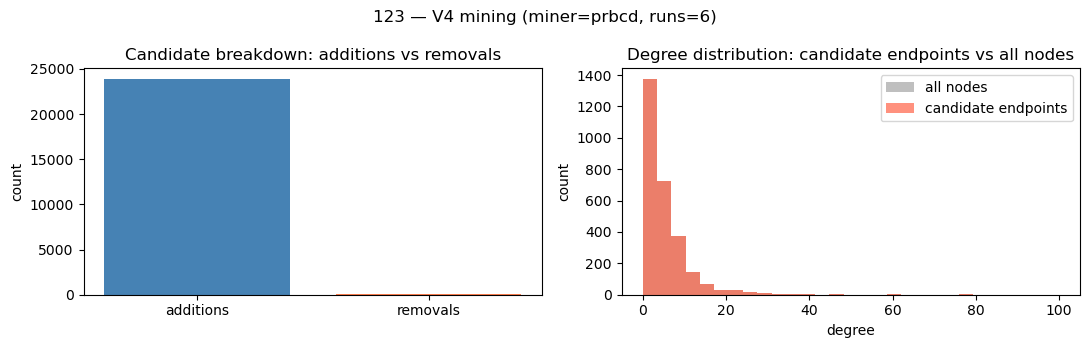

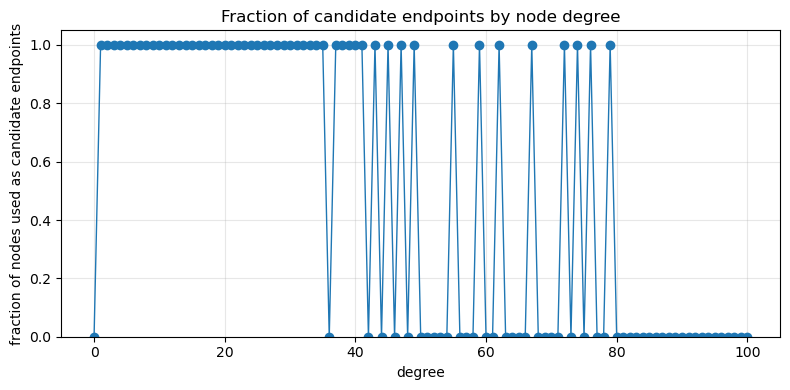

In [6]:
degrees    = np.bincount(edge_index[0].cpu().numpy(), minlength=n_nodes)
cand_nodes = set(u for u, v in candidates) | set(v for u, v in candidates)
cand_degs  = degrees[list(cand_nodes)]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].bar(['additions', 'removals'], [n_adds, n_removals], color=['steelblue', 'coral'])
axes[0].set_title('Candidate breakdown: additions vs removals')
axes[0].set_ylabel('count')

bins = np.linspace(0, min(degrees.max(), 100), 30)
axes[1].hist(degrees,     bins=bins, alpha=0.5, label='all nodes',          color='grey')
axes[1].hist(cand_degs,   bins=bins, alpha=0.7, label='candidate endpoints', color='tomato')
axes[1].set_title('Degree distribution: candidate endpoints vs all nodes')
axes[1].set_xlabel('degree'); axes[1].set_ylabel('count'); axes[1].legend()

plt.suptitle(f'{123} — V4 mining (miner={MINER}, runs={N_PRBCD_RUNS})', fontsize=12)
plt.tight_layout()
plt.show()

# Fraction of nodes per degree that appear as candidate endpoints
all_degree_counts = np.bincount(degrees)

candidate_endpoint_mask = np.zeros(n_nodes, dtype=bool)
candidate_endpoint_mask[list(cand_nodes)] = True

candidate_degree_counts = np.bincount(
    degrees[candidate_endpoint_mask],
    minlength=len(all_degree_counts)
)

candidate_fraction_by_degree = np.divide(
    candidate_degree_counts,
    all_degree_counts,
    out=np.zeros_like(candidate_degree_counts, dtype=float),
    where=all_degree_counts > 0
)

# Optional: restrict to visible degree range
max_degree_plot = min(degrees.max(), 100)
degree_values = np.arange(max_degree_plot + 1)

plt.figure(figsize=(8, 4))
plt.plot(
    degree_values,
    candidate_fraction_by_degree[:max_degree_plot + 1],
    marker="o",
    linewidth=1,
)

plt.title("Fraction of candidate endpoints by node degree")
plt.xlabel("degree")
plt.ylabel("fraction of nodes used as candidate endpoints")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
print("vor breakpoint")
print("nach breakpoint")

import sys
print(sys.executable)
print(sys.version)

vor breakpoint
nach breakpoint
E:\Anaconda\envs\Masterarbeit\python.exe
3.11.11 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:34:19) [MSC v.1929 64 bit (AMD64)]


---
## §2  Subset Scoring

We run `N_SUBSETS` random subsets of the candidate pool, apply each subset jointly, and measure test-accuracy drop.  Each edge accumulates the drops of every subset it was in; the raw scores are normalised globally to [0, 1].

**Key diagnostics:**
- Accuracy drop per subset — are subsets actually harming the model?
- Distribution of raw accumulated scores — how skewed is it?
- Fraction of candidates with score > 0 — coverage.

In [8]:
from pathlib import Path
from IPython.display import display
import hashlib
import numpy as np
import pandas as pd
import torch

from helpers.selector_pipeline_helpers import (
    mine_candidate_edge_scores,
    save_mining_output,
    load_mining_output,
    _dense_adj,
)


def _resolve_mining_modes():
    configured = globals().get("MINING_MODES", [globals().get("MINING_MODE", "endpoint")])

    if isinstance(configured, str):
        configured = [configured]

    modes = [str(mode) for mode in configured]

    if not modes:
        raise ValueError("MINING_MODES must contain at least one mining mode.")

    return modes


def _activate_mining_run(run):
    """Expose one mining run under the old variable names for compatibility."""
    globals().update({
        "active_mining_run": run,
        "active_candidate_run": run["candidate_run"],
        "candidates": run["candidates"],
        "cand_src": run["cand_src"],
        "cand_dst": run["cand_dst"],
        "exists_list": run["exists_list"],
        "n_cands": run["n_cands"],
        "MINING_MODE": run["mining_mode"],
        "labels_raw": run["labels_raw"],
        "labels_norm": run["labels_norm"],
        "clean_acc_v": run["clean_accuracy"],
        "src": run["src"],
        "dst": run["dst"],
        "labels_changed": run["labels_changed"],
        "exists": run["exists"],
    })

    mining_result = run["mining_result"]

    if run["mining_mode"] == "subset_accuracy_drop":
        globals().update({
            "drop_per_subset": mining_result["drop_per_subset"],
            "subset_size": mining_result["subset_size"],
            "n_pos": int((run["labels_norm"] > 0).sum()),
        })

    elif run["mining_mode"] == "endpoint":
        globals().update({
            "endpoint_labels": np.asarray(mining_result["endpoint_labels"]),
            "u_hit_labels": np.asarray(mining_result["u_hit_labels"]),
            "v_hit_labels": np.asarray(mining_result["v_hit_labels"]),
            "both_hit_labels": np.asarray(mining_result["both_hit_labels"]),
            "sampled_edge_index": mining_result["sampled_edge_index"],
            "n_pos": int(np.asarray(mining_result["endpoint_labels"]).sum()),
        })


adj_orig = _dense_adj(edge_index, n_nodes, device=device)
mining_modes = _resolve_mining_modes()
mining_runs = []
mining_summary_rows = []

for candidate_run in candidate_runs:
    candidates_for_config = candidate_run["candidates"]
    cand_src_for_config = [u for u, v in candidates_for_config]
    cand_dst_for_config = [v for u, v in candidates_for_config]
    exists_for_config = [
        float(adj_orig[u, v].item())
        for u, v in candidates_for_config
    ]

    for mining_mode in mining_modes:
        candidate_hash = hashlib.sha1(
            repr(candidates_for_config).encode("utf-8")
        ).hexdigest()[:10]

        cache_path = Path("cache") / (
            f"candidate_mining_"
            f"dataset-{DATASET}_"
            f"model-{MODEL_LABEL}_"
            f"cfg-{candidate_run['candidate_config_id']}_"
            f"mode-{mining_mode}_"
            f"seed-{SEED}_"
            f"candidates-{len(candidates_for_config)}_"
            f"hash-{candidate_hash}.pt"
        )

        cache_metadata = {
            "mode": mining_mode,
            "seed": int(SEED),
            "n_nodes": int(n_nodes),
            "n_candidates": int(len(candidates_for_config)),
            "candidate_config_id": candidate_run["candidate_config_id"],
            "candidate_set_size": int(candidate_run["candidate_set_size"]),
            "prbcd_candidate_fraction": float(candidate_run["prbcd_candidate_fraction"]),
            "actual_prbcd_fraction": float(candidate_run["actual_prbcd_fraction"]),
            "subset_fraction": float(SUBSET_FRACTION),
            "n_subsets": int(N_SUBSETS),
            "endpoint_require_correct_to_incorrect": True,
        }

        print("=" * 80)
        print(
            "Mining:",
            candidate_run["candidate_config_id"],
            "mode=", mining_mode,
            "candidates=", len(candidates_for_config),
        )

        if cache_path.exists():
            mining_result, cached_candidates, stored_metadata = load_mining_output(
                cache_path,
                device=device,
                expected_metadata=cache_metadata,
            )

            if cached_candidates != candidates_for_config:
                raise ValueError(
                    "The candidates in the cache differ from the current candidates."
                )

            cache_status = "loaded"

        else:
            mining_result = mine_candidate_edge_scores(
                model=model,
                attr=attr,
                edge_index=edge_index,
                labels=labels,
                eval_idx=idx_test,
                candidates=candidates_for_config,
                n_nodes=n_nodes,
                mode=mining_mode,

                subset_fraction=SUBSET_FRACTION,
                n_subsets=N_SUBSETS,

                endpoint_k_samples=None,
                endpoint_require_correct_to_incorrect=True,

                two_hop_k_samples=None,

                seed=SEED,
                device=device,
                verbose=True,
            )

            save_mining_output(
                cache_path,
                mining_result,
                candidates=candidates_for_config,
                metadata=cache_metadata,
            )

            cache_status = "computed"

        labels_raw_for_run = mining_result["labels_raw"]
        labels_norm_for_run = mining_result["labels_norm"]
        clean_acc_for_run = float(mining_result["clean_accuracy"])

        src_tensor = torch.tensor(cand_src_for_config, dtype=torch.long, device=device)
        dst_tensor = torch.tensor(cand_dst_for_config, dtype=torch.long, device=device)
        labels_tensor = torch.tensor(labels_norm_for_run, dtype=torch.float32, device=device)
        exists_tensor = torch.tensor(exists_for_config, dtype=torch.float32, device=device)

        n_positive = int((labels_tensor > 0).sum().item())

        if mining_mode == "endpoint":
            endpoint_labels_for_run = np.asarray(mining_result["endpoint_labels"])
            n_positive = int(endpoint_labels_for_run.sum())
            diagnostic = (
                f"endpoint_hits={n_positive}/"
                f"{int(mining_result['n_samples'])}"
            )
        elif mining_mode == "subset_accuracy_drop":
            drop_per_subset = mining_result["drop_per_subset"]
            diagnostic = (
                f"subset_size={int(mining_result['subset_size'])}, "
                f"drop_mean={float(drop_per_subset.mean()):.4f}, "
                f"drop_max={float(drop_per_subset.max()):.4f}"
            )
        else:
            diagnostic = ""

        run = {
            **{
                key: value
                for key, value in candidate_run.items()
                if key not in {"selected_prbcd", "random_candidates"}
            },
            "candidate_run": candidate_run,
            "mining_mode": mining_mode,
            "candidate_hash": candidate_hash,
            "cache_path": str(cache_path),
            "cache_status": cache_status,
            "candidates": candidates_for_config,
            "cand_src": cand_src_for_config,
            "cand_dst": cand_dst_for_config,
            "exists_list": exists_for_config,
            "n_cands": len(candidates_for_config),
            "mining_result": mining_result,
            "labels_raw": labels_raw_for_run,
            "labels_norm": labels_norm_for_run,
            "clean_accuracy": clean_acc_for_run,
            "src": src_tensor,
            "dst": dst_tensor,
            "labels_changed": labels_tensor,
            "exists": exists_tensor,
            "n_positive_labels": n_positive,
        }

        mining_runs.append(run)

        mining_summary_rows.append({
            "candidate_config_id": candidate_run["candidate_config_id"],
            "candidate_set_size": candidate_run["candidate_set_size"],
            "prbcd_candidate_fraction": candidate_run["prbcd_candidate_fraction"],
            "actual_prbcd_fraction": candidate_run["actual_prbcd_fraction"],
            "mining_mode": mining_mode,
            "cache_status": cache_status,
            "n_candidates": len(candidates_for_config),
            "n_positive_labels": n_positive,
            "clean_accuracy": clean_acc_for_run,
            "diagnostic": diagnostic,
            "cache_path": str(cache_path),
        })

        print(f"Clean test accuracy: {clean_acc_for_run:.4f}")
        print(diagnostic)


if not mining_runs:
    raise RuntimeError("No mining runs were created.")

mining_summary_df = pd.DataFrame(mining_summary_rows)
display(mining_summary_df)

_activate_mining_run(mining_runs[0])

print("Active mining configuration:")
print(active_mining_run["candidate_config_id"], "|", active_mining_run["mining_mode"])


Clean evaluation accuracy: 0.8352
Original candidate edges evaluated: 23943
Endpoint hits: 6642/23943 (27.74%)
[MINING CACHE] Saved mining output to: cache\candidate_mining_mode-endpoint_seed-0_candidates-23943.pt
Clean test accuracy: 0.8352
Original candidate pairs evaluated: 23943
Endpoint hits: 6642/23943 (27.74%)
u hits=3499  v hits=3215  both hits=72
Positive endpoint labels: 6642/23943
Candidate edge tensor shape: (2, 23943)


In [11]:
subset_runs = [
    run for run in globals().get("mining_runs", [])
    if run["mining_mode"] == "subset_accuracy_drop"
]

if subset_runs:
    for run in subset_runs:
        mining_result = run["mining_result"]
        drop_per_subset = mining_result["drop_per_subset"]
        subset_size = mining_result["subset_size"]
        labels_raw_run = run["labels_raw"]
        n_pos_run = int((run["labels_changed"] > 0).sum().item())
        n_cands_run = int(run["n_cands"])

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].plot(
            np.arange(1, len(drop_per_subset) + 1),
            drop_per_subset,
            marker="o",
            markersize=3,
            linewidth=1,
        )
        axes[0].axhline(
            drop_per_subset.mean(),
            linestyle="--",
            linewidth=1.2,
            label=f"mean = {drop_per_subset.mean():.4f}",
        )
        axes[0].set_xlabel("subset index")
        axes[0].set_ylabel("accuracy drop")
        axes[0].set_title("Accuracy drop per sampled subset")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].hist(drop_per_subset, bins=20, edgecolor="white")
        axes[1].set_xlabel("accuracy drop")
        axes[1].set_ylabel("count")
        axes[1].set_title("Distribution of per-subset accuracy drops")
        axes[1].grid(True, alpha=0.3)

        axes[2].hist(labels_raw_run[labels_raw_run > 0], bins=30, edgecolor="white", label=f"scored ({n_pos_run})")
        axes[2].set_xlabel("raw accumulated drop sum")
        axes[2].set_ylabel("count")
        axes[2].set_title(f"Per-edge raw score distribution ({n_cands_run - n_pos_run} edges at 0 not shown)")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

        plt.suptitle(
            f"{run['candidate_config_id']} | subset scoring "
            f"(n_subsets={N_SUBSETS}, subset_size={subset_size})",
            fontsize=12,
        )
        plt.tight_layout()
        plt.show()
else:
    print("Skipping subset-drop plots because no subset_accuracy_drop mining run exists.")


NameError: name 'drop_per_subset' is not defined

---
## §3  Label Distribution

After global normalisation the labels are continuous in [0, 1].  Unlike V1–V3 (binary 0/1), V4 labels represent a **relative harmfulness score** — the edge with the highest total accumulated accuracy drop receives 1.0.

In [24]:
n_pos = int((labels_norm > 0).sum())

Label stats:
  min=0.0000  mean=0.2774  max=1.0000  std=0.4477
  Fraction with label > 0: 0.277
  Fraction with label > 0.5: 0.277


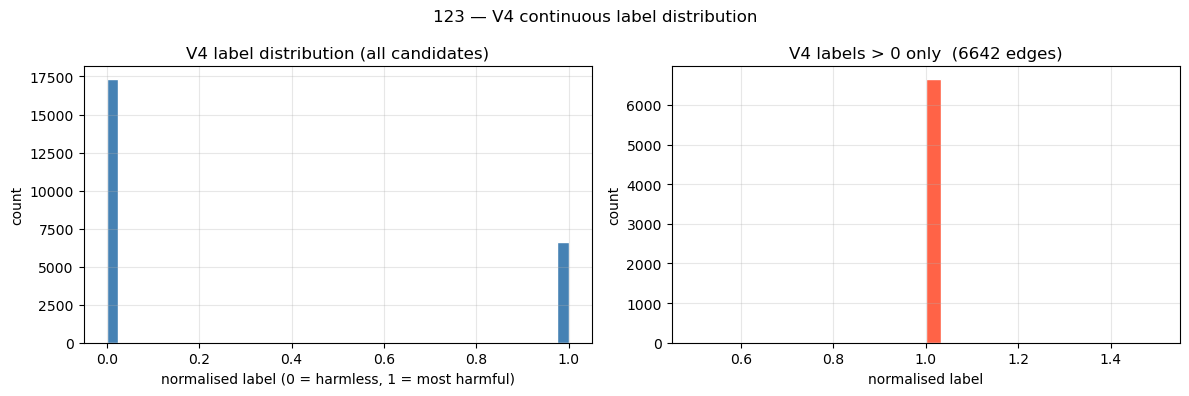

In [25]:
# Converted tensors are now stored on every entry in `mining_runs`.
# This cell displays label diagnostics for all candidate-size × PRBCD-fraction × mining-mode configurations.

label_summary_rows = []

for run in mining_runs:
    labels_changed_run = run["labels_changed"]

    label_summary_rows.append({
        "candidate_config_id": run["candidate_config_id"],
        "candidate_set_size": run["candidate_set_size"],
        "prbcd_candidate_fraction": run["prbcd_candidate_fraction"],
        "actual_prbcd_fraction": run["actual_prbcd_fraction"],
        "mining_mode": run["mining_mode"],
        "n_candidates": run["n_cands"],
        "label_min": float(labels_changed_run.min().item()),
        "label_mean": float(labels_changed_run.mean().item()),
        "label_max": float(labels_changed_run.max().item()),
        "label_std": float(labels_changed_run.std().item()),
        "fraction_label_gt_0": float((labels_changed_run > 0).float().mean().item()),
        "fraction_label_gt_0_5": float((labels_changed_run > 0.5).float().mean().item()),
    })

label_summary_df = pd.DataFrame(label_summary_rows)
display(label_summary_df)

# Keep the old single-run variables bound to the active run for optional manual inspection.
_activate_mining_run(mining_runs[0])

lbl_np = labels_changed.cpu().numpy()
n_pos = int((labels_changed > 0).sum().item())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(lbl_np, bins=40, edgecolor="white")
axes[0].set_xlabel("normalised label (0 = harmless, 1 = most harmful)")
axes[0].set_ylabel("count")
axes[0].set_title("Active run: label distribution")
axes[0].grid(True, alpha=0.3)

axes[1].hist(lbl_np[lbl_np > 0], bins=30, edgecolor="white")
axes[1].set_xlabel("normalised label")
axes[1].set_ylabel("count")
axes[1].set_title(f"Active run: labels > 0 only ({n_pos} edges)")
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f"{active_mining_run['candidate_config_id']} | {active_mining_run['mining_mode']} label distribution",
    fontsize=12,
)
plt.tight_layout()
plt.show()


---
## §4  Oracle Check — Top-Scored vs Random Subsets

Apply the top-k edges by V4 label jointly and compare accuracy with applying k random candidate edges.  If the labels are informative, the top-scored selection should consistently produce larger accuracy drops.

In [26]:
from helpers.selector_pipeline_helpers import accuracy
import pandas as pd
import numpy as np

BLOCK_STEP_ORACLE = 10
oracle_rows = []

for run in mining_runs:
    cand_src_run = run["cand_src"]
    cand_dst_run = run["cand_dst"]
    exists_run = run["exists_list"]
    labels_changed_run = run["labels_changed"]
    n_cands_run = int(run["n_cands"])

    sort_order = labels_changed_run.cpu().argsort(descending=True)
    all_idx = np.arange(n_cands_run)

    block_sizes = list(range(0, n_cands_run, BLOCK_STEP_ORACLE))
    if not block_sizes or block_sizes[-1] != n_cands_run:
        block_sizes.append(n_cands_run)

    rng_o = np.random.default_rng(SEED + n_cands_run)

    for k in block_sizes:
        # Top-k by mined label
        adj_top = adj_orig.clone()
        if k > 0:
            for i in sort_order[:k].tolist():
                u, v = cand_src_run[i], cand_dst_run[i]
                adj_top[u, v] = 1.0 - exists_run[i]
                adj_top[v, u] = 1.0 - exists_run[i]

        oracle_rows.append({
            "candidate_config_id": run["candidate_config_id"],
            "candidate_set_size": run["candidate_set_size"],
            "prbcd_candidate_fraction": run["prbcd_candidate_fraction"],
            "actual_prbcd_fraction": run["actual_prbcd_fraction"],
            "mining_mode": run["mining_mode"],
            "k": k,
            "attack": "top-k by mined label",
            "test_accuracy": float(accuracy(model, attr, labels, idx_test, edge_index=adj_top)),
        })

        # One random baseline per k.
        adj_rnd = adj_orig.clone()
        if k > 0:
            for i in rng_o.choice(all_idx, size=min(k, n_cands_run), replace=False).tolist():
                u, v = cand_src_run[i], cand_dst_run[i]
                adj_rnd[u, v] = 1.0 - exists_run[i]
                adj_rnd[v, u] = 1.0 - exists_run[i]

        oracle_rows.append({
            "candidate_config_id": run["candidate_config_id"],
            "candidate_set_size": run["candidate_set_size"],
            "prbcd_candidate_fraction": run["prbcd_candidate_fraction"],
            "actual_prbcd_fraction": run["actual_prbcd_fraction"],
            "mining_mode": run["mining_mode"],
            "k": k,
            "attack": "random candidates",
            "test_accuracy": float(accuracy(model, attr, labels, idx_test, edge_index=adj_rnd)),
        })

oracle_df = pd.DataFrame(oracle_rows)
display(oracle_df.tail(20))


tensor(1.)
tensor(0.)
tensor(0.)


attack,random candidates,top-k by V4 label
k,,
23760,0.652174,0.652569
23770,0.652569,0.652964
23780,0.653360,0.653360
23790,0.652174,0.653360
23800,0.652174,0.653360
23810,0.652964,0.653360
23820,0.652569,0.653360
23830,0.652174,0.653360
23840,0.652569,0.653360


In [27]:
display(oracle_df.pivot_table(index='k', columns='attack', values='test_accuracy').head(20))

attack,random candidates,top-k by V4 label
k,,
0,0.835178,0.835178
10,0.832806,0.829249
20,0.830435,0.824506
30,0.827668,0.823320
40,0.824111,0.817391
50,0.827668,0.815020
60,0.830040,0.811858
70,0.821344,0.809091
80,0.816996,0.805138


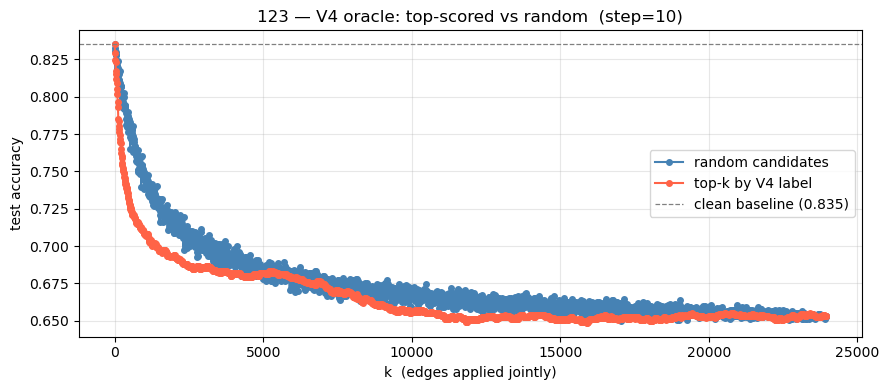

In [28]:
fig, ax = plt.subplots(figsize=(9, 4))
for attack, grp in oracle_df.groupby('attack'):
    color = 'tomato' if 'V4' in attack else 'steelblue'
    ax.plot(grp['k'], grp['test_accuracy'], marker='o', markersize=4,
            label=attack, color=color)
ax.axhline(clean_acc, color='grey', linestyle='--', linewidth=0.9,
           label=f'clean baseline ({clean_acc:.3f})')
ax.set_xlabel('k  (edges applied jointly)'); ax.set_ylabel('test accuracy')
ax.set_title(f'{123} — V4 oracle: top-scored vs random  (step={BLOCK_STEP_ORACLE})')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
from helpers.selector_pipeline_helpers import train_link_prediction_gnn
from IPython.display import display

LABEL_MODE = "continuous"  # "projected" or "continuous"
EXTREME_FRACTION = 0.2

attacker_x = attr
edge_index_struct = edge_index

lp_training_runs = []
lp_model_variants = {}

for run_index, run in enumerate(mining_runs, start=1):
    print("=" * 80)
    print(
        f"Training LP-GNN {run_index}/{len(mining_runs)} | "
        f"{run['candidate_config_id']} | mining_mode={run['mining_mode']}"
    )

    src_run = run["src"]
    dst_run = run["dst"]
    scores = run["labels_changed"].float().flatten()
    exists_run = run["exists"]

    valid_mask = torch.isfinite(scores)

    src_valid = src_run[valid_mask]
    dst_valid = dst_run[valid_mask]
    scores_valid = scores[valid_mask]
    exists_valid = exists_run[valid_mask]

    if LABEL_MODE == "continuous":
        src_bal = src_valid
        dst_bal = dst_valid
        lbl_bal = scores_valid
        ex_bal = exists_valid

    elif LABEL_MODE == "projected":
        if not 0.0 < EXTREME_FRACTION <= 0.5:
            raise ValueError("EXTREME_FRACTION must be between 0 and 0.5.")

        n_valid = scores_valid.numel()
        n_per_class = max(
            1,
            min(
                int(n_valid * EXTREME_FRACTION),
                n_valid // 2,
            ),
        )

        order = torch.argsort(scores_valid)
        low_idx = order[:n_per_class]
        high_idx = order[-n_per_class:]
        selected_idx = torch.cat([low_idx, high_idx])

        src_bal = src_valid[selected_idx]
        dst_bal = dst_valid[selected_idx]
        ex_bal = exists_valid[selected_idx]

        lbl_bal = torch.cat([
            torch.zeros(n_per_class, device=scores_valid.device, dtype=torch.float32),
            torch.ones(n_per_class, device=scores_valid.device, dtype=torch.float32),
        ])

    else:
        raise ValueError("LABEL_MODE must be 'continuous' or 'projected'.")

    edge_index_bal = torch.stack(
        [src_bal.long(), dst_bal.long()],
        dim=0,
    )

    lbl_bal = lbl_bal.float()

    trained_lp_model = train_link_prediction_gnn(
        x=attacker_x,
        edge_index_struct=edge_index_struct,
        edge_index_lab=edge_index_bal,
        y_label=lbl_bal,
        device=device,
        num_epochs=1000,
        hidden_dim=64,
        out_dim=64,
        lr=5e-4,
        weight_decay=5e-4,
        use_tqdm=True,
        verbose=True,

        early_stop=True,
        early_stop_metric="val_loss",
        min_epochs_before_early_stop=300,
        early_stop_patience=15,
        early_stop_min_delta=1e-4,
        restore_best=True,

        train_ratio=0.70,
        val_ratio=0.15,
        test_ratio=0.15,
        threshold=0.5,
    )

    variant_label = f"{run['candidate_config_id']}__mode-{_safe_config_value(run['mining_mode'])}"

    trained_run = {
        **run,
        "lp_model": trained_lp_model,
        "lp_model_label": variant_label,
        "label_mode": LABEL_MODE,
        "n_training_edges": int(edge_index_bal.size(1)),
    }

    lp_training_runs.append(trained_run)

    lp_model_variants[variant_label] = {
        "model": trained_lp_model,
        "candidate_config_id": run["candidate_config_id"],
        "candidate_set_size": run["candidate_set_size"],
        "prbcd_candidate_fraction": run["prbcd_candidate_fraction"],
        "actual_prbcd_fraction": run["actual_prbcd_fraction"],
        "mining_mode": run["mining_mode"],
        "n_prbcd_requested": run["n_prbcd_requested"],
        "n_prbcd_mined_unique": run["n_prbcd_mined_unique"],
        "n_prbcd_selected": run["n_prbcd_selected"],
        "n_random_candidates": run["n_random_candidates"],
        "n_positive_labels": run["n_positive_labels"],
        "label_mode": LABEL_MODE,
    }


if not lp_training_runs:
    raise RuntimeError("No LP-GNN models were trained.")

# Backward-compatible active model for older one-off cells.
lp_model = lp_training_runs[0]["lp_model"]
LP_MODEL_VARIANTS = lp_model_variants
_activate_mining_run(lp_training_runs[0])

lp_training_summary_df = pd.DataFrame([
    {
        "lp_model_label": run["lp_model_label"],
        "candidate_config_id": run["candidate_config_id"],
        "candidate_set_size": run["candidate_set_size"],
        "prbcd_candidate_fraction": run["prbcd_candidate_fraction"],
        "actual_prbcd_fraction": run["actual_prbcd_fraction"],
        "mining_mode": run["mining_mode"],
        "n_training_edges": run["n_training_edges"],
        "n_positive_labels": run["n_positive_labels"],
    }
    for run in lp_training_runs
])

display(lp_training_summary_df)


[LP-GNN] Training:   0%|          | 0/1000 [00:00<?, ?it/s]

[LP-GNN] Labeled pairs: M=23943 | mode=hard_binary | pos=6642 | neg=17301
[LP-GNN] Split strategy=threshold_stratified | train=16759 | val=3591 | test=3593


[LP-GNN] Training:   0%|          | 2/1000 [00:00<02:30,  6.62it/s, tr_bce=1.0018, tr_obj=1.0278, va_loss=1.0018, va_mae=0.497, va_rmse=0.497, va_ap=0.296, va_auc=0.532, va_f1=0.000, pat=15]

[LP-GNN] Epoch 001/1000 | train_bce=1.0019 | train_objective=1.0280 | val_loss=1.0018 | test_loss=1.0020 | val_mae=0.4969 | val_rmse=0.4969 | train_acc=0.7226 | val_acc=0.7226 | test_acc=0.7225 | val_precision=0.0000 | val_recall=0.0000 | val_f1=0.0000 | val_TP/FP/TN/FN=0/0/2595/996 | val_R2=-0.2319 | val_Pearson=0.0177 | val_AUC=0.5183 | val_AP=0.2853 | best_val_loss=1.0018 (epoch 1) | patience_left=15 | new_best


[LP-GNN] Training:   2%|▏         | 21/1000 [00:02<01:52,  8.70it/s, tr_bce=1.0009, tr_obj=1.0237, va_loss=1.0009, va_mae=0.506, va_rmse=0.507, va_ap=0.398, va_auc=0.625, va_f1=0.434, pat=15]

...

[LP-GNN] Epoch 340/1000 | train_bce=0.2928 | train_objective=0.4858 | val_loss=0.4843 | test_loss=0.4988 | val_mae=0.2331 | val_rmse=0.3235 | train_acc=0.9435 | val_acc=0.8641 | test_acc=0.8525 | val_precision=0.7035 | val_recall=0.8815 | val_f1=0.7825 | val_TP/FP/TN/FN=878/370/2225/118 | val_R2=0.4779 | val_Pearson=0.7457 | val_AUC=0.9361 | val_AP=0.8458 | best_val_loss=0.4840 (epoch 336) | patience_left=11


[LP-GNN] Training:  36%|███▌      | 361/1000 [00:45<01:18,  8.15it/s, tr_bce=0.2809, tr_obj=0.4767, va_loss=0.4840, va_mae=0.232, va_rmse=0.324, va_ap=0.846, va_auc=0.936, va_f1=0.781, pat=1] 

[LP-GNN] Epoch 360/1000 | train_bce=0.2804 | train_objective=0.4773 | val_loss=0.4835 | test_loss=0.4977 | val_mae=0.2303 | val_rmse=0.3213 | train_acc=0.9500 | val_acc=0.8661 | test_acc=0.8583 | val_precision=0.7095 | val_recall=0.8755 | val_f1=0.7838 | val_TP/FP/TN/FN=872/357/2238/124 | val_R2=0.4850 | val_Pearson=0.7470 | val_AUC=0.9360 | val_AP=0.8457 | best_val_loss=0.4834 (epoch 347) | patience_left=2


[LP-GNN] Training:  36%|███▌      | 361/1000 [00:45<01:18,  8.15it/s, tr_bce=0.2802, tr_obj=0.4762, va_loss=0.4839, va_mae=0.232, va_rmse=0.323, va_ap=0.846, va_auc=0.936, va_f1=0.781, pat=0]

[LP-GNN] Early stopping at epoch 362. Best val_loss=0.4834 at epoch 347.
[LP-GNN] Restored best model from epoch 347 (val_loss=0.4834).
[LP-GNN] Training complete after 362 epoch(s). stop_reason=early_stopping | label_mode=hard_binary | best_epoch=347 | best_val_loss=0.4834028482437134.


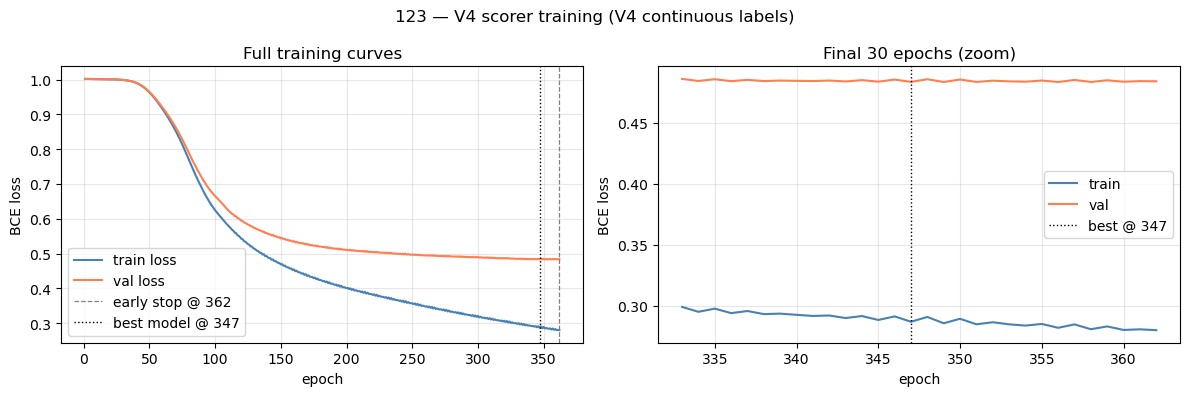

In [12]:
import numpy as np
import matplotlib.pyplot as plt

MAX_TRAINING_HISTORY_PLOTS = None  # set to an int to limit plots during large sweeps

runs_to_plot = lp_training_runs
if MAX_TRAINING_HISTORY_PLOTS is not None:
    runs_to_plot = runs_to_plot[:MAX_TRAINING_HISTORY_PLOTS]

for run in runs_to_plot:
    history = run["lp_model"].training_history

    train_losses = np.asarray(history["train_losses"], dtype=float)
    val_losses = np.asarray(history["val_losses"], dtype=float)

    stopped_at = int(history["stopped_at"])
    best_epoch = history.get("best_epoch")
    early_stopped = bool(history.get("early_stopped", False))

    epochs_run = len(train_losses)

    if epochs_run == 0:
        print(f"Skipping {run['lp_model_label']}: no completed training epochs.")
        continue

    if len(val_losses) != epochs_run:
        raise RuntimeError(
            "train_losses and val_losses have different lengths: "
            f"{epochs_run} and {len(val_losses)}."
        )

    ep_axis = np.arange(1, epochs_run + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(ep_axis, train_losses, label="train loss")
    axes[0].plot(ep_axis, val_losses, label="val loss")

    stop_label = (
        f"early stop @ {stopped_at}"
        if early_stopped
        else f"training ended @ {stopped_at}"
    )

    axes[0].axvline(stopped_at, linestyle="--", linewidth=0.9, label=stop_label)

    if best_epoch is not None:
        axes[0].axvline(best_epoch, linestyle=":", linewidth=1.0, label=f"best model @ {best_epoch}")

    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("BCE loss")
    axes[0].set_title("Full training curves")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    z = min(30, epochs_run)

    axes[1].plot(ep_axis[-z:], train_losses[-z:], label="train")
    axes[1].plot(ep_axis[-z:], val_losses[-z:], label="val")

    if best_epoch is not None and best_epoch >= ep_axis[-z]:
        axes[1].axvline(best_epoch, linestyle=":", linewidth=1.0, label=f"best @ {best_epoch}")

    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("BCE loss")
    axes[1].set_title(f"Final {z} epochs (zoom)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(
        f"LP-GNN training | {run['candidate_config_id']} | {run['mining_mode']}",
        fontsize=12,
    )

    plt.tight_layout()
    plt.show()


In [16]:
from helpers.selector_pipeline_helpers import accuracy
from pathlib import Path
from IPython.display import display

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


# ============================================================
# Configuration
# ============================================================

# Evaluate the cumulative attack every this many candidates.
BLOCK_STEP_SELECTOR = 10

# Batch size when scoring candidates with the LP-GNN.
SCORE_BATCH_SIZE = 100_000

# One random ordering is enough here because the multiseed notebook handles seed variation.
RANDOM_RUN_INDEX = 0
RANDOM_SEED = 42
CANDIDATE_RANDOM_SEED = 123

SELECTOR_EVAL_OUT_DIR = Path("../extendedPlotting") / "selector_evaluation"
SELECTOR_EVAL_OUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# Random candidate sampling
# ============================================================

def sample_random_undirected_pairs(
    num_nodes: int,
    num_candidates: int,
    seed: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Uniformly sample unique undirected node pairs (u, v), where u < v.
    The complete set of N(N-1)/2 node pairs is never explicitly constructed.
    """

    if num_nodes < 2:
        raise ValueError("The graph must contain at least two nodes.")

    total_possible_edges = num_nodes * (num_nodes - 1) // 2
    num_candidates = min(int(num_candidates), total_possible_edges)

    if num_candidates <= 0:
        raise ValueError("num_candidates must be greater than zero.")

    rng = random.Random(seed)

    sampled_linear_indices = torch.tensor(
        rng.sample(range(total_possible_edges), num_candidates),
        dtype=torch.long,
    )

    row_lengths = torch.arange(num_nodes - 1, 0, -1, dtype=torch.long)
    row_starts = torch.zeros(num_nodes, dtype=torch.long)
    row_starts[1:] = torch.cumsum(row_lengths, dim=0)

    cand_src = torch.searchsorted(row_starts, sampled_linear_indices, right=True) - 1
    offset_within_row = sampled_linear_indices - row_starts[cand_src]
    cand_dst = cand_src + 1 + offset_within_row

    assert torch.all(cand_src < cand_dst)
    assert cand_src.numel() == num_candidates
    assert cand_dst.numel() == num_candidates

    return cand_src, cand_dst


def evaluate_lp_gnn_ranking_for_run(run, run_index: int):
    selector_model = run["lp_model"]
    victim_model = model
    selector_device = next(selector_model.parameters()).device

    if adj_orig.ndim != 2:
        raise ValueError("adj_orig must be a two-dimensional adjacency matrix.")

    if adj_orig.size(0) != adj_orig.size(1):
        raise ValueError("adj_orig must be square.")

    num_nodes = int(adj_orig.size(0))
    n_random_candidates = int(run["candidate_set_size"])

    cand_src_t, cand_dst_t = sample_random_undirected_pairs(
        num_nodes=num_nodes,
        num_candidates=n_random_candidates,
        seed=CANDIDATE_RANDOM_SEED + run_index,
    )

    n_cands_eval = cand_src_t.numel()
    total_possible_edges = num_nodes * (num_nodes - 1) // 2

    cand_src_adj = cand_src_t.to(adj_orig.device)
    cand_dst_adj = cand_dst_t.to(adj_orig.device)

    exists_t = (adj_orig[cand_src_adj, cand_dst_adj] != 0).to(
        device="cpu",
        dtype=torch.float32,
    )

    del cand_src_adj
    del cand_dst_adj

    candidate_edge_index = torch.stack([cand_src_t, cand_dst_t], dim=0).to(selector_device)

    n_add_candidates = int((exists_t < 0.5).sum().item())
    n_delete_candidates = int((exists_t > 0.5).sum().item())

    print("=" * 80)
    print(
        "LP-GNN ranking evaluation:",
        run["lp_model_label"],
        f"\n  nodes:                    {num_nodes:,}"
        f"\n  all possible pairs:       {total_possible_edges:,}"
        f"\n  sampled candidates:       {n_cands_eval:,}"
        f"\n  edge-addition candidates: {n_add_candidates:,}"
        f"\n  edge-deletion candidates: {n_delete_candidates:,}",
    )

    selector_model.eval()

    with torch.no_grad():
        node_embeddings = selector_model.encoder(
            attr.to(selector_device),
            edge_index.to(selector_device),
        )

        selector_scores = torch.empty(
            n_cands_eval,
            dtype=torch.float32,
            device=selector_device,
        )

        for start in range(0, n_cands_eval, SCORE_BATCH_SIZE):
            end = min(start + SCORE_BATCH_SIZE, n_cands_eval)
            candidate_batch = candidate_edge_index[:, start:end]
            logits = selector_model.edge_head(node_embeddings, candidate_batch).view(-1)
            selector_scores[start:end] = torch.sigmoid(logits)

    selector_scores = selector_scores.cpu()

    assert torch.isfinite(selector_scores).all(), (
        "The selector produced NaN or infinite candidate scores."
    )

    sort_order = torch.argsort(selector_scores, descending=True)

    top_examples = []
    for rank, candidate_idx in enumerate(sort_order[:10].tolist(), start=1):
        edge_exists = exists_t[candidate_idx].item() > 0.5
        top_examples.append({
            "lp_model_label": run["lp_model_label"],
            "rank": rank,
            "candidate_idx": candidate_idx,
            "src": int(cand_src_t[candidate_idx].item()),
            "dst": int(cand_dst_t[candidate_idx].item()),
            "exists": int(edge_exists),
            "action": "delete" if edge_exists else "add",
            "selector_score": float(selector_scores[candidate_idx].item()),
        })

    display(pd.DataFrame(top_examples))

    block_sizes = list(range(0, n_cands_eval, BLOCK_STEP_SELECTOR))
    if not block_sizes or block_sizes[-1] != n_cands_eval:
        block_sizes.append(n_cands_eval)

    def apply_candidate_flip(adjacency: torch.Tensor, candidate_idx: int) -> None:
        u = int(cand_src_t[candidate_idx].item())
        v = int(cand_dst_t[candidate_idx].item())
        original_exists = float(exists_t[candidate_idx].item())
        new_value = 1.0 - original_exists
        adjacency[u, v] = new_value
        adjacency[v, u] = new_value

    rows = []

    adj_selector = adj_orig.clone()
    previous_k = 0

    for k in block_sizes:
        newly_selected = sort_order[previous_k:k].tolist()

        for candidate_idx in newly_selected:
            apply_candidate_flip(adj_selector, candidate_idx)

        selector_acc = accuracy(
            victim_model,
            attr,
            labels,
            idx_test,
            edge_index=adj_selector,
        )

        rows.append({
            "candidate_config_id": run["candidate_config_id"],
            "candidate_set_size": run["candidate_set_size"],
            "prbcd_candidate_fraction": run["prbcd_candidate_fraction"],
            "actual_prbcd_fraction": run["actual_prbcd_fraction"],
            "mining_mode": run["mining_mode"],
            "lp_model_label": run["lp_model_label"],
            "k": k,
            "attack": "top-k by LP-GNN score",
            "run": 0,
            "test_accuracy": float(selector_acc),
        })

        previous_k = k

    rng = np.random.default_rng(RANDOM_SEED + run_index)
    random_order = rng.permutation(n_cands_eval)

    adj_random = adj_orig.clone()
    previous_k = 0

    for k in block_sizes:
        newly_selected = random_order[previous_k:k].tolist()

        for candidate_idx in newly_selected:
            apply_candidate_flip(adj_random, candidate_idx)

        random_acc = accuracy(
            victim_model,
            attr,
            labels,
            idx_test,
            edge_index=adj_random,
        )

        rows.append({
            "candidate_config_id": run["candidate_config_id"],
            "candidate_set_size": run["candidate_set_size"],
            "prbcd_candidate_fraction": run["prbcd_candidate_fraction"],
            "actual_prbcd_fraction": run["actual_prbcd_fraction"],
            "mining_mode": run["mining_mode"],
            "lp_model_label": run["lp_model_label"],
            "k": k,
            "attack": "random candidates",
            "run": RANDOM_RUN_INDEX,
            "test_accuracy": float(random_acc),
        })

        previous_k = k

    selector_df = pd.DataFrame(rows)

    model_results = (
        selector_df[selector_df["attack"] == "top-k by LP-GNN score"]
        [["k", "test_accuracy"]]
        .rename(columns={"test_accuracy": "lp_gnn_accuracy"})
    )

    random_results = (
        selector_df[selector_df["attack"] == "random candidates"]
        [["k", "test_accuracy"]]
        .rename(columns={"test_accuracy": "random_accuracy"})
    )

    analysis_df = model_results.merge(random_results, on="k", how="left")
    analysis_df["lp_gnn_advantage"] = analysis_df["random_accuracy"] - analysis_df["lp_gnn_accuracy"]

    for key in [
        "candidate_config_id",
        "candidate_set_size",
        "prbcd_candidate_fraction",
        "actual_prbcd_fraction",
        "mining_mode",
        "lp_model_label",
    ]:
        analysis_df[key] = run[key]

    display(analysis_df.head(20))
    display(analysis_df.tail(20))

    safe_label = _safe_config_value(run["lp_model_label"])

    selector_df.to_csv(
        SELECTOR_EVAL_OUT_DIR / f"selector_eval_raw__{safe_label}.csv",
        index=False,
    )
    analysis_df.to_csv(
        SELECTOR_EVAL_OUT_DIR / f"selector_eval_summary__{safe_label}.csv",
        index=False,
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        analysis_df["k"],
        analysis_df["lp_gnn_accuracy"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label="top-k by LP-GNN score",
    )

    ax.plot(
        analysis_df["k"],
        analysis_df["random_accuracy"],
        linewidth=1.5,
        label="random order (one run)",
    )

    clean_baseline = float(run.get("clean_accuracy", np.nan))
    if np.isfinite(clean_baseline):
        ax.axhline(
            clean_baseline,
            linestyle="--",
            linewidth=0.9,
            label=f"clean baseline ({clean_baseline:.3f})",
        )

    ax.set_xlabel("k (randomly sampled candidate edges applied jointly)")
    ax.set_ylabel("test accuracy")
    ax.set_title(
        "LP-GNN ranking on randomly sampled all-pairs candidates\n"
        f"{run['candidate_config_id']} | {run['mining_mode']} | pool={n_cands_eval:,}"
    )
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return selector_df, analysis_df


selector_eval_frames = []
selector_analysis_frames = []

for run_index, run in enumerate(lp_training_runs):
    selector_df_run, analysis_df_run = evaluate_lp_gnn_ranking_for_run(run, run_index)
    selector_eval_frames.append(selector_df_run)
    selector_analysis_frames.append(analysis_df_run)

selector_eval_df = pd.concat(selector_eval_frames, ignore_index=True)
selector_analysis_df = pd.concat(selector_analysis_frames, ignore_index=True)

selector_eval_df.to_csv(SELECTOR_EVAL_OUT_DIR / "selector_eval_raw_all_configs.csv", index=False)
selector_analysis_df.to_csv(SELECTOR_EVAL_OUT_DIR / "selector_eval_summary_all_configs.csv", index=False)

print("Saved selector-evaluation CSVs to:", SELECTOR_EVAL_OUT_DIR.resolve())


Random candidate pool:
  nodes:                    2,810
  all possible pairs:       3,946,645
  sampled candidates:       23,943
  edge-addition candidates: 23,901
  edge-deletion candidates: 42

Selector score statistics:
  min:    0.027057
  mean:   0.298404
  median: 0.201545
  max:    0.998410

Top 10 candidates predicted by the LP-GNN:


,rank,candidate_idx,src,dst,exists,action,selector_score
0,1,17353,2643,2808,0,add,0.998410
1,2,13873,1526,2808,0,add,0.998394
2,3,3030,1901,2058,0,add,0.998089
3,4,13736,1537,2310,0,add,0.997712
4,5,16166,1509,2379,0,add,0.997277
5,6,4244,1257,1612,0,add,0.996979
6,7,11259,354,666,0,add,0.996624
7,8,20506,1526,1720,0,add,0.996519
8,9,12661,803,1800,0,add,0.996006
9,10,556,395,2684,0,add,0.996001


KeyboardInterrupt: 

---
## §6  Score Distributions & Ranking Quality

We score every candidate and ask:
- Do edges with V4 label > 0 (appeared in at least one harmful subset) receive higher logits?
- Does the predicted score *correlate* with the true continuous label?
- AUC-ROC (binary: scored vs unscored) and precision@k are computed as proxy metrics.

In [13]:
import torch
import numpy as np

# Your trained LinkPredictionGNN
scorer = lp_model
# Or:
# scorer = model

scorer.eval()

device = next(scorer.parameters()).device

# Node features used during scorer training
x_dev = attacker_x.to(device)

# Structural edges used by the GNN encoder
edge_index_struct_dev = edge_index.to(device)

# Candidate endpoint pairs to evaluate
src_dev = src.long().to(device)
dst_dev = dst.long().to(device)

if src_dev.numel() != dst_dev.numel():
    raise ValueError(
        f"src and dst must have equal length, got "
        f"{src_dev.numel()} and {dst_dev.numel()}."
    )

edge_index_lab_all = torch.stack(
    [src_dev, dst_dev],
    dim=0,
)

with torch.no_grad():
    all_logits = scorer(
        x_dev,
        edge_index_struct_dev,
        edge_index_lab_all,
    ).view(-1)

    all_probs = torch.sigmoid(all_logits)

all_logits_cpu = all_logits.cpu()
all_probs_cpu = all_probs.cpu()

labels_binary = labels_changed.view(-1).cpu() > 0

if labels_binary.numel() != all_logits_cpu.numel():
    raise ValueError(
        "labels_changed must contain one value per candidate pair. "
        f"Got {labels_binary.numel()} labels and "
        f"{all_logits_cpu.numel()} scorer outputs."
    )

pos_mask = labels_binary
neg_mask = ~labels_binary

pos_logits = all_logits_cpu[pos_mask]
neg_logits = all_logits_cpu[neg_mask]

pos_probs = all_probs_cpu[pos_mask]
neg_probs = all_probs_cpu[neg_mask]

print("Scorer output statistics")

if pos_logits.numel() > 0:
    print(
        f"Positive pairs ({pos_logits.numel()}): "
        f"logit mean={pos_logits.mean().item():.3f}, "
        f"logit std={pos_logits.std(unbiased=False).item():.3f}, "
        f"prob mean={pos_probs.mean().item():.3f}"
    )
else:
    print("Positive pairs: none")

if neg_logits.numel() > 0:
    print(
        f"Negative pairs ({neg_logits.numel()}): "
        f"logit mean={neg_logits.mean().item():.3f}, "
        f"logit std={neg_logits.std(unbiased=False).item():.3f}, "
        f"prob mean={neg_probs.mean().item():.3f}"
    )
else:
    print("Negative pairs: none")

fraction_predicted_positive = (
    all_probs_cpu >= 0.5
).float().mean().item()

print(
    f"Fraction predicted positive at threshold 0.5: "
    f"{fraction_predicted_positive:.3f}"
)

Scorer output statistics
Positive pairs (6642): logit mean=2.400, logit std=1.509, prob mean=0.854
Negative pairs (17301): logit mean=-1.512, logit std=1.005, prob mean=0.211
Fraction predicted positive at threshold 0.5: 0.325


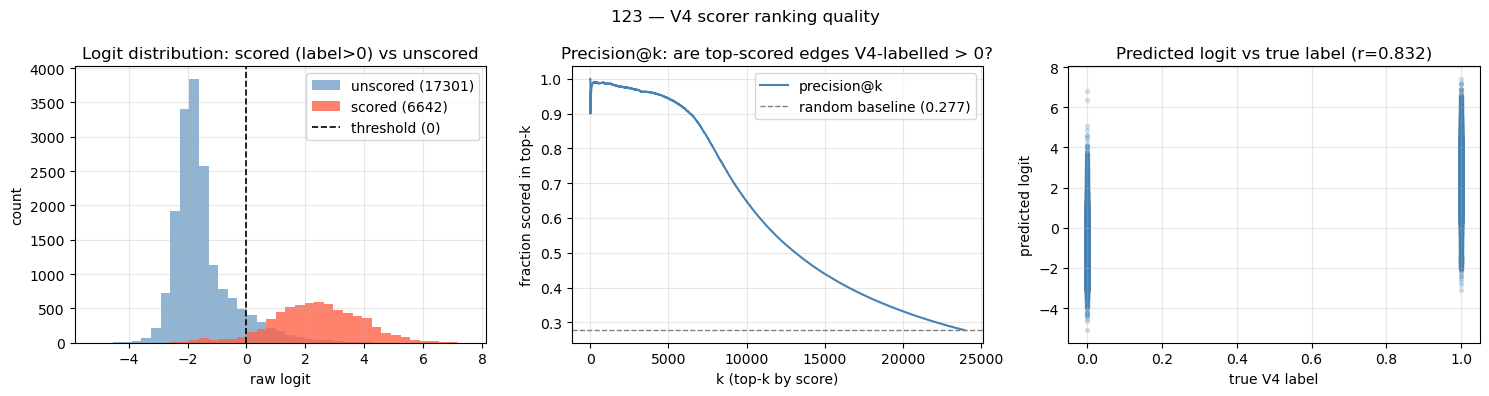

In [14]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

clear_output(wait=True)
plt.close("all")

lbl_bin = (lbl_bal.cpu() > 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Logit histogram: scored vs unscored
all_vals = np.concatenate([pos_logits, neg_logits])
lo, hi = all_vals.min() - 0.1, all_vals.max() + 0.1
bins = np.linspace(lo, hi, 40)

axes[0].hist(neg_logits, bins=bins, alpha=0.6, label=f'unscored ({len(neg_logits)})', color='steelblue')
axes[0].hist(pos_logits, bins=bins, alpha=0.8, label=f'scored ({len(pos_logits)})', color='tomato')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.2, label='threshold (0)')
axes[0].set_xlabel('raw logit')
axes[0].set_ylabel('count')
axes[0].set_title('Logit distribution: scored (label>0) vs unscored')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision@k
sort_order_logit = all_logits.argsort(descending=True)
sorted_lbl_bin = lbl_bin[sort_order_logit].numpy().astype(float)
cum_pos = sorted_lbl_bin.cumsum()
rank = np.arange(1, len(sorted_lbl_bin) + 1)
random_base = lbl_bin.float().mean().item()

axes[1].plot(rank, cum_pos / rank, color='steelblue', linewidth=1.5, label='precision@k')
axes[1].axhline(random_base, color='grey', linestyle='--', linewidth=1, label=f'random baseline ({random_base:.3f})')
axes[1].set_xlabel('k (top-k by score)')
axes[1].set_ylabel('fraction scored in top-k')
axes[1].set_title('Precision@k: are top-scored edges V4-labelled > 0?')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Correlation
lbl_cont = labels_changed.detach().cpu().numpy().reshape(-1)
lg_np = all_logits.detach().cpu().numpy().reshape(-1)

print(lbl_cont.shape, lg_np.shape)

axes[2].scatter(lbl_cont, lg_np, alpha=0.2, s=8, color='steelblue')
axes[2].set_xlabel('true V4 label')
axes[2].set_ylabel('predicted logit')
axes[2].set_title('Predicted logit vs true continuous label')

if lbl_cont.std() > 1e-8 and lg_np.std() > 1e-8:
    corr = float(np.corrcoef(lbl_cont, lg_np)[0, 1])
    axes[2].set_title(f'Predicted logit vs true label (r={corr:.3f})')

axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{123} — V4 scorer ranking quality', fontsize=12)
plt.tight_layout()
plt.show()

AUC-ROC (scored vs unscored): 0.9745
Avg Precision:                0.9385  (random baseline = 0.2774)


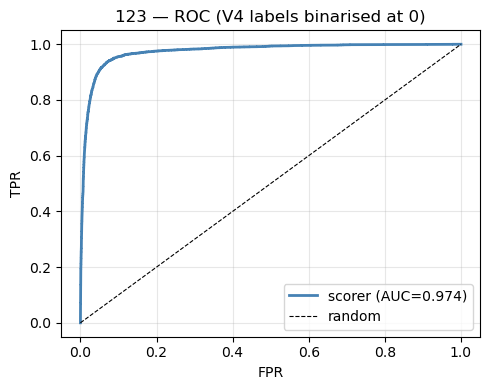

In [15]:
try:
    from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
    y_true  = lbl_bin.numpy().astype(int)
    y_score = all_logits.numpy()

    auc = roc_auc_score(y_true, y_score)
    ap  = average_precision_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)

    print(f'AUC-ROC (scored vs unscored): {auc:.4f}')
    print(f'Avg Precision:                {ap:.4f}  (random baseline = {random_base:.4f})')

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'scorer (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='random')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'{123} — ROC (V4 labels binarised at 0)')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except ImportError:
    print('sklearn not available — skipping ROC')

---
## §7  Per-Node Analysis

For each node in the candidate set, we check:
- How many of its incident candidate edges have a non-zero V4 label?
- What is the mean predicted logit for scored vs unscored incident edges?
- A positive score gap means the scorer correctly prefers harmful incident edges for this node.

In [17]:
from collections import defaultdict
import pandas as pd

src_np    = src.cpu().numpy()
dst_np    = dst.cpu().numpy()
lbl_np_cn = labels_changed.cpu().numpy()
lg_np_cn  = all_logits.numpy()

node_to_cands = defaultdict(list)
for i in range(len(src_np)):
    u, v  = int(src_np[i]), int(dst_np[i])
    entry = (i, bool(lbl_np_cn[i] > 0), float(lbl_np_cn[i]), float(lg_np_cn[i]))
    node_to_cands[u].append(entry)
    node_to_cands[v].append(entry)

node_rows = []
for node, cands in node_to_cands.items():
    n_inc     = len(cands)
    n_pos_cn  = sum(1 for _, is_pos, _, _ in cands if is_pos)
    p_lgts    = [lg for _, is_pos, _, lg in cands if is_pos]
    n_lgts    = [lg for _, is_pos, _, lg in cands if not is_pos]
    node_rows.append({
        'node':           node,
        'degree':         int(degrees[node]),
        'n_incident':     n_inc,
        'n_scored':       n_pos_cn,
        'scored_rate':    n_pos_cn / n_inc,
        'mean_score_pos': float(np.mean(p_lgts)) if p_lgts else float('nan'),
        'mean_score_neg': float(np.mean(n_lgts)) if n_lgts else float('nan'),
    })

node_df = pd.DataFrame(node_rows)
print(f'Nodes with at least one incident candidate: {len(node_df)}')
print(f"Nodes with >= 1 scored candidate: {(node_df['n_scored'] > 0).sum()}")
display(node_df.describe())

Nodes with at least one incident candidate: 2810
Nodes with >= 1 scored candidate: 2219


,node,degree,n_incident,n_scored,scored_rate,mean_score_pos,mean_score_neg
count,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,2219.000000,2802.000000
mean,1404.500000,5.680427,17.041281,4.727402,0.221004,2.024837,-1.497695
std,811.321453,8.453357,14.006346,8.410253,0.209825,1.160520,0.696101
min,0.000000,1.000000,2.000000,0.000000,0.000000,-2.390507,-3.170888
25%,702.250000,2.000000,10.000000,1.000000,0.066667,1.398902,-1.914059
50%,1404.500000,4.000000,14.000000,2.000000,0.166667,2.091773,-1.648799
75%,2106.750000,7.000000,19.000000,5.000000,0.333333,2.773982,-1.280958
max,2809.000000,246.000000,321.000000,184.000000,1.000000,6.321554,3.680305


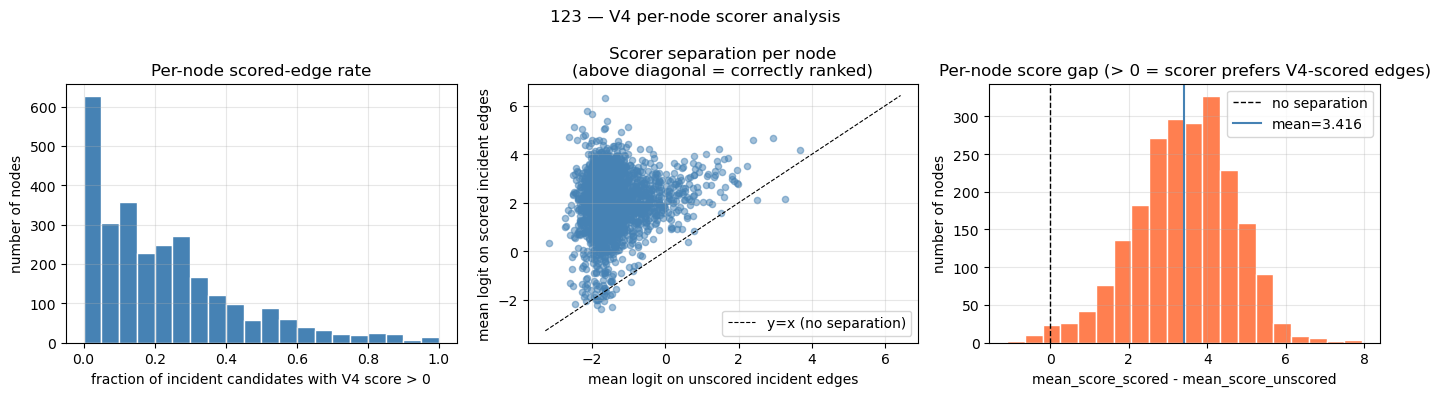

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(node_df['scored_rate'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('fraction of incident candidates with V4 score > 0')
axes[0].set_ylabel('number of nodes')
axes[0].set_title('Per-node scored-edge rate')
axes[0].grid(True, alpha=0.3)

has_both = node_df.dropna(subset=['mean_score_pos', 'mean_score_neg'])
axes[1].scatter(has_both['mean_score_neg'], has_both['mean_score_pos'],
                alpha=0.5, s=20, color='steelblue')
lo = min(has_both['mean_score_neg'].min(), has_both['mean_score_pos'].min()) - 0.1
hi = max(has_both['mean_score_neg'].max(), has_both['mean_score_pos'].max()) + 0.1
axes[1].plot([lo, hi], [lo, hi], 'k--', linewidth=0.8, label='y=x (no separation)')
axes[1].set_xlabel('mean logit on unscored incident edges')
axes[1].set_ylabel('mean logit on scored incident edges')
axes[1].set_title('Scorer separation per node\n(above diagonal = correctly ranked)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

hb = has_both.copy()
hb['score_gap'] = hb['mean_score_pos'] - hb['mean_score_neg']
axes[2].hist(hb['score_gap'], bins=20, color='coral', edgecolor='white')
axes[2].axvline(0, color='black', linestyle='--', linewidth=1, label='no separation')
axes[2].axvline(hb['score_gap'].mean(), color='steelblue', linestyle='-',
                linewidth=1.5, label=f"mean={hb['score_gap'].mean():.3f}")
axes[2].set_xlabel('mean_score_scored - mean_score_unscored')
axes[2].set_ylabel('number of nodes')
axes[2].set_title('Per-node score gap (> 0 = scorer prefers V4-scored edges)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{123} — V4 per-node scorer analysis', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Model Guided PR-BCD

In [19]:
# %% Cell 1: define the sweep
from copy import deepcopy
from itertools import product

# Values in these dictionaries are combined with a Cartesian product.
EXPERIMENT_SWEEP = {
    "attack": ["PRBCD"],
    "semi": [True],
    "epsilon": [0.1],
    "use_cert": ["accuracy_drop_selector", "none", "accuracy_drop_selector_with_resampling"],
    "seed": [SEED],
}

ATTACK_SWEEP = {
    "block_size": [4000],
    "epochs": [300],
    "fine_tune_epochs": [250],
    "keep_heuristic": ["WeightOnly"],
    "do_synchronize": [True],
    "loss_type": ["tanhMargin"],
}

SELECTOR_SWEEP = {
    "accuracy_drop_selector_mode": ["one_sample"],
    "n_candidates_k_sample": [2_000],
    "n_candidates_one_sample": [5_000],
    "drop_mode": ["endpoint"],
    "acc_drop_threshold_k_samples": [1e-3],
    "loss_drop_threshold_k_samples": [1e-3],
    "k_samples_batch": [10],
    "training_data_node_cap": [15],
    "tau": [0.8],
    "score_batch_size": [1_000],
    "max_sampling_tries": [2_000_000],
    "exclude_tried": [True],
}

# Passed to every selector run, but not expanded as sweep dimensions.
SELECTOR_FIXED = {
    "lp_hit_rate_detour": False,
    "lp_hit_rate_top_k": 200,
    "lp_hit_rate_out_dir": "extendedPlotting/lpEndpointHitRate",
}

# Keep Python model objects out of the CSV. The key and metadata are logged;
# the model object itself is passed to the attack.
if "lp_model_variants" in globals() and lp_model_variants:
    LP_MODEL_VARIANTS = lp_model_variants
else:
    LP_MODEL_VARIANTS = {
        "default": {
            "model": lp_model,
            "candidate_config_id": "default",
            "candidate_set_size": globals().get("n_cands", ""),
            "prbcd_candidate_fraction": globals().get("PRBCD_CANDIDATE_FRACTION", ""),
            "actual_prbcd_fraction": globals().get("actual_prbcd_fraction", ""),
            "mining_mode": globals().get("MINING_MODE", ""),
            "n_prbcd_requested": "",
            "n_prbcd_mined_unique": "",
            "n_prbcd_selected": "",
            "n_random_candidates": "",
            "n_positive_labels": "",
            "label_mode": globals().get("LABEL_MODE", ""),
        }
    }

ADS_CERTS = {
    "accuracy_drop_selector",
    "accuracy_drop_selector_with_resampling",
    "direct_selector",
}

ADS_ONLY_SELECTOR_KEYS = {
    "accuracy_drop_selector_mode",
    "n_candidates_k_sample",
    "n_candidates_one_sample",
    "drop_mode",
    "acc_drop_threshold_k_samples",
    "loss_drop_threshold_k_samples",
    "k_samples_batch",
    "training_data_node_cap",
}


def expand_grid(grid):
    """Yield one dictionary for every Cartesian-product combination."""
    keys = list(grid)
    for values in product(*(grid[key] for key in keys)):
        yield dict(zip(keys, values))


def _split_lp_model_variant(lp_model_variant):
    if isinstance(lp_model_variant, dict) and "model" in lp_model_variant:
        lp_model_object = lp_model_variant["model"]
        lp_model_metadata = {
            key: value
            for key, value in lp_model_variant.items()
            if key != "model"
        }
    else:
        lp_model_object = lp_model_variant
        lp_model_metadata = {}

    return lp_model_object, lp_model_metadata


def build_sweep_configs():
    experiment_configs = list(expand_grid(EXPERIMENT_SWEEP))
    attack_configs = list(expand_grid(ATTACK_SWEEP))
    selector_configs = list(expand_grid(SELECTOR_SWEEP))

    configs = []
    for experiment_cfg in experiment_configs:
        use_cert = experiment_cfg["use_cert"]

        for attack_cfg in attack_configs:
            for selector_cfg_full in selector_configs:
                selector_cfg = deepcopy(selector_cfg_full)
                selector_cfg.update(deepcopy(SELECTOR_FIXED))

                # Do not pass ADS-only parameters to unrelated attack modes.
                if use_cert not in ADS_CERTS:
                    selector_cfg = {
                        key: value
                        for key, value in selector_cfg.items()
                        if key not in ADS_ONLY_SELECTOR_KEYS
                    }

                for lp_model_label, lp_model_variant in LP_MODEL_VARIANTS.items():
                    lp_model_object, lp_model_metadata = _split_lp_model_variant(lp_model_variant)

                    configs.append({
                        "experiment": deepcopy(experiment_cfg),
                        "attack_params": {
                            **deepcopy(attack_cfg),
                            "lp_model": lp_model_object,
                        },
                        "selector_params": deepcopy(selector_cfg),
                        "log_values": {
                            "lp_model_label": lp_model_label,
                            **deepcopy(lp_model_metadata),
                        },
                    })

    return configs


EXPERIMENT_COLUMNS = list(EXPERIMENT_SWEEP)
ATTACK_COLUMNS = list(ATTACK_SWEEP)
SELECTOR_COLUMNS = list(SELECTOR_SWEEP) + [
    key for key in SELECTOR_FIXED if key not in SELECTOR_SWEEP
]
LOG_COLUMNS = [
    "lp_model_label",
    "candidate_config_id",
    "candidate_set_size",
    "prbcd_candidate_fraction",
    "actual_prbcd_fraction",
    "mining_mode",
    "n_prbcd_requested",
    "n_prbcd_mined_unique",
    "n_prbcd_selected",
    "n_random_candidates",
    "n_positive_labels",
    "label_mode",
]

ALL_CONFIG_COLUMNS = (
    [f"experiment__{key}" for key in EXPERIMENT_COLUMNS]
    + [f"attack__{key}" for key in ATTACK_COLUMNS]
    + [f"selector__{key}" for key in SELECTOR_COLUMNS]
    + [f"log__{key}" for key in LOG_COLUMNS]
)


def config_to_row(cfg):
    row = {}
    for key in EXPERIMENT_COLUMNS:
        row[f"experiment__{key}"] = cfg["experiment"].get(key, "")
    for key in ATTACK_COLUMNS:
        row[f"attack__{key}"] = cfg["attack_params"].get(key, "")
    for key in SELECTOR_COLUMNS:
        row[f"selector__{key}"] = cfg["selector_params"].get(key, "")
    for key in LOG_COLUMNS:
        row[f"log__{key}"] = cfg["log_values"].get(key, "")
    return row


sweep_configs = build_sweep_configs()
print(f"Number of configurations: {len(sweep_configs)}")

for index, cfg in enumerate(sweep_configs, start=1):
    exp = cfg["experiment"]
    selector = cfg["selector_params"]
    log_values = cfg["log_values"]
    print(
        f"{index:03d}: attack={exp['attack']}, cert={exp['use_cert']}, "
        f"epsilon={exp['epsilon']}, seed={exp['seed']}, "
        f"candidate_config={log_values.get('candidate_config_id', '-')}, "
        f"mining_mode={log_values.get('mining_mode', '-')}, "
        f"candidate_set_size={log_values.get('candidate_set_size', '-')}, "
        f"prbcd_fraction={log_values.get('prbcd_candidate_fraction', '-')}, "
        f"drop_mode={selector.get('drop_mode', '-')}, "
        f"tau={selector.get('tau', '-')}"
    )


Number of configurations: 3
001: attack=PRBCD, cert=accuracy_drop_selector, epsilon=0.1, seed=0, mode=one_sample, drop_mode=endpoint, tau=0.8
002: attack=PRBCD, cert=none, epsilon=0.1, seed=0, mode=-, drop_mode=-, tau=0.8
003: attack=PRBCD, cert=accuracy_drop_selector_with_resampling, epsilon=0.1, seed=0, mode=one_sample, drop_mode=endpoint, tau=0.8


In [29]:
# %% Cell 2: run the sweep and append CSV logs
from DeleteCache import delete_pert_files_and_folders
from timeit import default_timer as timer
from datetime import datetime
import csv
import gc
import hashlib
import json
import os
import traceback

import numpy as np
import torch
from sparse_smoothing.utils import load_and_standardize

# -------------------------
# Behaviour
# -------------------------
STOP_ON_ERROR = False
SAVE_RAW_RESULTS = False

MODEL_STORAGE_TYPE = "demo_custom_split"
ARTIFACT_DIR = "cache"
PERT_ADJ_STORAGE_TYPE = "evasion_global_adj"
PERT_ATTR_STORAGE_TYPE = "evasion_global_attr"

def _folder_safe_value(value):
    """Convert a config value into a compact, filesystem-safe string."""
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu().item() if value.numel() == 1 else value.detach().cpu().tolist()
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, (list, tuple)):
        return "-".join(_folder_safe_value(item) for item in value)
    if value is None:
        return "na"

    text = f"{value:.12g}" if isinstance(value, float) else str(value)
    return (
        text.strip()
        .replace(" ", "")
        .replace("/", "-")
        .replace("\\", "-")
        .replace(".", "p")
        .replace("+", "")
        .replace("-", "m")
    )


def _read_nested_config(cfg, candidate_paths):
    """Return the first configured value found among the candidate paths."""
    for section_name, key in candidate_paths:
        section = cfg.get(section_name, {})
        if key in section and section[key] is not None:
            return section[key]
    return None


def _collect_sweep_values(candidate_paths):
    """Collect unique values in sweep order for one signature field."""
    values = []
    seen = set()

    for cfg in sweep_configs:
        value = _read_nested_config(cfg, candidate_paths)
        safe_value = _folder_safe_value(value)
        if safe_value not in seen:
            seen.add(safe_value)
            values.append(safe_value)

    return "+".join(values) if values else "na"


FOLDER_SIGNATURE = "__".join([
    "block_size-" + _collect_sweep_values([
        ("attack_params", "block_size"),
    ]),
    "candN-" + _collect_sweep_values([
        ("log_values", "candidate_set_size"),
    ]),
    "prbcdFrac-" + _collect_sweep_values([
        ("log_values", "prbcd_candidate_fraction"),
    ]),
    "miningMode-" + _collect_sweep_values([
        ("log_values", "mining_mode"),
    ]),
    "tau-" + _collect_sweep_values([
        ("selector_params", "tau"),
        ("attack_params", "tau"),
        ("experiment", "tau"),
    ]),
    "epsilon-" + _collect_sweep_values([
        ("experiment", "epsilon"),
        ("attack_params", "epsilon"),
        ("attack_params", "eps"),
    ]),
    "epochs-" + _collect_sweep_values([
        ("attack_params", "epochs"),
    ]),
])

RUN_GROUP_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = os.path.join(
    "../extendedPlotting",
    "sweeps",
    f"global_prbcd_{DATASET}__{FOLDER_SIGNATURE}__{RUN_GROUP_ID}",
)
os.makedirs(OUT_DIR, exist_ok=True)

SUMMARY_CSV = os.path.join(OUT_DIR, "summary.csv")
EPOCHS_CSV = os.path.join(OUT_DIR, "epochs.csv")
RAW_RESULT_DIR = os.path.join(OUT_DIR, "raw_results")
if SAVE_RAW_RESULTS:
    os.makedirs(RAW_RESULT_DIR, exist_ok=True)

SUMMARY_HEADER = [
    "run_group_id",
    "run_id",
    "config_index",
    "status",
    "dataset",
    "model_label",
    "model_storage_type",
    "use_cert_label",
    "accuracy",
    "runtime_seconds",
    "error_type",
    "error_message",
    "raw_result_path",
] + ALL_CONFIG_COLUMNS

EPOCHS_HEADER = [
    "run_group_id",
    "run_id",
    "config_index",
    "dataset",
    "model_label",
    "use_cert_label",
    "stat_idx",
    "epoch_idx",
    "phase",
    "accuracy",
    "loss",
    "nonzero_weights",
    "prob_mass_update",
    "prob_mass_projected",
] + ALL_CONFIG_COLUMNS


def to_python_scalar(value):
    if isinstance(value, torch.Tensor):
        if value.numel() == 1:
            return value.detach().cpu().item()
        return str(value.detach().cpu().tolist())
    if isinstance(value, np.generic):
        return value.item()
    if value is None:
        return ""
    if isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def append_dict_rows(path, fieldnames, rows):
    rows = list(rows)
    if not rows:
        return

    file_exists = os.path.isfile(path)
    if file_exists:
        with open(path, "r", newline="", encoding="utf-8") as handle:
            existing_header = next(csv.reader(handle), None)
        if existing_header != fieldnames:
            raise RuntimeError(
                f"CSV header mismatch in {path}.\n"
                f"Found:    {existing_header}\n"
                f"Expected: {fieldnames}"
            )

    with open(path, "a", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames, extrasaction="raise")
        if not file_exists:
            writer.writeheader()
        writer.writerows(rows)
        handle.flush()
        os.fsync(handle.fileno())


def make_use_cert_label(experiment_cfg, selector_params):
    use_cert = experiment_cfg["use_cert"]
    parts = [str(use_cert)]

    if use_cert in ADS_CERTS:
        for key, prefix in (
            ("accuracy_drop_selector_mode", "mode"),
            ("drop_mode", "drop"),
            ("training_data_node_cap", "cap"),
        ):
            value = selector_params.get(key)
            if value not in (None, ""):
                parts.append(f"{prefix}-{value}")

    return "__".join(parts)


def make_run_id(config_index, cfg):
    serializable_cfg = {
        key: to_python_scalar(value)
        for key, value in config_to_row(cfg).items()
    }
    digest = hashlib.sha1(
        json.dumps(serializable_cfg, sort_keys=True).encode("utf-8")
    ).hexdigest()[:10]
    return f"{RUN_GROUP_ID}_{config_index:04d}_{digest}"


def make_config_run_group_id(cfg):
    """
    Keep all rows from one candidate-size × PRBCD-fraction × mining-mode
    configuration together, while still storing them in one sweep folder.
    This prevents plotting cells from averaging different candidate configs.
    """
    candidate_label = (
        cfg.get("log_values", {}).get("candidate_config_id")
        or cfg.get("log_values", {}).get("lp_model_label")
    )

    mining_mode = cfg.get("log_values", {}).get("mining_mode")

    if candidate_label:
        suffix_parts = [str(candidate_label)]
        if mining_mode:
            suffix_parts.append(f"mode-{mining_mode}")
        return RUN_GROUP_ID + "__" + "__".join(suffix_parts)

    return RUN_GROUP_ID


def as_list(value):
    if value is None:
        return []
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu()
        return [value.item()] if value.ndim == 0 else value.reshape(-1).tolist()
    if isinstance(value, np.ndarray):
        return value.reshape(-1).tolist()
    if isinstance(value, (list, tuple)):
        return [to_python_scalar(item) for item in value]
    return [to_python_scalar(value)]


def is_metric_series(value):
    return isinstance(value, (list, tuple, np.ndarray, torch.Tensor))


def find_attack_statistics(obj, seen=None):
    """Find a nested PRBCD attack-statistics dictionary."""
    if seen is None:
        seen = set()

    obj_id = id(obj)
    if obj_id in seen:
        return None
    seen.add(obj_id)

    if isinstance(obj, dict):
        for key in ("attack_statistics", "attack_stats", "stats"):
            candidate = obj.get(key)
            if isinstance(candidate, dict) and (
                is_metric_series(candidate.get("accuracy"))
                or is_metric_series(candidate.get("loss"))
            ):
                return candidate

        if (
            is_metric_series(obj.get("accuracy"))
            and is_metric_series(obj.get("loss"))
        ):
            return obj

        for value in obj.values():
            found = find_attack_statistics(value, seen)
            if found is not None:
                return found

    elif isinstance(obj, (list, tuple)):
        for value in obj:
            found = find_attack_statistics(value, seen)
            if found is not None:
                return found

    return None


def extract_final_accuracy(result):
    if isinstance(result, dict):
        results = result.get("results")
        if isinstance(results, (list, tuple)) and results:
            first = results[0]
            if isinstance(first, dict) and "accuracy" in first:
                return to_python_scalar(first["accuracy"])

        accuracy = result.get("accuracy")
        if accuracy is not None and not is_metric_series(accuracy):
            return to_python_scalar(accuracy)

    raise KeyError("Could not find final accuracy in the experiment result.")


def build_epoch_rows(stats, cfg, run_id, config_index, use_cert_label):
    if not stats:
        return []

    metric_lists = {
        "accuracy": as_list(stats.get("accuracy")),
        "loss": as_list(stats.get("loss")),
        "nonzero_weights": as_list(stats.get("nonzero_weights")),
        "prob_mass_update": as_list(stats.get("probability_mass_update")),
        "prob_mass_projected": as_list(stats.get("probability_mass_projected")),
    }

    length = max((len(values) for values in metric_lists.values()), default=0)
    configured_epochs = int(cfg["attack_params"].get("epochs", 0))
    has_baseline = configured_epochs > 0 and length == configured_epochs + 1
    config_row = {
        key: to_python_scalar(value)
        for key, value in config_to_row(cfg).items()
    }

    rows = []
    for stat_idx in range(length):
        is_baseline = has_baseline and stat_idx == 0
        epoch_idx = -1 if is_baseline else stat_idx - 1 if has_baseline else stat_idx

        row = {
            "run_group_id": make_config_run_group_id(cfg),
            "run_id": run_id,
            "config_index": config_index,
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "use_cert_label": use_cert_label,
            "stat_idx": stat_idx,
            "epoch_idx": epoch_idx,
            "phase": "baseline" if is_baseline else "attack",
        }

        for metric_name, values in metric_lists.items():
            row[metric_name] = (
                to_python_scalar(values[stat_idx])
                if stat_idx < len(values)
                else ""
            )

        row.update(config_row)
        rows.append(row)

    return rows


# -------------------------
# Load the exact graph type required by the current run call
# -------------------------
graph_sparse = load_and_standardize(os.path.join("data", f"{DATASET}.npz"))

assert hasattr(graph_sparse, "attr_matrix")
assert hasattr(graph_sparse, "adj_matrix")
assert hasattr(graph_sparse, "labels")

print(
    "graph_sparse:",
    f"nodes={graph_sparse.attr_matrix.shape[0]}",
    f"features={graph_sparse.attr_matrix.shape[1]}",
    f"directed_edges={graph_sparse.adj_matrix.nnz}",
)
print("Summary CSV:", SUMMARY_CSV)
print("Epoch CSV:", EPOCHS_CSV)

# -------------------------
# Sweep
# -------------------------
results_global_prbcd_cert = []

for config_index, cfg in enumerate(sweep_configs, start=1):
    experiment_cfg = dict(cfg["experiment"])
    attack_params = dict(cfg["attack_params"])
    selector_params = dict(cfg["selector_params"])

    epsilon = experiment_cfg["epsilon"]
    semi = experiment_cfg["semi"]
    use_cert = experiment_cfg["use_cert"]
    seed = experiment_cfg["seed"]
    attack_name = experiment_cfg["attack"]

    use_cert_label = make_use_cert_label(experiment_cfg, selector_params)
    run_id = make_run_id(config_index, cfg)
    config_row = {
        key: to_python_scalar(value)
        for key, value in config_to_row(cfg).items()
    }

    print("=" * 80)
    print(f"Run {config_index}/{len(sweep_configs)}: {run_id}")
    print("attack:", attack_name)
    print("use_cert:", use_cert)
    print("attack_params:", attack_params)
    print("selector_params:", selector_params)

    delete_pert_files_and_folders(
        cache_dir=ARTIFACT_DIR,
        pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
        pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
    )

    start = timer()
    result = None
    raw_result_path = ""

    try:
        result = experiment_global_attack_direct.run(
            graph=graph_sparse,
            data_dir="./data",
            dataset=DATASET,
            attack=attack_name,
            attack_params=attack_params,
            selector_params=selector_params,
            epsilons=[epsilon],
            binary_attr=False,
            make_undirected=True,
            seed=seed,
            artifact_dir=ARTIFACT_DIR,
            pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
            pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
            model_label=MODEL_LABEL,
            model_storage_type=MODEL_STORAGE_TYPE,
            device="cpu",
            data_device="cpu",
            debug_level="info",
            semi=semi,
            use_cert=use_cert,
        )

        elapsed = timer() - start
        final_accuracy = extract_final_accuracy(result)

        stats = find_attack_statistics(result)
        epoch_rows = build_epoch_rows(
            stats=stats,
            cfg=cfg,
            run_id=run_id,
            config_index=config_index,
            use_cert_label=use_cert_label,
        )
        append_dict_rows(EPOCHS_CSV, EPOCHS_HEADER, epoch_rows)

        if not epoch_rows:
            print("[warn] No per-epoch attack statistics found in the returned result.")

        if SAVE_RAW_RESULTS:
            raw_result_path = os.path.join(RAW_RESULT_DIR, f"{run_id}.pt")
            torch.save(result, raw_result_path)

        summary_row = {
            "run_group_id": make_config_run_group_id(cfg),
            "run_id": run_id,
            "config_index": config_index,
            "status": "ok",
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "model_storage_type": MODEL_STORAGE_TYPE,
            "use_cert_label": use_cert_label,
            "accuracy": final_accuracy,
            "runtime_seconds": elapsed,
            "error_type": "",
            "error_message": "",
            "raw_result_path": raw_result_path,
            **config_row,
        }
        append_dict_rows(SUMMARY_CSV, SUMMARY_HEADER, [summary_row])

        results_global_prbcd_cert.append({
            "run_id": run_id,
            "use_cert_label": use_cert_label,
            "accuracy": final_accuracy,
            "runtime_seconds": elapsed,
            "status": "ok",
        })

        print(f"Final accuracy: {final_accuracy}")
        print(f"Runtime: {elapsed:.2f} seconds")

        clear_output(wait=True)

    except Exception as exc:
        elapsed = timer() - start
        error_message = "".join(
            traceback.format_exception_only(type(exc), exc)
        ).strip()

        summary_row = {
            "run_group_id": make_config_run_group_id(cfg),
            "run_id": run_id,
            "config_index": config_index,
            "status": "error",
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "model_storage_type": MODEL_STORAGE_TYPE,
            "use_cert_label": use_cert_label,
            "accuracy": "",
            "runtime_seconds": elapsed,
            "error_type": type(exc).__name__,
            "error_message": error_message,
            "raw_result_path": "",
            **config_row,
        }
        append_dict_rows(SUMMARY_CSV, SUMMARY_HEADER, [summary_row])

        results_global_prbcd_cert.append({
            "run_id": run_id,
            "use_cert_label": use_cert_label,
            "accuracy": None,
            "runtime_seconds": elapsed,
            "status": "error",
            "error": error_message,
        })

        print(f"[error] {error_message}")
        traceback.print_exc()

        if STOP_ON_ERROR:
            raise

    finally:
        del result
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("=" * 80)
print("Sweep finished.")
print("Summary CSV:", SUMMARY_CSV)
print("Epoch CSV:", EPOCHS_CSV)


Duplicate epoch-accuracy plotting cell removed. The following cell keeps the richer plot version with maximum accuracy-difference analysis.


Found 9 epoch CSV file(s).
 - extendedPlotting\sweeps\global_prbcd_cora_ml_20260623_161227\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_132926\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_133732\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-20000__tau-0p8__epsilon-0p05__epochs-100__20260624_142349\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000__tau-0p8__epsilon-0p05__epochs-100__20260624_144122\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-4000__tau-0p8__epsilon-0p05__epochs-100__20260628_133648\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-4000__tau-0p8__epsilon-0p05__epochs-100__20260629_020044\epochs.csv
 - extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-5000__tau-0p8__epsilon-0p0

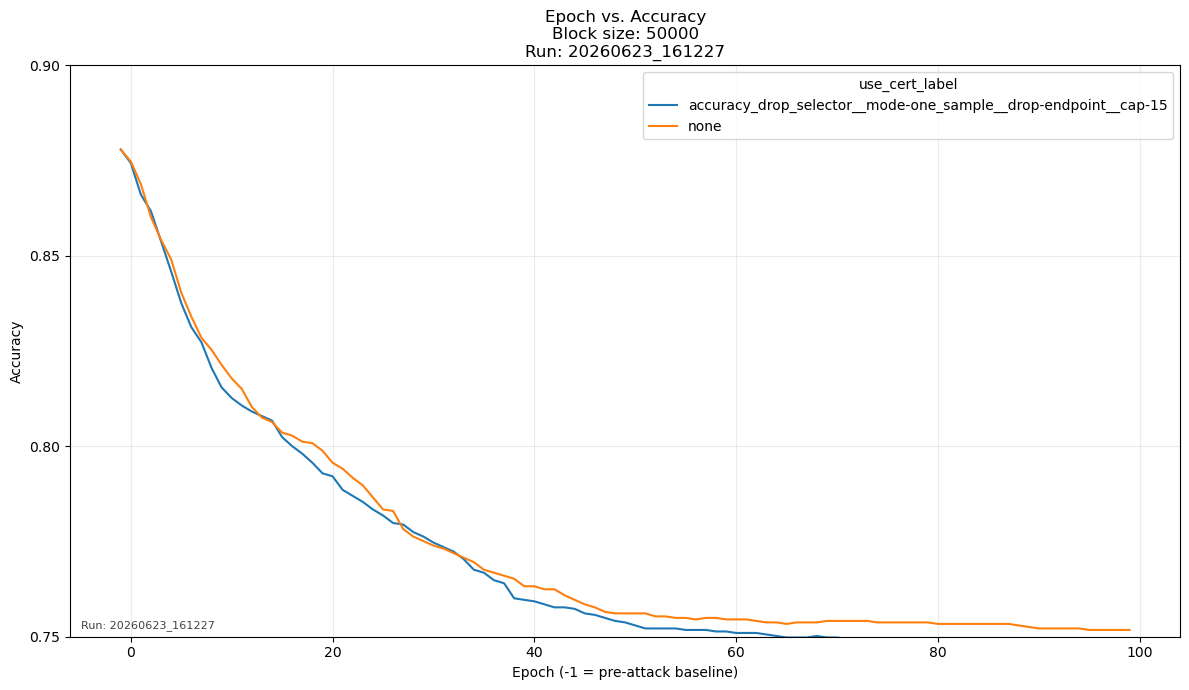


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_132926\epochs.csv

----------------------------------------------------------------------------------------------------
Run: 20260624_132926
Block sizes: ['50000']
Output folder: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_132926\plots__run-20260624_132926
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_132926\plots__run-20260624_132926\epoch_accuracy__run-20260624_132926__block_size-50000.png


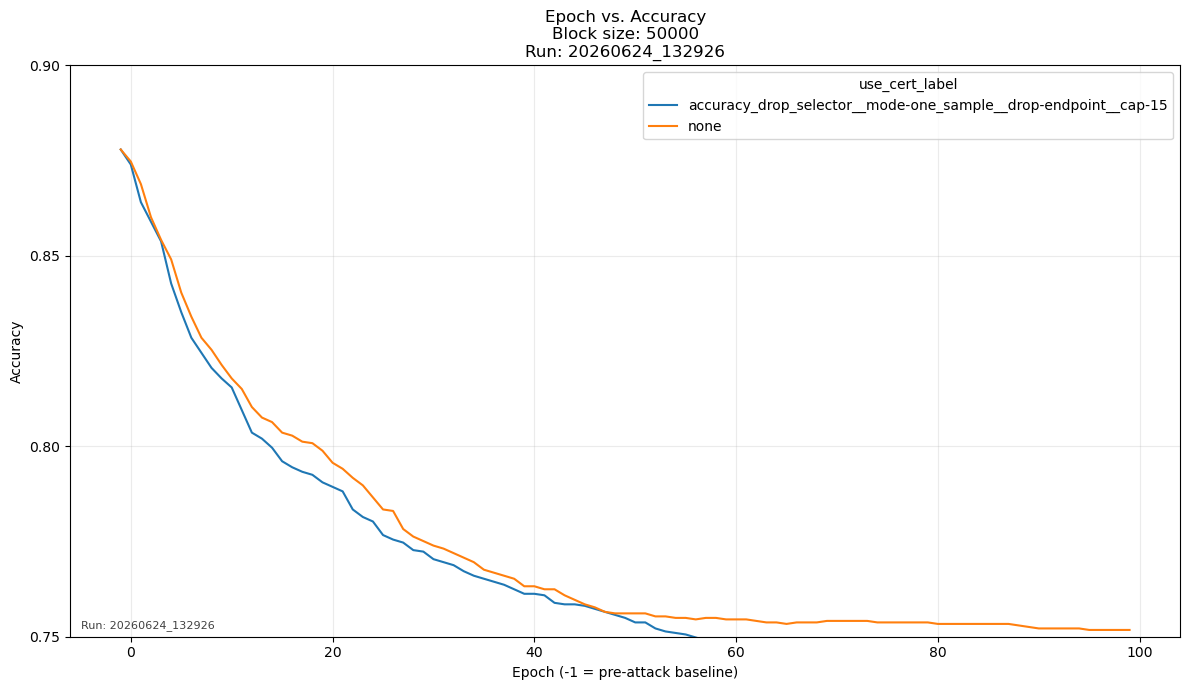


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_133732\epochs.csv

----------------------------------------------------------------------------------------------------
Run: 20260624_133732
Block sizes: ['50000']
Output folder: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_133732\plots__run-20260624_133732
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml_20260624_133732\plots__run-20260624_133732\epoch_accuracy__run-20260624_133732__block_size-50000.png


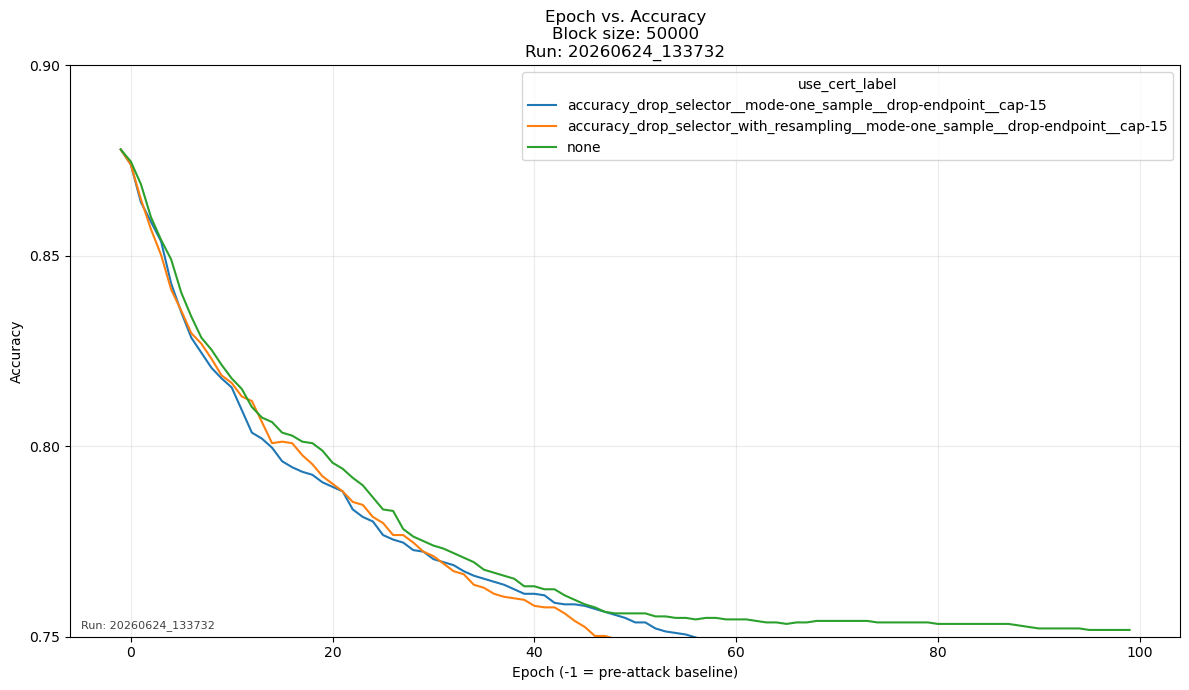


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\epochs.csv

----------------------------------------------------------------------------------------------------
Run: 20260624_145533
Block sizes: ['2000', '4000', '6000', '8000', '10000']
Output folder: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy_3d__run-20260624_145533.png


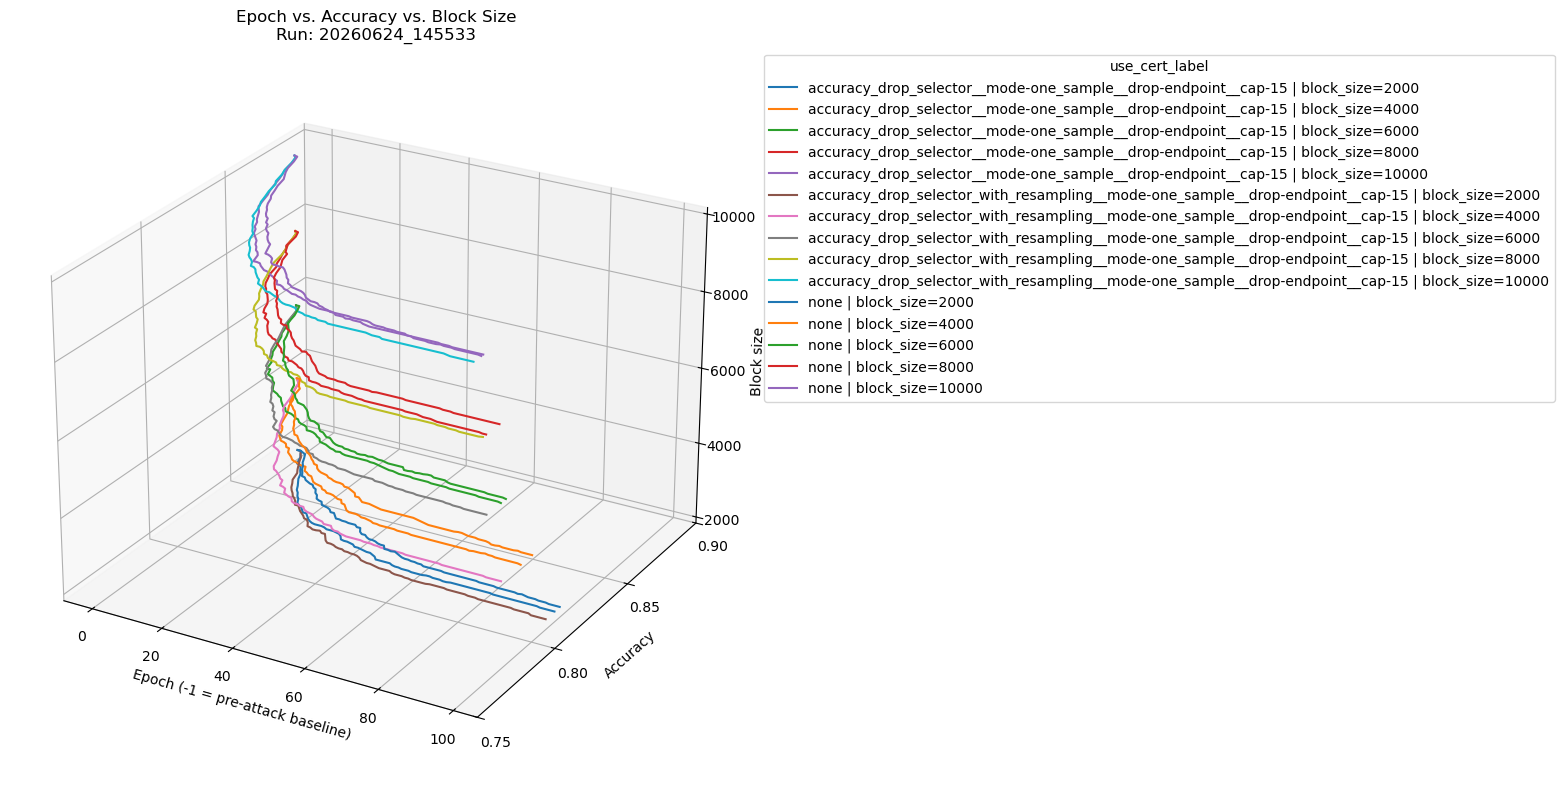

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy__run-20260624_145533__block_size-2000.png


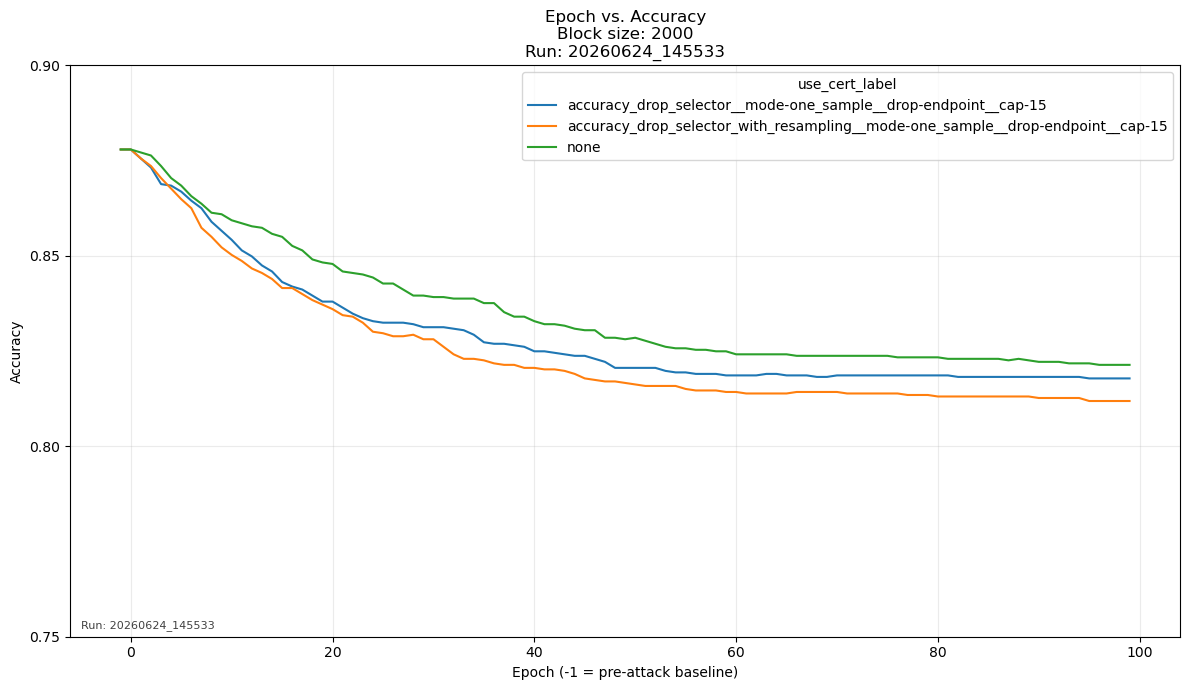

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy__run-20260624_145533__block_size-4000.png


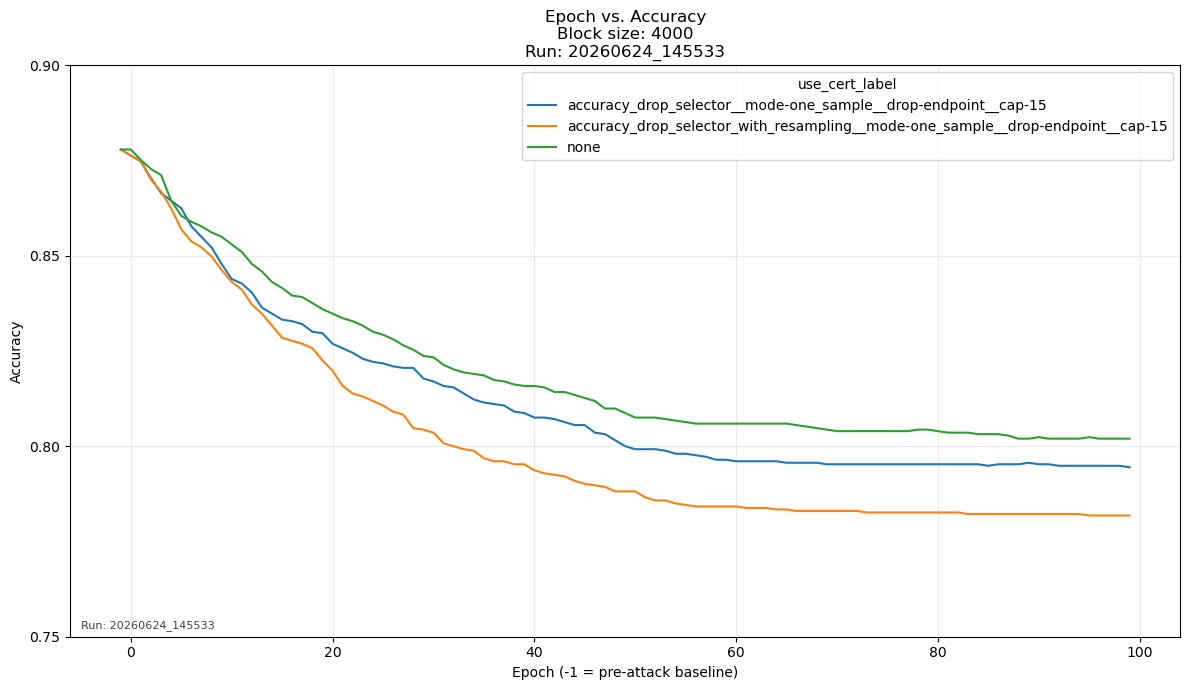

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy__run-20260624_145533__block_size-6000.png


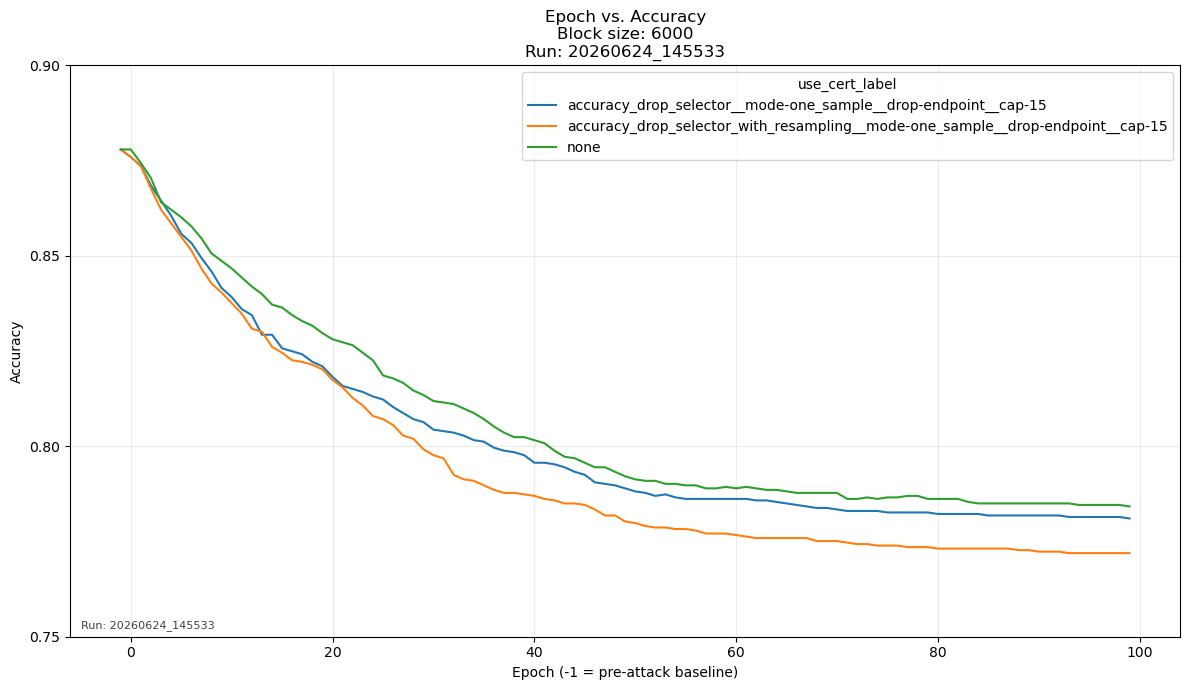

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy__run-20260624_145533__block_size-8000.png


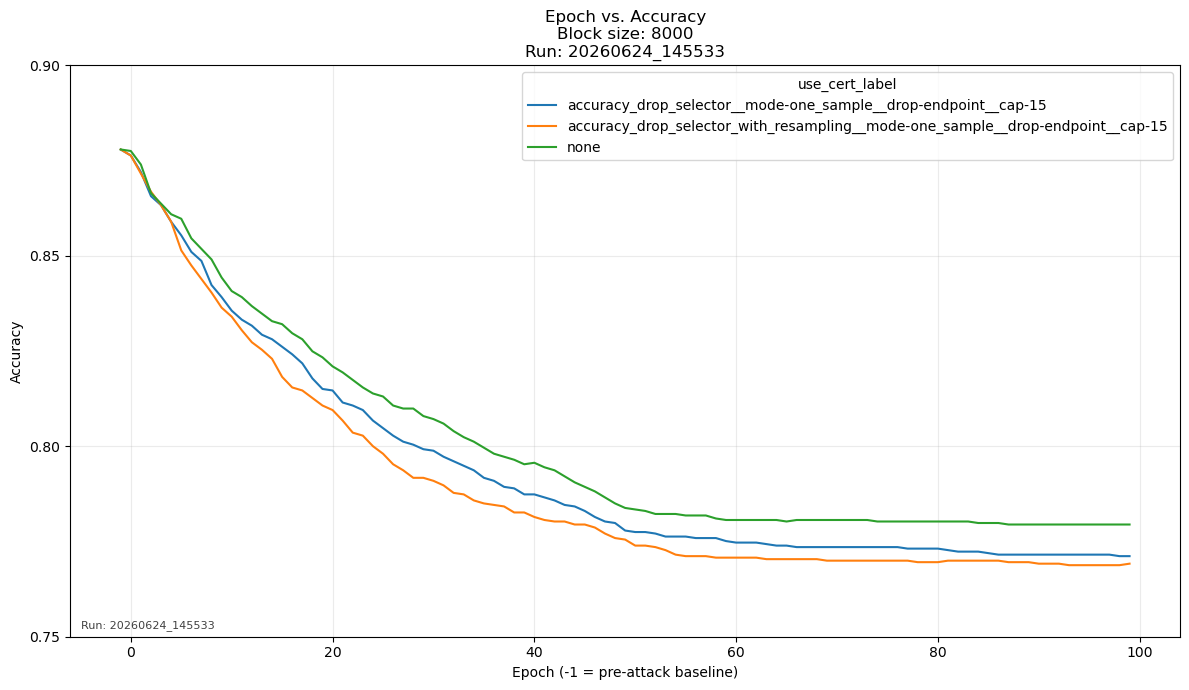

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\epoch_accuracy__run-20260624_145533__block_size-10000.png


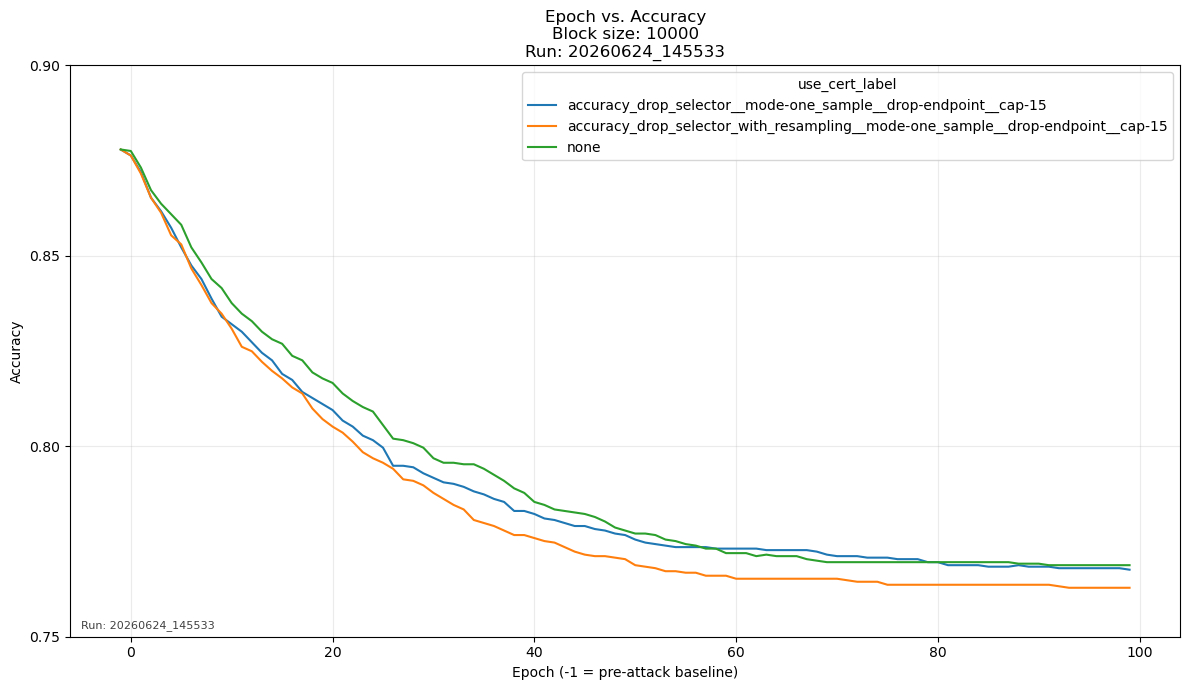

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\max_accuracy_differences__run-20260624_145533.csv
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\max_accuracy_difference_vs_none__run-20260624_145533__block_size-2000.png


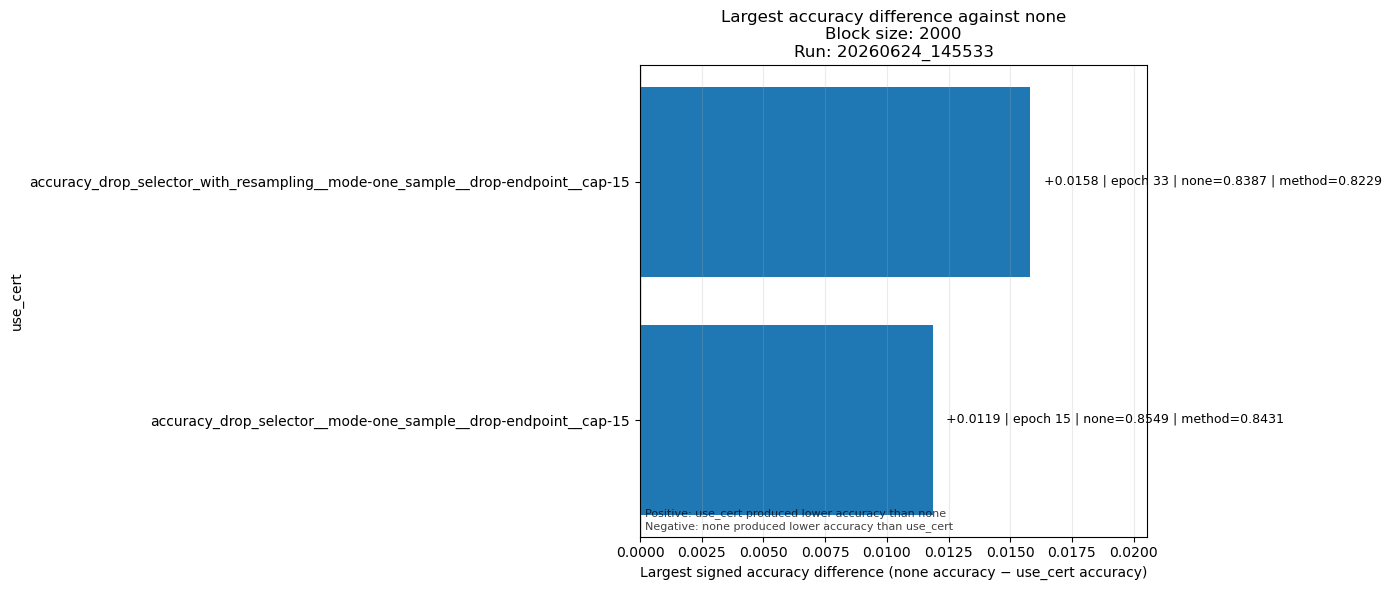

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\max_accuracy_difference_vs_none__run-20260624_145533__block_size-4000.png


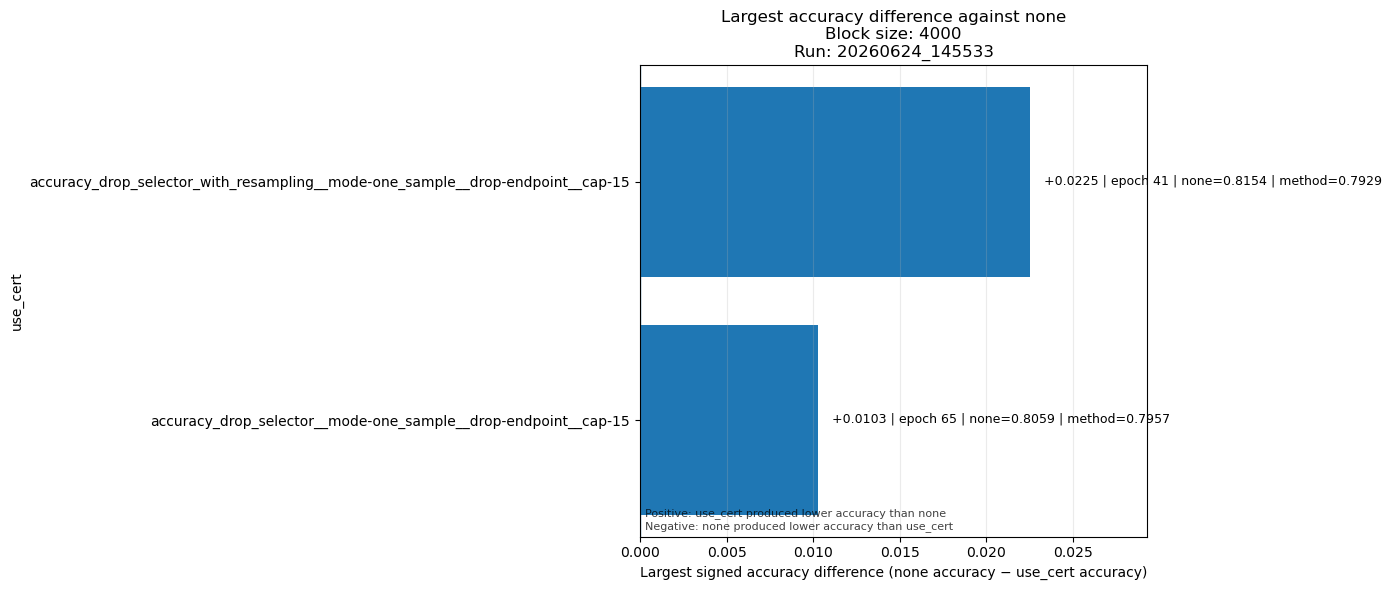

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\max_accuracy_difference_vs_none__run-20260624_145533__block_size-6000.png


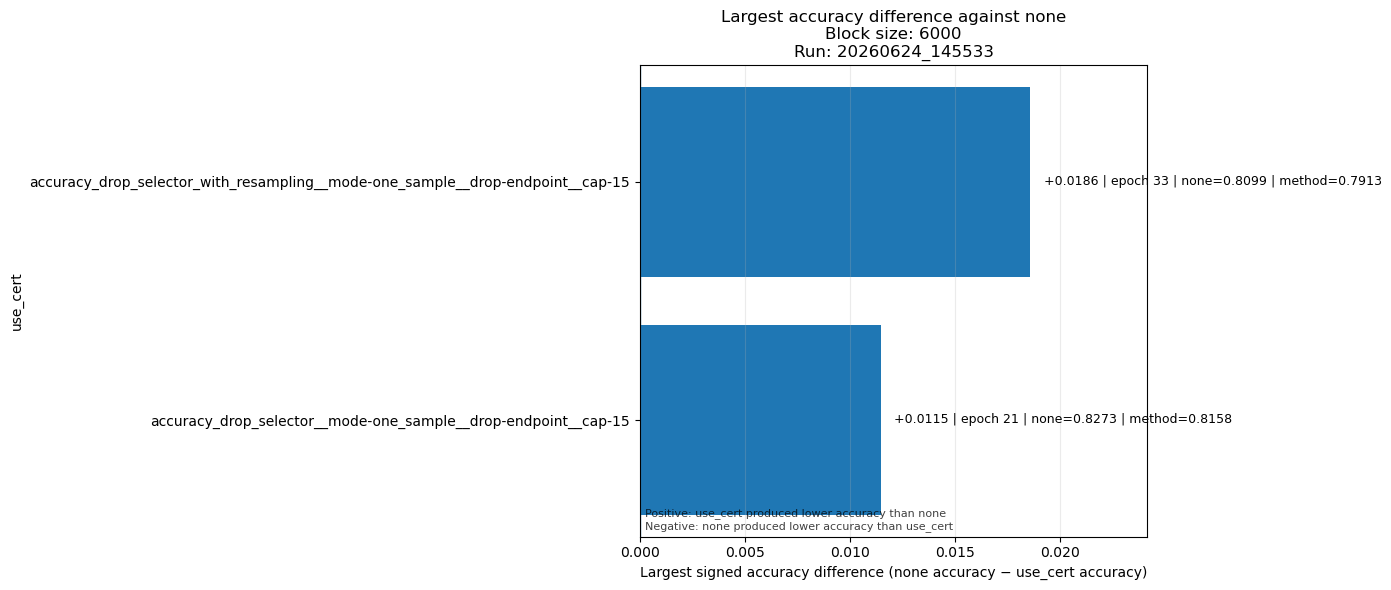

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\max_accuracy_difference_vs_none__run-20260624_145533__block_size-8000.png


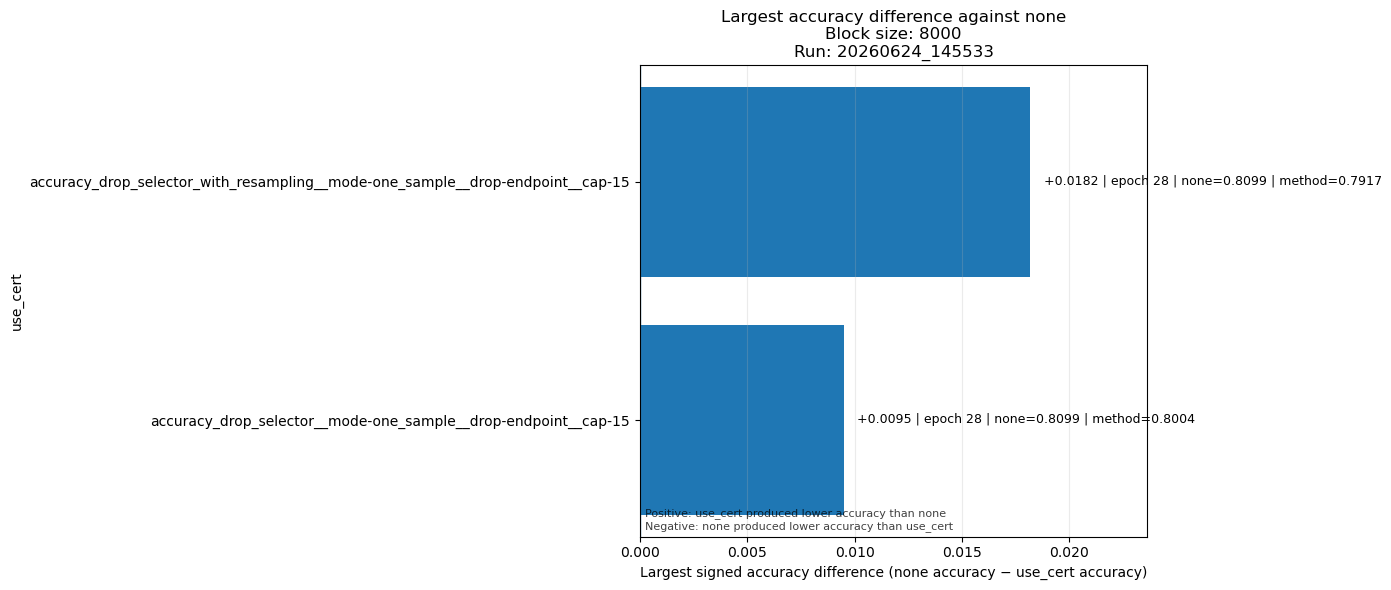

Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000+4000+6000+8000+10000__tau-0p8__epsilon-0p05__epochs-100__20260624_145533\plots__run-20260624_145533\max_accuracy_difference_vs_none__run-20260624_145533__block_size-10000.png


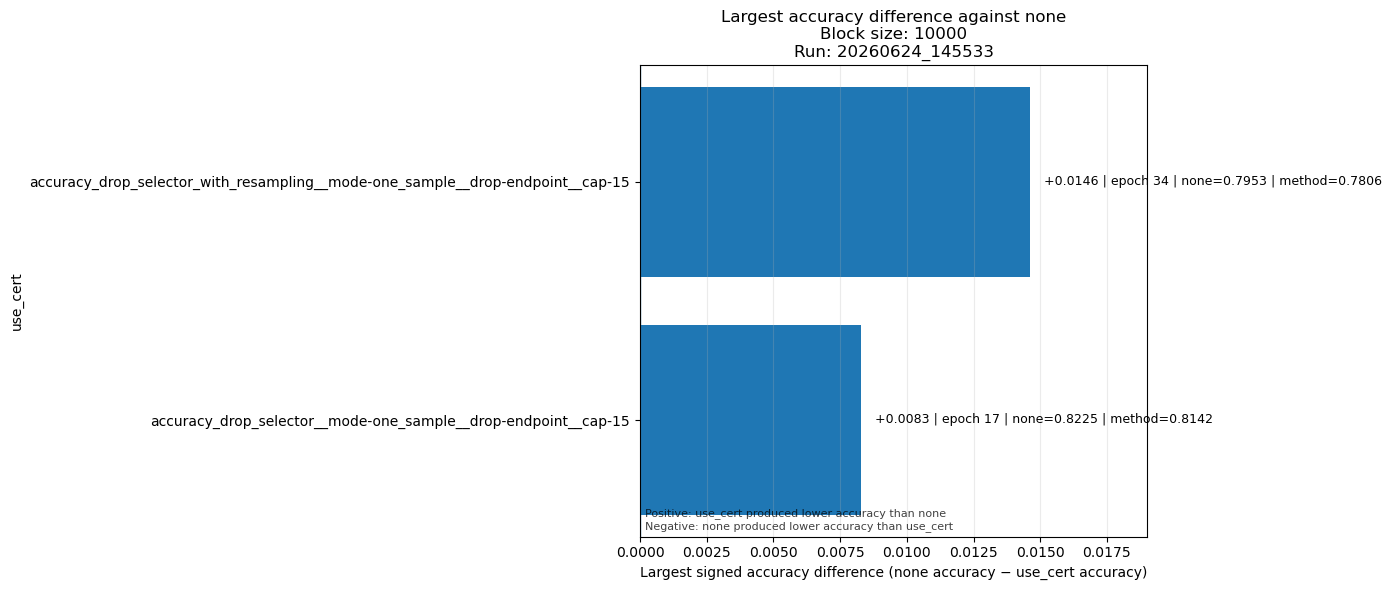


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-20000__tau-0p8__epsilon-0p05__epochs-100__20260624_142349\epochs.csv

----------------------------------------------------------------------------------------------------
Run: 20260624_142349
Block sizes: ['20000']
Output folder: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-20000__tau-0p8__epsilon-0p05__epochs-100__20260624_142349\plots__run-20260624_142349
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-20000__tau-0p8__epsilon-0p05__epochs-100__20260624_142349\plots__run-20260624_142349\epoch_accuracy__run-20260624_142349__block_size-20000.png


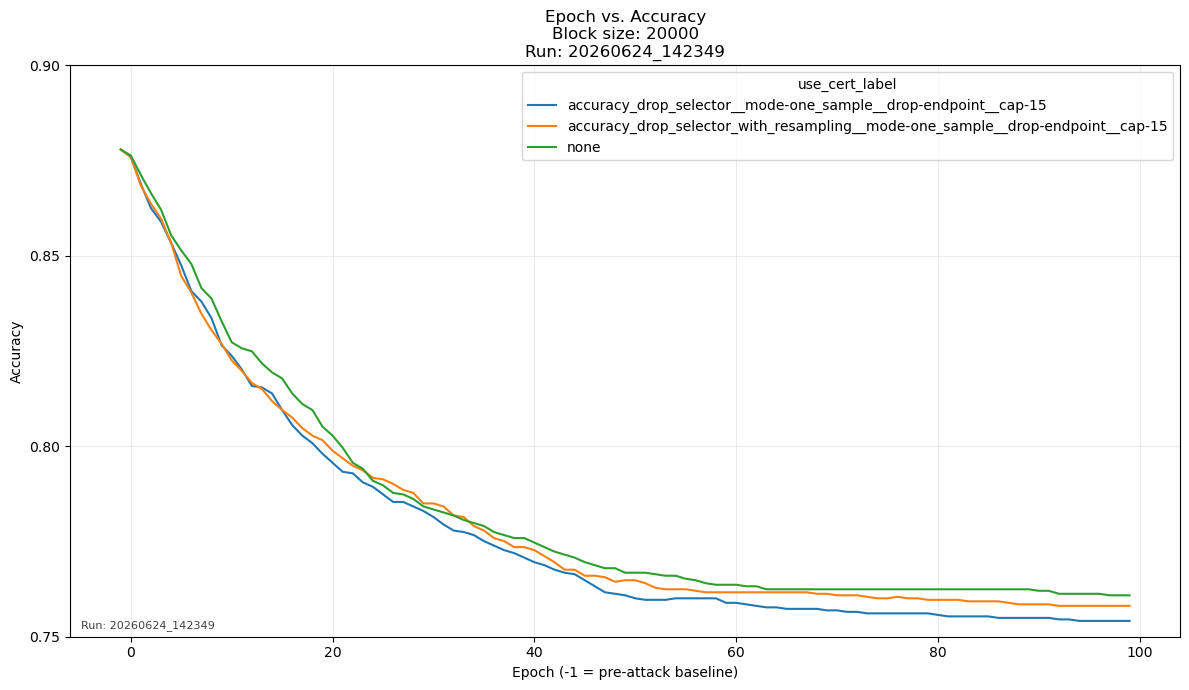


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000__tau-0p8__epsilon-0p05__epochs-100__20260624_144122\epochs.csv

----------------------------------------------------------------------------------------------------
Run: 20260624_144122
Block sizes: ['2000']
Output folder: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000__tau-0p8__epsilon-0p05__epochs-100__20260624_144122\plots__run-20260624_144122
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-2000__tau-0p8__epsilon-0p05__epochs-100__20260624_144122\plots__run-20260624_144122\epoch_accuracy__run-20260624_144122__block_size-2000.png


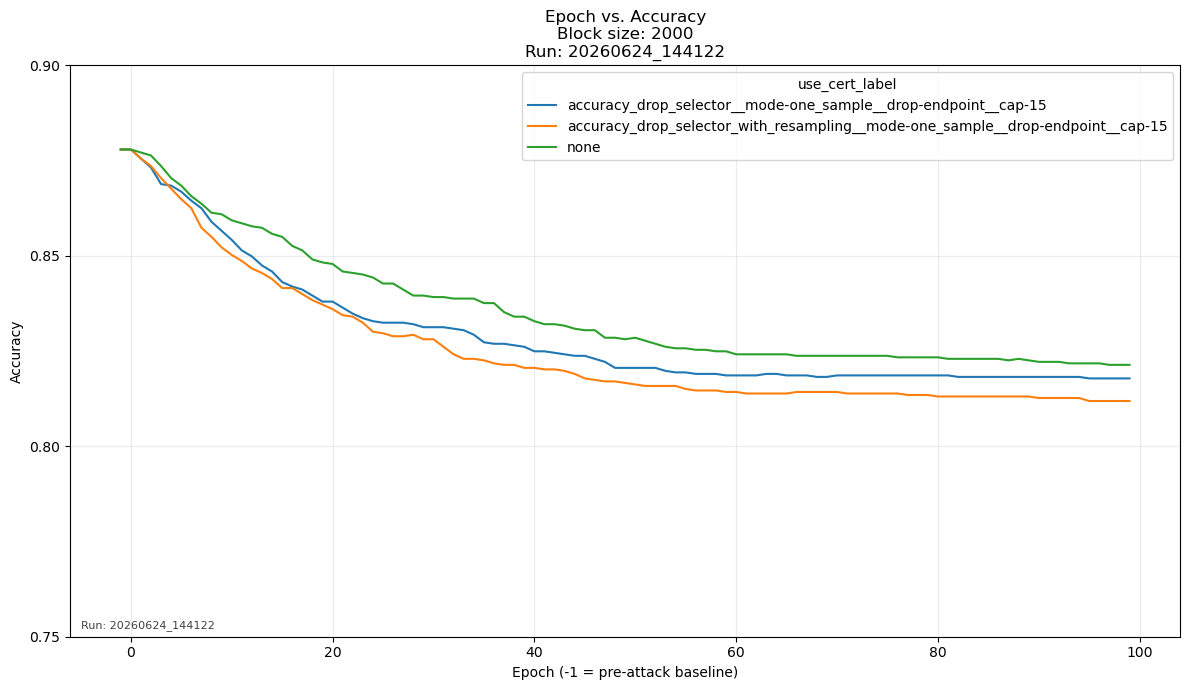


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-4000__tau-0p8__epsilon-0p05__epochs-100__20260628_133648\epochs.csv

----------------------------------------------------------------------------------------------------
Run: 20260628_133648
Block sizes: ['4000']
Output folder: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-4000__tau-0p8__epsilon-0p05__epochs-100__20260628_133648\plots__run-20260628_133648
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-4000__tau-0p8__epsilon-0p05__epochs-100__20260628_133648\plots__run-20260628_133648\epoch_accuracy__run-20260628_133648__block_size-4000.png


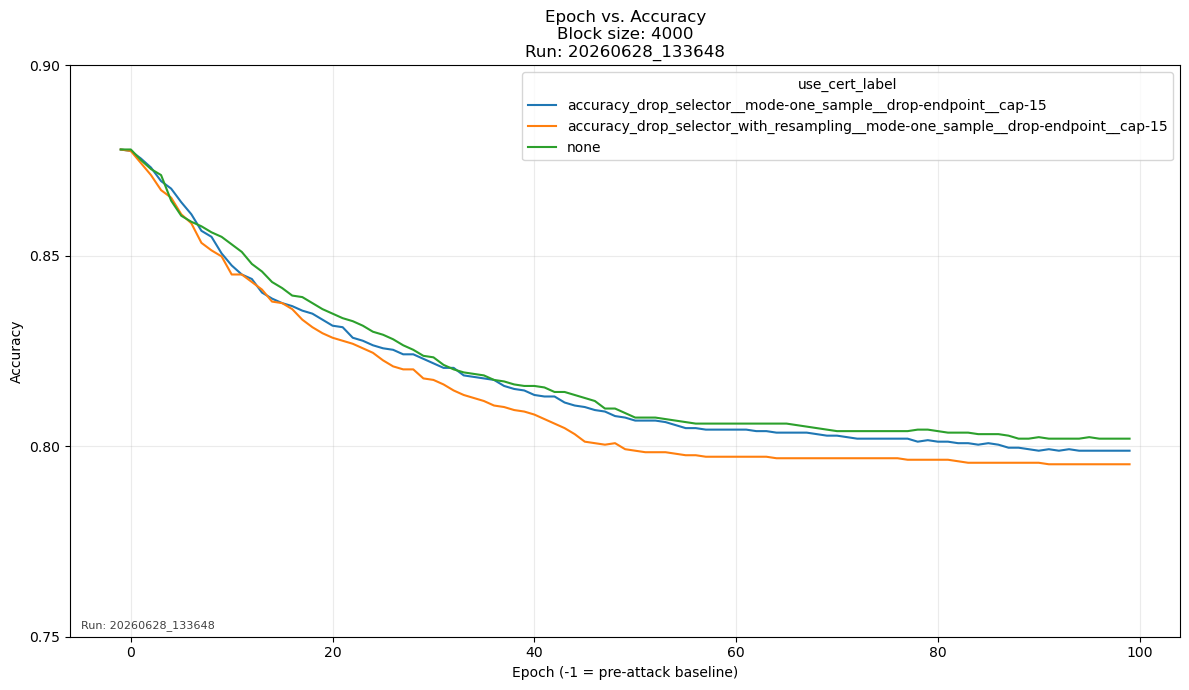


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-4000__tau-0p8__epsilon-0p05__epochs-100__20260629_020044\epochs.csv

----------------------------------------------------------------------------------------------------
Run: 20260629_020044
Block sizes: ['4000']
Output folder: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-4000__tau-0p8__epsilon-0p05__epochs-100__20260629_020044\plots__run-20260629_020044
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-4000__tau-0p8__epsilon-0p05__epochs-100__20260629_020044\plots__run-20260629_020044\epoch_accuracy__run-20260629_020044__block_size-4000.png


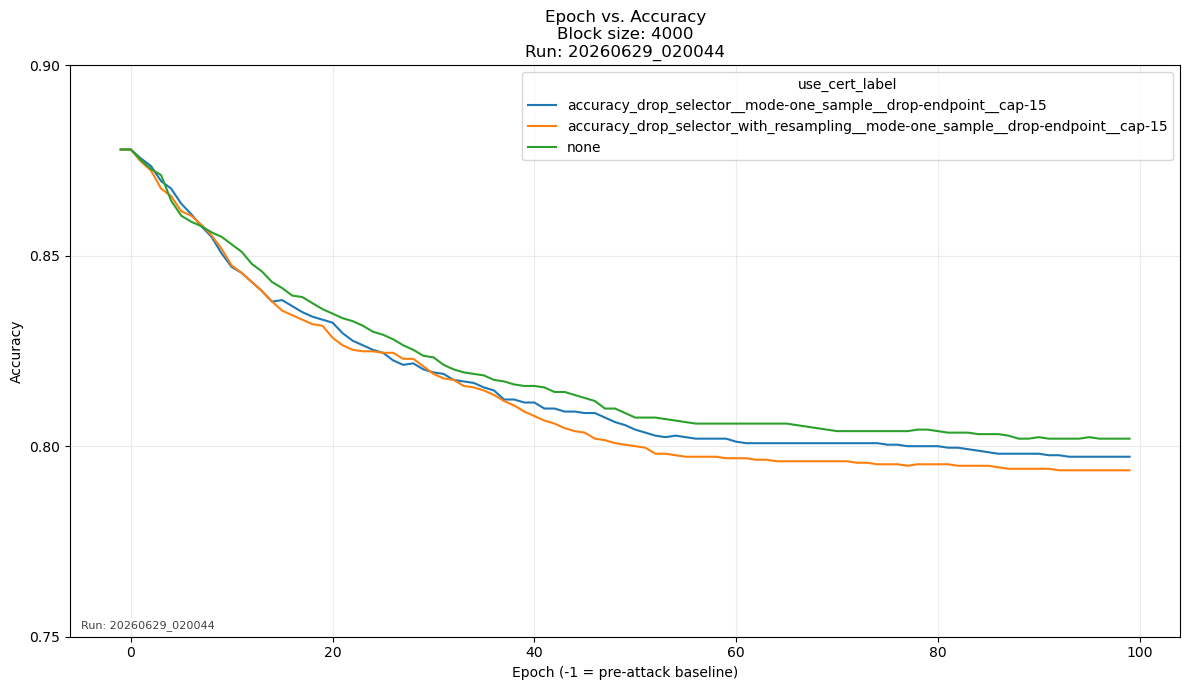


Processing: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-5000__tau-0p8__epsilon-0p05__epochs-100__20260624_143059\epochs.csv

----------------------------------------------------------------------------------------------------
Run: 20260624_143059
Block sizes: ['5000']
Output folder: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-5000__tau-0p8__epsilon-0p05__epochs-100__20260624_143059\plots__run-20260624_143059
Saved: extendedPlotting\sweeps\global_prbcd_cora_ml__block_size-5000__tau-0p8__epsilon-0p05__epochs-100__20260624_143059\plots__run-20260624_143059\epoch_accuracy__run-20260624_143059__block_size-5000.png


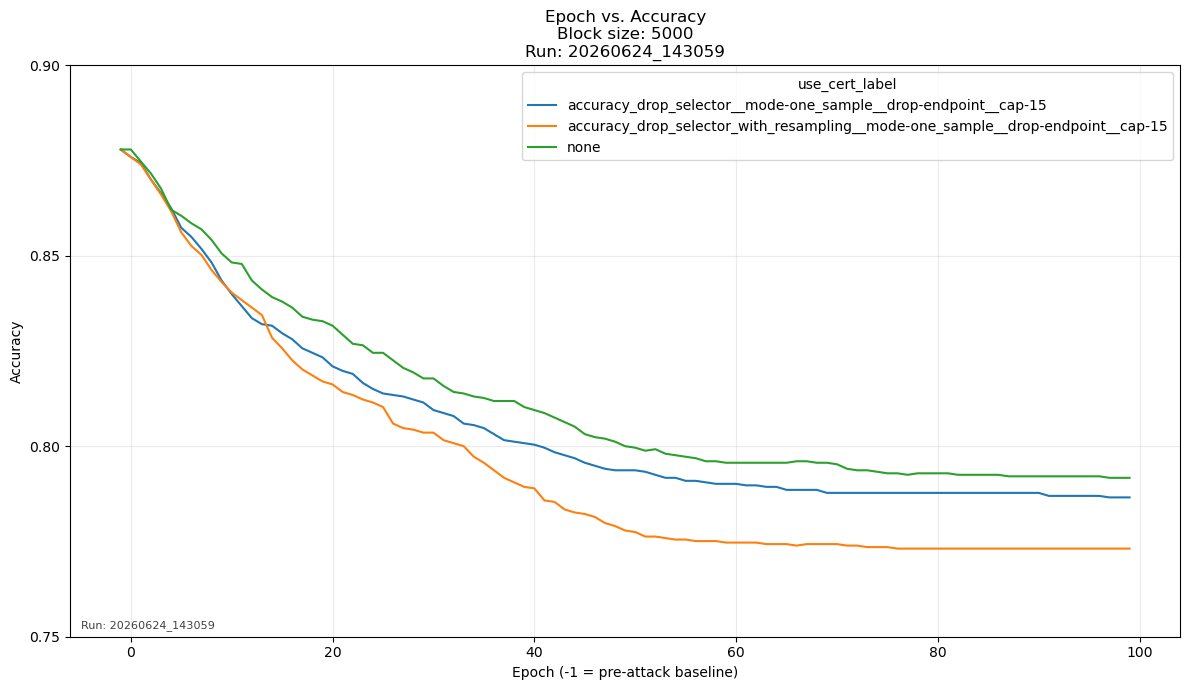


Finished processing all epoch CSV files.


In [28]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Configuration
# ============================================================

SWEEP_ROOT = Path("../extendedPlotting") / "sweeps"

# Epoch -1 represents the pre-attack baseline.
INCLUDE_BASELINE = True

SAVE_PLOTS = True
SHOW_PLOTS = True

# Fixed accuracy range for epoch-accuracy plots.
ACCURACY_Y_MIN = 0.75
ACCURACY_Y_MAX = 0.90

# Exclude selected methods from all plots.
EXCLUDED_METHODS = {
    "accuracy_drop_selector_k_hop",
}


# ============================================================
# Possible column names
# ============================================================

EPOCH_CANDIDATES = [
    "epoch_idx",
    "epoch",
    "Epoch",
    "step",
]

ACCURACY_CANDIDATES = [
    "accuracy",
    "acc",
    "Accuracy",
]

METHOD_CANDIDATES = [
    "use_cert_label",
    "attack__use_cert",
    "use_cert",
]

BLOCK_SIZE_CANDIDATES = [
    "block_size",
    "attack__block_size",
    "attack_params__block_size",
    "attack_params.block_size",
]

RUN_GROUP_CANDIDATES = [
    "run_group_id",
    "sweep_id",
    "experiment_id",
]


# ============================================================
# Helper functions
# ============================================================

def find_first_existing_column(dataframe, candidates):
    return next(
        (
            column
            for column in candidates
            if column in dataframe.columns
        ),
        None,
    )


def find_block_size_column(dataframe):
    """
    Find the block-size column using known names or a normalized
    column name ending in 'block_size'.
    """
    column = find_first_existing_column(
        dataframe,
        BLOCK_SIZE_CANDIDATES,
    )

    if column is not None:
        return column

    return next(
        (
            column
            for column in dataframe.columns
            if (
                column.lower()
                .replace(".", "_")
                .replace("-", "_")
                .endswith("block_size")
            )
        ),
        None,
    )


def safe_filename(value):
    """
    Convert a run identifier into a filesystem-safe string.
    """
    value = str(value).strip()

    value = re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        value,
    )

    return value.strip("._-") or "unknown_run"


def format_block_size(block_size):
    """
    Format block sizes without unnecessary decimal places.
    """
    value = float(block_size)

    if value.is_integer():
        return str(int(value))

    return str(value).replace(".", "p")


def normalize_method_name(value):
    return str(value).strip()


def is_excluded_method(method):
    return normalize_method_name(method) in EXCLUDED_METHODS


def add_run_label(axis, run_identifier):
    """
    Add a visible run identifier inside a 2D plot.
    """
    axis.text(
        0.01,
        0.01,
        f"Run: {run_identifier}",
        transform=axis.transAxes,
        fontsize=8,
        alpha=0.75,
        horizontalalignment="left",
        verticalalignment="bottom",
    )


def save_or_show_figure(figure, plot_path):
    figure.tight_layout()

    if SAVE_PLOTS:
        figure.savefig(
            plot_path,
            dpi=200,
            bbox_inches="tight",
        )

        print("Saved:", plot_path)

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(figure)


def calculate_max_accuracy_differences(
    run_df,
    epoch_col,
    accuracy_col,
    method_col,
    block_size_col,
):
    """
    For every block size and every non-'none' method:

    1. Average duplicate rows for each epoch and method.
    2. Align the method with 'none' by epoch.
    3. Calculate:

           signed_difference = none_accuracy - method_accuracy

    4. Select the epoch with the largest absolute difference.

    Interpretation:
        positive -> use_cert achieved lower accuracy than none
        negative -> none achieved lower accuracy than use_cert
    """
    rows = []

    if method_col is None:
        return pd.DataFrame()

    for block_size, block_df in run_df.groupby(
        block_size_col,
        dropna=False,
    ):
        if pd.isna(block_size):
            continue

        averaged = (
            block_df
            .groupby(
                [epoch_col, method_col],
                dropna=False,
            )[accuracy_col]
            .mean()
            .reset_index()
        )

        pivot = averaged.pivot(
            index=epoch_col,
            columns=method_col,
            values=accuracy_col,
        )

        none_column = next(
            (
                column
                for column in pivot.columns
                if str(column).strip().lower() == "none"
            ),
            None,
        )

        if none_column is None:
            print(
                f"Skipping difference analysis for "
                f"block_size={format_block_size(block_size)}: "
                "no 'none' method found."
            )
            continue

        for method in pivot.columns:
            method_label = normalize_method_name(method)

            if method == none_column:
                continue

            if is_excluded_method(method_label):
                continue

            comparison = pivot[
                [none_column, method]
            ].dropna()

            if comparison.empty:
                continue

            signed_difference = (
                comparison[none_column]
                - comparison[method]
            )

            max_epoch = signed_difference.abs().idxmax()

            none_accuracy = float(
                comparison.loc[max_epoch, none_column]
            )

            method_accuracy = float(
                comparison.loc[max_epoch, method]
            )

            max_signed_difference = float(
                signed_difference.loc[max_epoch]
            )

            rows.append({
                "block_size": float(block_size),
                "use_cert": method_label,
                "epoch": int(max_epoch),
                "none_accuracy": none_accuracy,
                "use_cert_accuracy": method_accuracy,
                "signed_difference": max_signed_difference,
                "absolute_difference": abs(max_signed_difference),
                "better_method": (
                    method_label
                    if max_signed_difference > 0
                    else "none"
                    if max_signed_difference < 0
                    else "equal"
                ),
            })

    return pd.DataFrame(rows)


# ============================================================
# Find all epochs.csv files recursively
# ============================================================

csv_files = sorted(
    SWEEP_ROOT.rglob("epochs.csv")
)

if not csv_files:
    raise FileNotFoundError(
        f"No epochs.csv files found below: "
        f"{SWEEP_ROOT.resolve()}"
    )

print(f"Found {len(csv_files)} epoch CSV file(s).")

for path in csv_files:
    print(" -", path)


# ============================================================
# Process every epochs.csv
# ============================================================

for csv_path in csv_files:
    print()
    print("=" * 100)
    print("Processing:", csv_path)

    df = pd.read_csv(csv_path)

    if df.empty:
        print("Skipping empty file.")
        continue

    epoch_col = find_first_existing_column(
        df,
        EPOCH_CANDIDATES,
    )

    accuracy_col = find_first_existing_column(
        df,
        ACCURACY_CANDIDATES,
    )

    method_col = find_first_existing_column(
        df,
        METHOD_CANDIDATES,
    )

    block_size_col = find_block_size_column(df)

    run_group_col = find_first_existing_column(
        df,
        RUN_GROUP_CANDIDATES,
    )

    if epoch_col is None:
        print("Skipping: no compatible epoch column found.")
        continue

    if accuracy_col is None:
        print("Skipping: no compatible accuracy column found.")
        continue

    if block_size_col is None:
        print("Skipping: no compatible block-size column found.")
        continue

    # --------------------------------------------------------
    # Convert relevant columns to numeric
    # --------------------------------------------------------

    df[epoch_col] = pd.to_numeric(
        df[epoch_col],
        errors="coerce",
    )

    df[accuracy_col] = pd.to_numeric(
        df[accuracy_col],
        errors="coerce",
    )

    df[block_size_col] = pd.to_numeric(
        df[block_size_col],
        errors="coerce",
    )

    df = df.dropna(
        subset=[
            epoch_col,
            accuracy_col,
            block_size_col,
        ]
    ).copy()

    if not INCLUDE_BASELINE:
        df = df[df[epoch_col] >= 0]

    if df.empty:
        print("Skipping: no valid rows remained.")
        continue

    df[epoch_col] = df[epoch_col].astype(int)

    # --------------------------------------------------------
    # Split CSV into run groups
    # --------------------------------------------------------

    if run_group_col is not None:
        run_groups = df.groupby(
            run_group_col,
            dropna=False,
        )
    else:
        run_groups = [
            (
                csv_path.parent.name,
                df,
            )
        ]

    # ========================================================
    # Process every run group separately
    # ========================================================

    for run_group_value, run_df in run_groups:
        if pd.isna(run_group_value):
            run_identifier = csv_path.parent.name
        else:
            run_identifier = str(run_group_value)

        safe_run_identifier = safe_filename(
            run_identifier
        )

        block_sizes = sorted(
            run_df[block_size_col]
            .dropna()
            .unique()
            .tolist()
        )

        plot_output_dir = (
            csv_path.parent
            / f"plots__run-{safe_run_identifier}"
        )

        if SAVE_PLOTS:
            plot_output_dir.mkdir(
                parents=True,
                exist_ok=True,
            )

        print()
        print("-" * 100)
        print("Run:", run_identifier)
        print(
            "Block sizes:",
            [
                format_block_size(value)
                for value in block_sizes
            ],
        )
        print("Output folder:", plot_output_dir)

        # ====================================================
        # 1. 3D plot when the run has multiple block sizes
        # ====================================================

        if len(block_sizes) > 1:
            figure = plt.figure(
                figsize=(14, 8)
            )

            axis = figure.add_subplot(
                111,
                projection="3d",
            )

            plotted_lines = 0

            if method_col is not None:
                grouped_series = run_df.groupby(
                    [
                        method_col,
                        block_size_col,
                    ],
                    dropna=False,
                )
            else:
                grouped_series = run_df.groupby(
                    block_size_col,
                    dropna=False,
                )

            for group_key, group in grouped_series:
                if method_col is not None:
                    method, block_size = group_key
                    method_label = normalize_method_name(method)
                else:
                    block_size = group_key
                    method_label = "accuracy"

                if is_excluded_method(method_label):
                    continue

                if pd.isna(block_size):
                    continue

                series = (
                    group
                    .groupby(epoch_col)[accuracy_col]
                    .mean()
                    .sort_index()
                )

                if series.empty:
                    continue

                epoch_values = series.index.to_numpy()
                accuracy_values = series.to_numpy()

                block_size_values = [
                    float(block_size)
                ] * len(series)

                axis.plot(
                    epoch_values,
                    accuracy_values,
                    block_size_values,
                    label=(
                        f"{method_label} | "
                        f"block_size="
                        f"{format_block_size(block_size)}"
                    ),
                )

                plotted_lines += 1

            if plotted_lines > 0:
                axis.set_xlabel(
                    "Epoch (-1 = pre-attack baseline)"
                    if INCLUDE_BASELINE
                    else "Epoch"
                )

                axis.set_ylabel("Accuracy")
                axis.set_zlabel("Block size")

                axis.set_title(
                    "Epoch vs. Accuracy vs. Block Size\n"
                    f"Run: {run_identifier}"
                )

                axis.set_ylim(
                    ACCURACY_Y_MIN,
                    ACCURACY_Y_MAX,
                )

                axis.set_yticks([
                    0.75,
                    0.80,
                    0.85,
                    0.90,
                ])

                axis.set_zticks(block_sizes)

                axis.view_init(
                    elev=25,
                    azim=-60,
                )

                axis.grid(
                    visible=True,
                    alpha=0.25,
                )

                axis.legend(
                    title=method_col or "series",
                    loc="upper left",
                    bbox_to_anchor=(1.02, 1.0),
                )

                plot_path = (
                    plot_output_dir
                    / (
                        "epoch_accuracy_3d"
                        f"__run-{safe_run_identifier}.png"
                    )
                )

                save_or_show_figure(
                    figure,
                    plot_path,
                )

            else:
                plt.close(figure)

                print(
                    "No valid series remained for the 3D plot."
                )

        # ====================================================
        # 2. Separate epoch-accuracy plot for each block size
        # ====================================================

        for block_size in block_sizes:
            block_df = run_df[
                run_df[block_size_col] == block_size
            ].copy()

            if block_df.empty:
                continue

            figure, axis = plt.subplots(
                figsize=(12, 7)
            )

            plotted_lines = 0

            if method_col is not None:
                method_groups = block_df.groupby(
                    method_col,
                    dropna=False,
                )

                for method, method_df in method_groups:
                    method_label = normalize_method_name(method)

                    if is_excluded_method(method_label):
                        continue

                    series = (
                        method_df
                        .groupby(epoch_col)[accuracy_col]
                        .mean()
                        .sort_index()
                    )

                    if series.empty:
                        continue

                    axis.plot(
                        series.index.to_numpy(),
                        series.to_numpy(),
                        label=method_label,
                    )

                    plotted_lines += 1

                if plotted_lines > 0:
                    axis.legend(
                        title=method_col,
                        loc="best",
                    )

            else:
                series = (
                    block_df
                    .groupby(epoch_col)[accuracy_col]
                    .mean()
                    .sort_index()
                )

                if not series.empty:
                    axis.plot(
                        series.index.to_numpy(),
                        series.to_numpy(),
                    )

                    plotted_lines += 1

            if plotted_lines == 0:
                plt.close(figure)

                print(
                    f"Skipping block_size="
                    f"{format_block_size(block_size)}: "
                    "no valid series."
                )
                continue

            block_size_label = format_block_size(
                block_size
            )

            axis.set_xlabel(
                "Epoch (-1 = pre-attack baseline)"
                if INCLUDE_BASELINE
                else "Epoch"
            )

            axis.set_ylabel("Accuracy")

            axis.set_title(
                "Epoch vs. Accuracy\n"
                f"Block size: {block_size_label}\n"
                f"Run: {run_identifier}"
            )

            axis.set_ylim(
                ACCURACY_Y_MIN,
                ACCURACY_Y_MAX,
            )

            axis.set_yticks([
                0.75,
                0.80,
                0.85,
                0.90,
            ])

            axis.grid(
                visible=True,
                alpha=0.25,
            )

            add_run_label(
                axis,
                run_identifier,
            )

            plot_path = (
                plot_output_dir
                / (
                    "epoch_accuracy"
                    f"__run-{safe_run_identifier}"
                    f"__block_size-{block_size_label}.png"
                )
            )

            save_or_show_figure(
                figure,
                plot_path,
            )

        # ====================================================
        # 3. Maximum difference against "none"
        #    Only for runs with multiple block sizes
        # ====================================================

        if len(block_sizes) > 1 and method_col is not None:
            max_difference_df = (
                calculate_max_accuracy_differences(
                    run_df=run_df,
                    epoch_col=epoch_col,
                    accuracy_col=accuracy_col,
                    method_col=method_col,
                    block_size_col=block_size_col,
                )
            )

            if max_difference_df.empty:
                print(
                    "No valid none-vs-use_cert comparisons "
                    f"found for run {run_identifier}."
                )

            else:
                # Save all numerical difference results.
                difference_csv_path = (
                    plot_output_dir
                    / (
                        "max_accuracy_differences"
                        f"__run-{safe_run_identifier}.csv"
                    )
                )

                if SAVE_PLOTS:
                    max_difference_df.to_csv(
                        difference_csv_path,
                        index=False,
                    )

                    print(
                        "Saved:",
                        difference_csv_path,
                    )

                # --------------------------------------------
                # One difference plot for each block size
                # --------------------------------------------

                for block_size in sorted(
                    max_difference_df[
                        "block_size"
                    ].unique()
                ):
                    block_result = (
                        max_difference_df[
                            max_difference_df["block_size"]
                            == block_size
                        ]
                        .sort_values(
                            "absolute_difference",
                            ascending=True,
                        )
                        .copy()
                    )

                    if block_result.empty:
                        continue

                    figure_height = max(
                        6,
                        0.65 * len(block_result) + 3,
                    )

                    figure, axis = plt.subplots(
                        figsize=(13, figure_height)
                    )

                    methods = (
                        block_result["use_cert"]
                        .astype(str)
                        .tolist()
                    )

                    signed_differences = (
                        block_result[
                            "signed_difference"
                        ]
                        .to_numpy()
                    )

                    bars = axis.barh(
                        methods,
                        signed_differences,
                    )

                    axis.axvline(
                        0,
                        linewidth=1,
                        alpha=0.75,
                    )

                    largest_absolute_difference = max(
                        float(
                            block_result[
                                "absolute_difference"
                            ].max()
                        ),
                        0.001,
                    )

                    annotation_offset = (
                        largest_absolute_difference * 0.035
                    )

                    for bar, row in zip(
                        bars,
                        block_result.itertuples(
                            index=False
                        ),
                    ):
                        width = float(bar.get_width())

                        if width >= 0:
                            annotation_x = (
                                width + annotation_offset
                            )
                            horizontal_alignment = "left"
                        else:
                            annotation_x = (
                                width - annotation_offset
                            )
                            horizontal_alignment = "right"

                        axis.text(
                            annotation_x,
                            (
                                bar.get_y()
                                + bar.get_height() / 2
                            ),
                            (
                                f"{width:+.4f} | "
                                f"epoch {row.epoch} | "
                                f"none={row.none_accuracy:.4f} | "
                                f"method={row.use_cert_accuracy:.4f}"
                            ),
                            horizontalalignment=(
                                horizontal_alignment
                            ),
                            verticalalignment="center",
                            fontsize=9,
                        )

                    block_size_label = format_block_size(
                        block_size
                    )

                    axis.set_xlabel(
                        "Largest signed accuracy difference "
                        "(none accuracy − use_cert accuracy)"
                    )

                    axis.set_ylabel("use_cert")

                    axis.set_title(
                        "Largest accuracy difference against none\n"
                        f"Block size: {block_size_label}\n"
                        f"Run: {run_identifier}"
                    )

                    axis.grid(
                        visible=True,
                        axis="x",
                        alpha=0.25,
                    )

                    axis.margins(
                        x=0.30,
                    )

                    axis.text(
                        0.01,
                        0.01,
                        (
                            "Positive: use_cert produced lower accuracy "
                            "than none\n"
                            "Negative: none produced lower accuracy "
                            "than use_cert"
                        ),
                        transform=axis.transAxes,
                        fontsize=8,
                        alpha=0.75,
                        horizontalalignment="left",
                        verticalalignment="bottom",
                    )

                    plot_path = (
                        plot_output_dir
                        / (
                            "max_accuracy_difference_vs_none"
                            f"__run-{safe_run_identifier}"
                            f"__block_size-{block_size_label}.png"
                        )
                    )

                    save_or_show_figure(
                        figure,
                        plot_path,
                    )

print()
print("=" * 100)
print("Finished processing all epoch CSV files.")

---
## §9  RQ1 — When Does PR-BCD Miss Harmful Edges?

This experiment constructs an **empirical high-budget PR-BCD reference** and compares ordinary PR-BCD runs across candidate block sizes.

The cell temporarily instruments PR-BCD at runtime and records:

- the initial candidate block;
- candidate blocks at every epoch;
- blocks immediately before and after resampling;
- accumulated positive gradients;
- maximum relaxed perturbation weights;
- final discrete perturbations;
- victim accuracy and runtime.

The optimization itself is unchanged. Reference and evaluation runs use separate PR-BCD sampling seeds so that small evaluation blocks are not trivial prefixes of the high-budget reference block.


In [ ]:
# ============================================================
# SIMPLE RQ1: Which full-space PRBCD reference edges are missed by small blocks?
#
# This cell does not modify the normal single-PRBCD workflow above.
# RQ1 recording is enabled only inside _run_rq1_prbcd().
# ============================================================

from datetime import datetime
from pathlib import Path
from timeit import default_timer as timer
import gc
import os

import numpy as np
import pandas as pd
import torch
from IPython.display import display

from experiments import experiment_global_attack_direct
from rgnn_at_scale.attacks.prbcd import PRBCD
from sparse_smoothing.utils import load_and_standardize


# ------------------------------------------------------------
# PRBCD sanity check
# ------------------------------------------------------------
# The RQ1 experiment relies on the patched PRBCD class. In particular,
# PRBCD must expose the RQ1 constructor flags and store per-epoch metrics
# in attack_statistics via _append_attack_statistics().
import inspect

_required_prbcd_init_args = {
    "rq1_enabled",
    "rq1_is_reference",
    "rq1_sampling_seed",
}

_prbcd_init_args = set(inspect.signature(PRBCD.__init__).parameters)
_missing_prbcd_init_args = _required_prbcd_init_args - _prbcd_init_args

_required_prbcd_methods = [
    "sample_full_search_space",
    "_append_attack_statistics",
]

_missing_prbcd_methods = [
    name for name in _required_prbcd_methods
    if not hasattr(PRBCD, name)
]

if _missing_prbcd_init_args or _missing_prbcd_methods:
    raise RuntimeError(
        "The loaded PRBCD class is not the RQ1-patched version. "
        f"Missing init args: {sorted(_missing_prbcd_init_args)}; "
        f"missing methods: {_missing_prbcd_methods}. "
        "Make sure rgnn_at_scale.attacks.prbcd points to your patched prbcd.py."
    )


# -------------------------
# Configuration
# -------------------------
RQ1_EPSILON = 0.05

# Full-space reference. With the patched PRBCD implementation,
# rq1_is_reference=True initializes current_search_space with
# torch.arange(n_possible_edges) and skips resampling.
RQ1_N_POSSIBLE_EDGES = int(n_nodes * (n_nodes - 1) // 2)
RQ1_REFERENCE_BLOCK_SIZE = RQ1_N_POSSIBLE_EDGES
RQ1_REFERENCE_TYPE = "full_space_fixed_no_resampling"

RQ1_SMALL_BLOCK_SIZES = [1_000, 2_000, 4_000, 8_000, 16_000]
RQ1_SMALL_REPEATS = 3
RQ1_REFERENCE_REPEATS = 1
RQ1_EPOCHS = 100
RQ1_FINE_TUNE_EPOCHS = 50

# The reference run is full-space and therefore memory-heavy.
# False avoids repeated CPU copies of the full edge space.
# Set to True if you explicitly want best-accuracy epoch restoration.
RQ1_REFERENCE_WITH_EARLY_STOPPING = False
RQ1_SMALL_WITH_EARLY_STOPPING = True

RQ1_MODEL_STORAGE_TYPE = "demo_custom_split"
RQ1_ARTIFACT_DIR = "cache"
RQ1_PERT_ADJ_STORAGE_TYPE = "evasion_global_adj"
RQ1_PERT_ATTR_STORAGE_TYPE = "evasion_global_attr"

RQ1_ATTACK_BUDGET = max(1, round(RQ1_EPSILON * n_undirected))

if RQ1_ATTACK_BUDGET >= RQ1_N_POSSIBLE_EDGES:
    raise ValueError(
        f"attack budget={RQ1_ATTACK_BUDGET} must be smaller than "
        f"n_possible_edges={RQ1_N_POSSIBLE_EDGES}."
    )

for block_size in RQ1_SMALL_BLOCK_SIZES:
    if block_size <= RQ1_ATTACK_BUDGET:
        raise ValueError(
            f"small block_size={block_size} must exceed attack budget="
            f"{RQ1_ATTACK_BUDGET}."
        )

if "graph_sparse" not in globals():
    graph_sparse = load_and_standardize(
        os.path.join("data", f"{DATASET}.npz")
    )

RQ1_RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
RQ1_OUT_DIR = (
    Path("../extendedPlotting")
    / "rq1_full_space_vs_small"
    / f"{DATASET}__{RQ1_RUN_ID}"
)
RQ1_OUT_DIR.mkdir(parents=True, exist_ok=True)


# -------------------------
# Small helpers
# -------------------------
def _as_long_tensor(value):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().long().flatten()
    return torch.as_tensor(value, dtype=torch.long).flatten()


def _extract_rq1(result):
    attack_stats = result.get("attack_statistics")
    if not isinstance(attack_stats, dict):
        raise RuntimeError("Result contains no attack_statistics dictionary.")

    rq1 = attack_stats.get("rq1")
    if not isinstance(rq1, dict):
        raise RuntimeError("attack_statistics['rq1'] is missing or invalid.")

    return rq1


def _extract_final_accuracy(result):
    rows = result.get("results", [])
    if rows and isinstance(rows[0], dict):
        return float(rows[0]["accuracy"])
    return np.nan


def _as_float(value):
    """Convert tensors / numpy scalars / Python numbers to plain floats."""
    if isinstance(value, torch.Tensor):
        return float(value.detach().cpu().item())
    return float(value)


def _safe_metric_at(values, index, default=np.nan):
    if values is None or index >= len(values):
        return default
    return _as_float(values[index])


def _extract_epoch_metrics(
    result,
    *,
    attack_group,
    block_size,
    repeat,
    sampling_seed,
    is_reference,
):
    """Extract per-epoch PRBCD metrics from result['attack_statistics'].

    PRBCD._append_attack_statistics() writes one clean-baseline entry before
    the optimization loop and then one entry after each PRBCD epoch. Therefore:
      - epoch=0 is the clean baseline before the attack,
      - epoch=1 is after PRBCD epoch 0,
      - epoch=k+1 is after PRBCD epoch k.
    """
    attack_stats = result.get("attack_statistics", {}) or {}

    accuracies = attack_stats.get("accuracy", []) or []
    losses = attack_stats.get("loss", []) or []
    probability_mass_updates = (
        attack_stats.get("probability_mass_update", []) or []
    )
    probability_mass_projected = (
        attack_stats.get("probability_mass_projected", []) or []
    )
    nonzero_weights = attack_stats.get("nonzero_weights", []) or []

    if not accuracies:
        raise RuntimeError(
            "No per-epoch accuracy values found in "
            "result['attack_statistics']['accuracy']. Check that the loaded "
            "PRBCD class uses _append_attack_statistics()."
        )

    rows = []

    for step, accuracy in enumerate(accuracies):
        rows.append({
            "attack_group": str(attack_group),
            "block_size": int(block_size),
            "repeat": int(repeat),
            "sampling_seed": int(sampling_seed),
            "is_reference": bool(is_reference),
            # step/epoch=0 is the clean baseline. This keeps the plot simple.
            "step": int(step),
            "epoch": int(step),
            "prbcd_epoch": int(step - 1),
            "is_clean_baseline": bool(step == 0),
            "accuracy": _as_float(accuracy),
            "loss": _safe_metric_at(losses, step),
            "probability_mass_update": _safe_metric_at(
                probability_mass_updates,
                step,
            ),
            "probability_mass_projected": _safe_metric_at(
                probability_mass_projected,
                step,
            ),
            "nonzero_weights": (
                int(nonzero_weights[step])
                if step < len(nonzero_weights)
                else np.nan
            ),
        })

    return rows


def _ever_seen_edges(rq1):
    """Union of every candidate edge that appeared in a small run."""
    seen = set()

    initial = rq1.get("initial_block")
    if initial is not None:
        seen.update(_as_long_tensor(initial).tolist())

    epoch_blocks = rq1.get("epoch_blocks", {}) or {}
    blocks = epoch_blocks.values() if isinstance(epoch_blocks, dict) else epoch_blocks
    for block in blocks:
        seen.update(_as_long_tensor(block).tolist())

    # Include explicit post-resampling blocks as an additional safety net.
    for event in rq1.get("resample_events", []) or []:
        if isinstance(event, dict) and event.get("after") is not None:
            seen.update(_as_long_tensor(event["after"]).tolist())

    return seen


def _run_rq1_prbcd(*, block_size, sampling_seed, is_reference):
    """Run PRBCD once with RQ1 diagnostics enabled only for this call."""
    is_reference = bool(is_reference)

    attack_params = {
        "block_size": int(block_size),
        "epochs": int(RQ1_EPOCHS),
        # For the patched reference this is redundant, but makes the intent clear.
        "fine_tune_epochs": int(RQ1_EPOCHS if is_reference else RQ1_FINE_TUNE_EPOCHS),
        "with_early_stopping": bool(
            RQ1_REFERENCE_WITH_EARLY_STOPPING
            if is_reference
            else RQ1_SMALL_WITH_EARLY_STOPPING
        ),
        "keep_heuristic": "WeightOnly",
        "do_synchronize": True,
        "loss_type": "tanhMargin",
        "rq1_enabled": True,
        "rq1_is_reference": is_reference,
        "rq1_sampling_seed": int(sampling_seed),
    }

    started = timer()
    result = experiment_global_attack_direct.run(
        graph=graph_sparse,
        data_dir="./data",
        dataset=DATASET,
        attack="PRBCD",
        attack_params=attack_params,
        selector_params={},
        epsilons=[RQ1_EPSILON],
        binary_attr=False,
        make_undirected=True,
        seed=int(SEED),
        artifact_dir=RQ1_ARTIFACT_DIR,
        pert_adj_storage_type=RQ1_PERT_ADJ_STORAGE_TYPE,
        pert_attr_storage_type=RQ1_PERT_ATTR_STORAGE_TYPE,
        model_label=MODEL_LABEL,
        model_storage_type=RQ1_MODEL_STORAGE_TYPE,
        device="cpu",
        data_device="cpu",
        debug_level="info",
        semi=True,
        use_cert="none",
    )
    runtime = timer() - started
    return result, _extract_rq1(result), runtime


def _linear_ids_to_pairs(linear_ids):
    ids = torch.as_tensor(sorted(linear_ids), dtype=torch.long)
    if ids.numel() == 0:
        return torch.empty((2, 0), dtype=torch.long)
    return PRBCD.linear_to_triu_idx(int(n_nodes), ids).cpu()


# -------------------------
# 1. Full-space reference
# -------------------------
reference_final_edges = set()
reference_run_rows = []
epoch_metric_rows = []

for repeat in range(RQ1_REFERENCE_REPEATS):
    sampling_seed = 100_000 + int(SEED) * 10_000 + repeat
    result, rq1, runtime = _run_rq1_prbcd(
        block_size=RQ1_REFERENCE_BLOCK_SIZE,
        sampling_seed=sampling_seed,
        is_reference=True,
    )

    final_edges = set(_as_long_tensor(rq1["final_linear_ids"]).tolist())
    reference_final_edges.update(final_edges)

    epoch_metric_rows.extend(
        _extract_epoch_metrics(
            result,
            attack_group="full_space_reference",
            block_size=RQ1_REFERENCE_BLOCK_SIZE,
            repeat=repeat,
            sampling_seed=sampling_seed,
            is_reference=True,
        )
    )

    rq1_metadata = rq1.get("metadata", {}) or {}

    reference_run_rows.append({
        "repeat": repeat,
        "sampling_seed": sampling_seed,
        "reference_type": RQ1_REFERENCE_TYPE,
        "block_size_requested": RQ1_REFERENCE_BLOCK_SIZE,
        "n_possible_edges": RQ1_N_POSSIBLE_EDGES,
        "effective_block_size": int(
            rq1_metadata.get("block_size", RQ1_REFERENCE_BLOCK_SIZE)
        ),
        "n_final_edges": len(final_edges),
        "final_accuracy": _extract_final_accuracy(result),
        "runtime_seconds": runtime,
        "with_early_stopping": RQ1_REFERENCE_WITH_EARLY_STOPPING,
    })

    del result, rq1
    gc.collect()

if not reference_final_edges:
    raise RuntimeError("The full-space reference run produced no final edges.")

reference_pairs = _linear_ids_to_pairs(reference_final_edges)
reference_edges_df = pd.DataFrame({
    "linear_id": sorted(reference_final_edges),
    "u": reference_pairs[0].tolist(),
    "v": reference_pairs[1].tolist(),
})
reference_edges_df.to_csv(RQ1_OUT_DIR / "reference_final_edges.csv", index=False)
pd.DataFrame(reference_run_rows).to_csv(
    RQ1_OUT_DIR / "reference_runs.csv", index=False
)


# -------------------------
# 2. Small-block runs
# -------------------------
summary_rows = []
edge_rows = []

for block_size_index, block_size in enumerate(RQ1_SMALL_BLOCK_SIZES):
    for repeat in range(RQ1_SMALL_REPEATS):
        # Independent stream: not a prefix of the reference seed.
        sampling_seed = (
            200_000
            + int(SEED) * 10_000
            + block_size_index * 1_000
            + repeat
        )

        result, rq1, runtime = _run_rq1_prbcd(
            block_size=block_size,
            sampling_seed=sampling_seed,
            is_reference=False,
        )

        ever_seen = _ever_seen_edges(rq1)
        small_final = set(
            _as_long_tensor(rq1["final_linear_ids"]).tolist()
        )

        epoch_metric_rows.extend(
            _extract_epoch_metrics(
                result,
                attack_group="small_prbcd",
                block_size=block_size,
                repeat=repeat,
                sampling_seed=sampling_seed,
                is_reference=False,
            )
        )

        found_ever = reference_final_edges & ever_seen
        found_final = reference_final_edges & small_final
        missed_ever = reference_final_edges - ever_seen
        missed_final = reference_final_edges - small_final
        discovered_but_not_final = found_ever - small_final

        summary_rows.append({
            "block_size": int(block_size),
            "repeat": int(repeat),
            "sampling_seed": int(sampling_seed),
            "reference_type": RQ1_REFERENCE_TYPE,
            "n_possible_edges_reference": RQ1_N_POSSIBLE_EDGES,
            "n_reference": len(reference_final_edges),
            "n_ever_seen": len(ever_seen),
            "n_small_final": len(small_final),
            "n_reference_found_ever": len(found_ever),
            "n_reference_missed_ever": len(missed_ever),
            "reference_discovery_recall": (
                len(found_ever) / len(reference_final_edges)
            ),
            "n_reference_found_final": len(found_final),
            "n_reference_missed_final": len(missed_final),
            "final_reference_recall": (
                len(found_final) / len(reference_final_edges)
            ),
            "n_discovered_but_not_final": len(discovered_but_not_final),
            "final_accuracy": _extract_final_accuracy(result),
            "runtime_seconds": runtime,
        })

        pairs = _linear_ids_to_pairs(reference_final_edges)
        for position, linear_id in enumerate(sorted(reference_final_edges)):
            was_seen = linear_id in ever_seen
            was_final = linear_id in small_final

            if not was_seen:
                status = "never_sampled_by_small_run"
            elif not was_final:
                status = "sampled_but_not_final"
            else:
                status = "found_in_small_final"

            edge_rows.append({
                "block_size": int(block_size),
                "repeat": int(repeat),
                "sampling_seed": int(sampling_seed),
                "reference_type": RQ1_REFERENCE_TYPE,
                "linear_id": int(linear_id),
                "u": int(pairs[0, position]),
                "v": int(pairs[1, position]),
                "found_ever": bool(was_seen),
                "found_final": bool(was_final),
                "status": status,
            })

        del result, rq1
        gc.collect()


# -------------------------
# 3. Save and display
# -------------------------
summary_df = pd.DataFrame(summary_rows)
edge_comparison_df = pd.DataFrame(edge_rows)
epoch_metrics_df = pd.DataFrame(epoch_metric_rows)

summary_df.to_csv(RQ1_OUT_DIR / "small_run_summary.csv", index=False)
edge_comparison_df.to_csv(
    RQ1_OUT_DIR / "reference_edge_status_by_small_run.csv",
    index=False,
)
epoch_metrics_df.to_csv(
    RQ1_OUT_DIR / "epoch_accuracy.csv",
    index=False,
)

missed_edges_df = edge_comparison_df[
    edge_comparison_df["status"] == "never_sampled_by_small_run"
].copy()
missed_edges_df.to_csv(
    RQ1_OUT_DIR / "missed_reference_edges.csv",
    index=False,
)

miss_frequency_df = (
    edge_comparison_df
    .groupby(["linear_id", "u", "v"], as_index=False)
    .agg(
        small_runs=("status", "size"),
        never_sampled_count=(
            "status",
            lambda values: sum(v == "never_sampled_by_small_run" for v in values),
        ),
        absent_from_final_count=(
            "found_final",
            lambda values: sum(not bool(v) for v in values),
        ),
    )
)
miss_frequency_df["never_sampled_rate"] = (
    miss_frequency_df["never_sampled_count"]
    / miss_frequency_df["small_runs"]
)
miss_frequency_df["absent_from_final_rate"] = (
    miss_frequency_df["absent_from_final_count"]
    / miss_frequency_df["small_runs"]
)
miss_frequency_df = miss_frequency_df.sort_values(
    ["never_sampled_rate", "absent_from_final_rate"],
    ascending=False,
)
miss_frequency_df.to_csv(
    RQ1_OUT_DIR / "reference_edge_miss_frequency.csv",
    index=False,
)

print("RQ1 finished.")
print("Output directory:", RQ1_OUT_DIR.resolve())
print("Reference type:", RQ1_REFERENCE_TYPE)
print("Full reference search space:", f"{RQ1_N_POSSIBLE_EDGES:,}", "possible edges")
print("Reference final edges:", len(reference_final_edges))
print("Most useful files:")
print(" - missed_reference_edges.csv")
print(" - reference_edge_miss_frequency.csv")
print(" - small_run_summary.csv")
print(" - epoch_accuracy.csv")

print("\nReference run(s):")
display(pd.DataFrame(reference_run_rows))

print("\nSmall-run summary:")
display(summary_df.sort_values(["block_size", "repeat"]))
display(miss_frequency_df.head(30))

Plotting results from:
E:\Masterarbeit\AttackerGNN\extendedPlotting\rq1_full_space_vs_small\cora_ml__20260705_115821

Reference run(s):


,repeat,sampling_seed,reference_type,block_size_requested,n_possible_edges,effective_block_size,n_final_edges,final_accuracy,runtime_seconds,with_early_stopping
0,0,100000,full_space_fixed_no_resampling,3946645,3946645,3946645,388,0.750198,624.018106,False


,block_size,never_sampled_mean,never_sampled_std,absent_final_mean,absent_final_std,repeats
0,1000,0.997423,0.002577,0.999141,0.001488,3
1,2000,0.986254,0.003937,0.995704,0.001488,3
2,4000,0.974227,0.007732,0.995704,0.001488,3
3,8000,0.933849,0.015102,0.989691,0.002577,3
4,16000,0.890893,0.018285,0.987973,0.006486,3


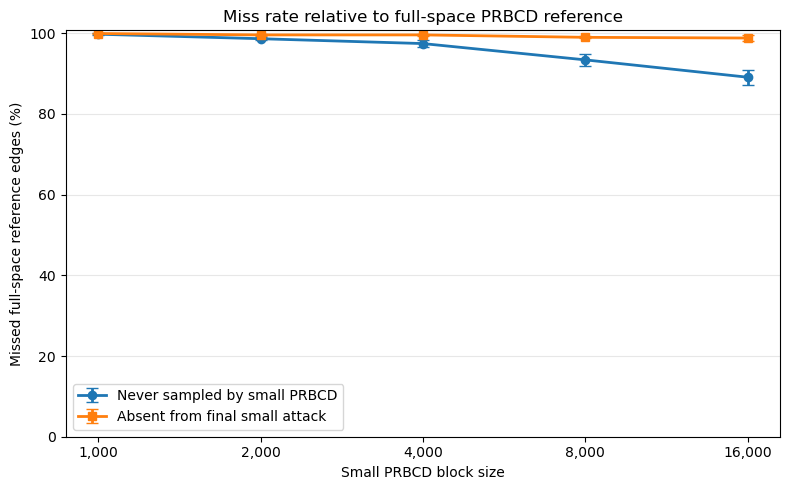

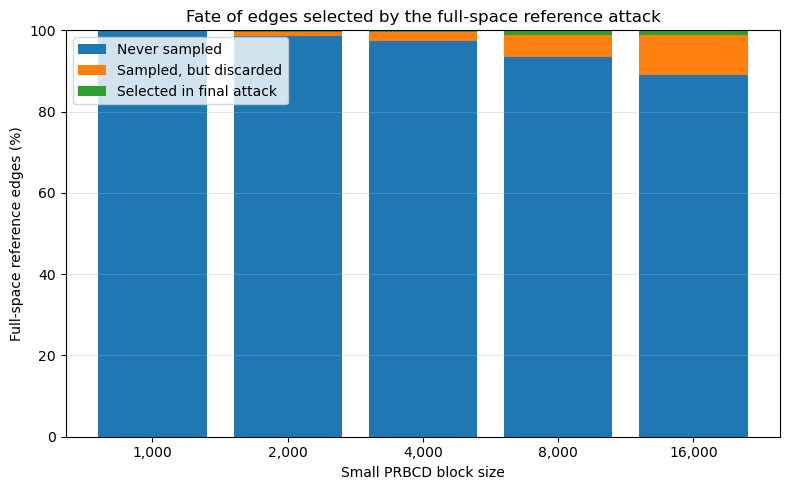


Skipping accuracy-over-epochs plot: epoch_accuracy.csv was not found in the RQ1 output directory.
To create this plot, save per-epoch attack_statistics['accuracy'] during the RQ1 experiment run.

Reference type: full_space_fixed_no_resampling

Mean miss rates:


,block_size,repeats,never_sampled_percent,absent_final_percent
0,1000,3,99.742268,99.914089
1,2000,3,98.625430,99.570447
2,4000,3,97.422680,99.570447
3,8000,3,93.384880,98.969072
4,16000,3,89.089347,98.797251



Plots saved in:
E:\Masterarbeit\AttackerGNN\extendedPlotting\rq1_full_space_vs_small\cora_ml__20260705_115821\plots


In [23]:
# %%

# ============================================================
# PLOT RQ1 RESULTS:
# Do small PRBCD blocks miss edges found by the full-space reference?
# Includes accuracy-over-epochs plot if epoch_accuracy.csv exists.
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Locate the output directory
# ------------------------------------------------------------

if "RQ1_OUT_DIR" in globals() and Path(RQ1_OUT_DIR).exists():
    rq1_plot_dir = Path(RQ1_OUT_DIR)
else:
    candidate_roots = [
        Path("extendedPlotting/rq1_full_space_vs_small"),
        # Backward-compatible fallback for old high-block runs.
        Path("extendedPlotting/rq1_large_vs_small"),
    ]

    candidate_dirs = []
    for rq1_root in candidate_roots:
        if rq1_root.exists():
            candidate_dirs.extend(
                [path for path in rq1_root.iterdir() if path.is_dir()]
            )

    candidate_dirs = sorted(
        candidate_dirs,
        key=lambda path: path.stat().st_mtime,
    )

    if not candidate_dirs:
        raise FileNotFoundError(
            "No RQ1 output directory was found under "
            "'extendedPlotting/rq1_full_space_vs_small' or "
            "'extendedPlotting/rq1_large_vs_small'."
        )

    rq1_plot_dir = candidate_dirs[-1]


print("Plotting results from:")
print(rq1_plot_dir.resolve())


# ------------------------------------------------------------
# 2. Load results
# ------------------------------------------------------------

summary_df = pd.read_csv(
    rq1_plot_dir / "small_run_summary.csv"
)

edge_status_df = pd.read_csv(
    rq1_plot_dir / "reference_edge_status_by_small_run.csv"
)

reference_runs_path = rq1_plot_dir / "reference_runs.csv"
if reference_runs_path.exists():
    reference_runs_df = pd.read_csv(reference_runs_path)
    print("\nReference run(s):")
    display(reference_runs_df)
else:
    reference_runs_df = pd.DataFrame()

reference_type = (
    summary_df["reference_type"].iloc[0]
    if "reference_type" in summary_df.columns and not summary_df.empty
    else "full_space_reference"
)

plot_output_dir = rq1_plot_dir / "plots"
plot_output_dir.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 3. Prepare miss-rate summary
# ------------------------------------------------------------

summary_df["never_sampled_rate"] = (
    1.0 - summary_df["reference_discovery_recall"]
)

summary_df["absent_from_final_rate"] = (
    1.0 - summary_df["final_reference_recall"]
)

miss_summary = (
    summary_df
    .groupby("block_size", as_index=False)
    .agg(
        never_sampled_mean=("never_sampled_rate", "mean"),
        never_sampled_std=("never_sampled_rate", "std"),
        absent_final_mean=("absent_from_final_rate", "mean"),
        absent_final_std=("absent_from_final_rate", "std"),
        repeats=("repeat", "count"),
    )
    .sort_values("block_size")
)

# A single repeat produces NaN standard deviations.
miss_summary[
    ["never_sampled_std", "absent_final_std"]
] = miss_summary[
    ["never_sampled_std", "absent_final_std"]
].fillna(0.0)

display(miss_summary)


# ============================================================
# PLOT 1:
# Miss rate versus PRBCD block size
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    miss_summary["block_size"],
    100 * miss_summary["never_sampled_mean"],
    yerr=100 * miss_summary["never_sampled_std"],
    marker="o",
    capsize=4,
    linewidth=2,
    label="Never sampled by small PRBCD",
)

ax.errorbar(
    miss_summary["block_size"],
    100 * miss_summary["absent_final_mean"],
    yerr=100 * miss_summary["absent_final_std"],
    marker="s",
    capsize=4,
    linewidth=2,
    label="Absent from final small attack",
)

ax.set_xscale("log", base=2)
ax.set_xticks(miss_summary["block_size"])
ax.set_xticklabels(
    [f"{int(value):,}" for value in miss_summary["block_size"]]
)

ax.set_xlabel("Small PRBCD block size")
ax.set_ylabel("Missed full-space reference edges (%)")
ax.set_title(
    "Miss rate relative to full-space PRBCD reference"
)
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()

fig.savefig(
    plot_output_dir / "rq1_full_reference_miss_rate_by_block_size.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    plot_output_dir / "rq1_full_reference_miss_rate_by_block_size.pdf",
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT 2:
# Why reference edges are absent from a small run
# ============================================================

status_counts = (
    edge_status_df
    .groupby(
        ["block_size", "repeat", "status"],
        as_index=False,
    )
    .size()
)

status_totals = (
    status_counts
    .groupby(
        ["block_size", "repeat"]
    )["size"]
    .transform("sum")
)

status_counts["proportion"] = (
    status_counts["size"] / status_totals
)

status_mean = (
    status_counts
    .groupby(
        ["block_size", "status"],
        as_index=False,
    )["proportion"]
    .mean()
)

status_order = [
    "never_sampled_by_small_run",
    "sampled_but_not_final",
    "found_in_small_final",
]

status_labels = {
    "never_sampled_by_small_run": "Never sampled",
    "sampled_but_not_final": "Sampled, but discarded",
    "found_in_small_final": "Selected in final attack",
}

status_plot = (
    status_mean
    .pivot(
        index="block_size",
        columns="status",
        values="proportion",
    )
    .reindex(columns=status_order)
    .fillna(0.0)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

bottom = np.zeros(len(status_plot))

for status in status_order:
    values = 100 * status_plot[status].to_numpy()

    ax.bar(
        [f"{int(value):,}" for value in status_plot.index],
        values,
        bottom=bottom,
        label=status_labels[status],
    )

    bottom += values

ax.set_xlabel("Small PRBCD block size")
ax.set_ylabel("Full-space reference edges (%)")
ax.set_title(
    "Fate of edges selected by the full-space reference attack"
)
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

fig.savefig(
    plot_output_dir / "rq1_full_reference_edge_status.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    plot_output_dir / "rq1_full_reference_edge_status.pdf",
    bbox_inches="tight",
)

plt.show()


# ============================================================
# PLOT 3:
# Accuracy over epochs for full-space reference and small blocks
# Requires epoch_accuracy.csv in the RQ1 output directory.
# ============================================================

epoch_accuracy_path = rq1_plot_dir / "epoch_accuracy.csv"

if epoch_accuracy_path.exists():
    epoch_accuracy_df = pd.read_csv(epoch_accuracy_path)

    required_columns = {
        "epoch",
        "accuracy",
        "block_size",
        "repeat",
        "is_reference",
    }

    missing_columns = required_columns - set(epoch_accuracy_df.columns)
    if missing_columns:
        raise ValueError(
            f"epoch_accuracy.csv is missing required columns: {sorted(missing_columns)}"
        )

    epoch_accuracy_df["accuracy_percent"] = (
        100 * epoch_accuracy_df["accuracy"]
    )

    fig, ax = plt.subplots(figsize=(9, 5))

    # -------------------------
    # Full-space reference
    # -------------------------
    reference_epoch_df = epoch_accuracy_df[
        epoch_accuracy_df["is_reference"] == True
    ].copy()

    if not reference_epoch_df.empty:
        reference_epoch_summary = (
            reference_epoch_df
            .groupby("epoch", as_index=False)
            .agg(
                accuracy_mean=("accuracy_percent", "mean"),
                accuracy_std=("accuracy_percent", "std"),
                repeats=("repeat", "count"),
            )
            .sort_values("epoch")
        )

        reference_epoch_summary["accuracy_std"] = (
            reference_epoch_summary["accuracy_std"].fillna(0.0)
        )

        ax.plot(
            reference_epoch_summary["epoch"],
            reference_epoch_summary["accuracy_mean"],
            linewidth=3,
            label="Full-space reference",
        )

        if reference_epoch_summary["accuracy_std"].max() > 0:
            ax.fill_between(
                reference_epoch_summary["epoch"],
                reference_epoch_summary["accuracy_mean"]
                - reference_epoch_summary["accuracy_std"],
                reference_epoch_summary["accuracy_mean"]
                + reference_epoch_summary["accuracy_std"],
                alpha=0.15,
            )

    # -------------------------
    # Small PRBCD blocks
    # -------------------------
    small_epoch_df = epoch_accuracy_df[
        epoch_accuracy_df["is_reference"] == False
    ].copy()

    if not small_epoch_df.empty:
        small_epoch_summary = (
            small_epoch_df
            .groupby(["block_size", "epoch"], as_index=False)
            .agg(
                accuracy_mean=("accuracy_percent", "mean"),
                accuracy_std=("accuracy_percent", "std"),
                repeats=("repeat", "count"),
            )
            .sort_values(["block_size", "epoch"])
        )

        small_epoch_summary["accuracy_std"] = (
            small_epoch_summary["accuracy_std"].fillna(0.0)
        )

        for block_size, block_df in small_epoch_summary.groupby("block_size"):
            block_df = block_df.sort_values("epoch")

            ax.plot(
                block_df["epoch"],
                block_df["accuracy_mean"],
                linewidth=2,
                label=f"Small PRBCD block={int(block_size):,}",
            )

            if block_df["accuracy_std"].max() > 0:
                ax.fill_between(
                    block_df["epoch"],
                    block_df["accuracy_mean"] - block_df["accuracy_std"],
                    block_df["accuracy_mean"] + block_df["accuracy_std"],
                    alpha=0.12,
                )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy on attacked nodes (%)")
    ax.set_title(
        "Accuracy over epochs: full-space reference vs. small PRBCD blocks"
    )
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()

    fig.savefig(
        plot_output_dir / "rq1_accuracy_over_epochs_reference_vs_small_blocks.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        plot_output_dir / "rq1_accuracy_over_epochs_reference_vs_small_blocks.pdf",
        bbox_inches="tight",
    )

    plt.show()

else:
    print(
        "\nSkipping accuracy-over-epochs plot: "
        "epoch_accuracy.csv was not found in the RQ1 output directory."
    )
    print(
        "To create this plot, save per-epoch attack_statistics['accuracy'] "
        "during the RQ1 experiment run."
    )


# ------------------------------------------------------------
# 4. Print the main numerical result
# ------------------------------------------------------------

print("\nReference type:", reference_type)
print("\nMean miss rates:")
display(
    miss_summary[
        [
            "block_size",
            "repeats",
            "never_sampled_mean",
            "absent_final_mean",
        ]
    ].assign(
        never_sampled_percent=lambda df:
            100 * df["never_sampled_mean"],
        absent_final_percent=lambda df:
            100 * df["absent_final_mean"],
    )[
        [
            "block_size",
            "repeats",
            "never_sampled_percent",
            "absent_final_percent",
        ]
    ]
)

print("\nPlots saved in:")
print(plot_output_dir.resolve())